# Paper 2 — Goal 2 completion, protocol-concordance correction, sensitivities, and final seal

This notebook is run **after Notebook 20 FINAL has completed successfully**. It does not redefine Primary-A or Core-Q. Its purpose is to close Goal 2 completely before Goal 3.

It performs five jobs:

1. verifies the frozen Goal 2 FINAL primary run and its hashes;
2. corrects one protocol-concordance issue in `M_A-resQ`: the frozen Methods require the Q→A ridge penalty to be selected inside the outer-training data by grouped reconstruction CV, whereas Notebook 20 used a fixed alpha=1.0;
3. recomputes the authoritative paired Goal 2 outputs with the corrected residualized representation while leaving `M_A` and `M_A+Q` unchanged;
4. runs the prespecified Goal 2 robustness package: A-only, first-recording diagnosis, median participant aggregation, Extended-Q, robust Q-loss checks, Q-family add-one/leave-one-out, constrained group-safe HGB, overlap diagnostics, and ridge coefficient stability;
5. writes a **Goal 2 final completion seal** and supplementary source tables/figures.

### Important interpretation boundary
Goal 2 remains observational. Adding Q, removing Q-predictable acoustic variation, or finding Q-dependent error demonstrates dependence/sensitivity in this cohort. It does **not** prove a purely technical cause, shortcut learning, or reconstruction of artifact-free physiology.

### Run instruction
Use **Kernel → Restart Kernel and Run All Cells**. This notebook is checkpointed by outer fold so a stopped HGB run can resume safely.


In [3]:
from __future__ import annotations

import hashlib
import importlib.metadata as mdlib
import itertools
import json
import math
import os
import platform
import re
import shutil
import subprocess
import sys
import warnings
from collections import OrderedDict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import stats
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.genmod.cov_struct import Independence, Exchangeable
from statsmodels.genmod.families import Gaussian
from statsmodels.nonparametric.smoothers_lowess import lowess

# ------------------------------------------------------------------
# USER-FACING CONFIG
# ------------------------------------------------------------------

RUN_MODE = "FINAL"    # change to FINAL only after development PASS
RESET_OUTPUTS = False
RESUME_IF_VALID = True

BASE_SEED = 20260825
OUTER_FOLDS = 5
OUTER_REPEATS = 10
INNER_FOLDS = 5

if RUN_MODE not in {"DEVELOPMENT", "FINAL"}:
    raise ValueError("RUN_MODE must be DEVELOPMENT or FINAL.")

N_BOOTSTRAPS = 2000 if RUN_MODE == "FINAL" else 300

# Linear Q->A residualizer. This penalty is prespecified and does not use
# outcome performance. Q and A are standardized inside the training fold.
RESIDUALIZER_ALPHA = 1.0

C_GRID = np.logspace(-4, 4, 9)
ALPHA_GRID = np.logspace(-4, 4, 9)

EXPECTED_PAPER1_COMMIT = (
    "cb31fb6886df1b2b2fedba4ffbbf8624bd56d7e8"
)

ENGINE_VERSION = "goal2-primary-v1.1.0"

EXPECTED = {
    "recordings": 519,
    "participants": 224,
    "als_participants": 158,
    "control_participants": 66,
    "als_recordings": 418,
    "control_recordings": 101,
    "diagnosis_age_complete_participants": 199,
    "diagnosis_age_complete_als": 158,
    "diagnosis_age_complete_controls": 41,
    "severity_participants_60d": 145,
    "severity_pairs_60d": 398,
}

def find_project_root() -> Path:
    override = os.environ.get("PAPER2_ROOT", "").strip()
    if override:
        root = Path(override).expanduser().resolve()
        if (root / "data" / "processed").exists():
            return root
        raise FileNotFoundError(f"Invalid PAPER2_ROOT: {root}")

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (
            (candidate / "data" / "processed").exists()
            and (candidate / "data" / "manifests").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate Paper 2 repository root."
    )

ROOT = find_project_root()
PROCESSED = ROOT / "data" / "processed"
MANIFESTS = ROOT / "data" / "manifests"
EXTERNAL = ROOT / "external" / "quality_framework_features"

RUN_TAG = RUN_MODE.lower()
OUT = (
    ROOT
    / "outputs"
    / "goal2"
    / "goal2_primary_v1_1"
    / RUN_TAG
)

TABLES = OUT / "tables"
FIGURES = OUT / "figures"
OOF_DIR = OUT / "oof"
CHECKPOINTS = OUT / "checkpoints"
LOGS = OUT / "logs"

if RESET_OUTPUTS and OUT.exists():
    shutil.rmtree(OUT)

for directory in [
    OUT, TABLES, FIGURES, OOF_DIR, CHECKPOINTS, LOGS
]:
    directory.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

print("Paper 2 root:", ROOT)
print("Engine:", ENGINE_VERSION)
print("Run mode:", RUN_MODE)
print("Bootstrap replicates:", N_BOOTSTRAPS)


Paper 2 root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Engine: goal2-primary-v1.1.0
Run mode: FINAL
Bootstrap replicates: 2000


## 1. Atomic I/O and reproducibility utilities

In [4]:
def sha256_file(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(chunk_size), b""):
            h.update(block)
    return h.hexdigest()

def stable_hash(payload):
    text = json.dumps(
        payload,
        sort_keys=True,
        default=str,
        separators=(",", ":"),
    )
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def atomic_write_json(payload, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(
        json.dumps(payload, indent=2, default=str),
        encoding="utf-8",
    )
    os.replace(temp, path)

def atomic_write_csv(
    frame,
    path,
    *,
    required_columns=None,
    allow_empty=False,
):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"{path.name}: expected DataFrame.")

    if not allow_empty and len(frame) == 0:
        raise ValueError(
            f"{path.name}: refusing to write empty table."
        )

    if required_columns:
        missing = set(required_columns) - set(frame.columns)
        if missing:
            raise ValueError(
                f"{path.name}: missing columns {sorted(missing)}"
            )

    temp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temp, index=False)

    if not temp.exists() or temp.stat().st_size == 0:
        raise IOError(
            f"{path.name}: temporary CSV is empty."
        )

    os.replace(temp, path)

def safe_read_csv(
    path,
    *,
    required_columns=None,
    allow_empty=False,
):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    if path.stat().st_size == 0:
        raise IOError(f"{path} exists but is empty.")

    frame = pd.read_csv(path, low_memory=False)

    if not allow_empty and len(frame) == 0:
        raise ValueError(f"{path} has no rows.")

    if required_columns:
        missing = set(required_columns) - set(frame.columns)
        if missing:
            raise ValueError(
                f"{path.name}: missing columns {sorted(missing)}"
            )

    return frame

def package_version(package):
    try:
        return mdlib.version(package)
    except Exception:
        return "unknown"

def deterministic_seed(*tokens, modulus=1_000_000):
    """
    Stable across Python processes and machines.
    Never use Python's built-in hash() for reproducibility.
    """
    digest = stable_hash(list(tokens))
    return BASE_SEED + (int(digest[:16], 16) % modulus)

def coerce_bool_series(series, name):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    mapping = {
        "true": True,
        "1": True,
        "yes": True,
        "y": True,
        "false": False,
        "0": False,
        "no": False,
        "n": False,
    }

    unknown = sorted(
        set(normalized.dropna()) - set(mapping)
    )
    if unknown:
        raise ValueError(
            f"{name}: unrecognized boolean values: {unknown[:20]}"
        )

    return normalized.map(mapping).astype(bool)

print("Atomic I/O / deterministic utilities: READY")


Atomic I/O / deterministic utilities: READY


## 2. Hard A/Q/cohort/split gates

The notebook will not fit a model unless:

- the A freeze manifest says `FROZEN`;
- the A values/registry hashes match;
- the canonical 519/224/158/66 denominators still hold;
- the Goal 1 split manifest is intact;
- the Phase 0.5 QCHAN cache still reproduces the frozen Paper 1 QCHAN release.


In [5]:
PATHS = {
    "recording_table": PROCESSED / "recording_table_phase0.csv",
    "participant_table": PROCESSED / "participant_table.csv",
    "severity_pairs": PROCESSED / "severity_pairs.csv",
    "a_values": PROCESSED / "acoustic_features_frozen.csv",
    "a_registry": MANIFESTS / "a_registry.csv",
    "a_manifest": MANIFESTS / "a_freeze_manifest.json",
    "q_registry": MANIFESTS / "q_registry.csv",
    "split_manifest": MANIFESTS / "split_manifest.csv",
    "qchan_ready": MANIFESTS / "qchan_cache_ready.json",
    "qchan_cache_index": MANIFESTS / "qchan_spectrum_cache_index.csv",
}

missing = [
    name for name, path in PATHS.items()
    if not path.exists()
]
if missing:
    raise FileNotFoundError(
        "Missing Goal 2 prerequisite(s): "
        + ", ".join(missing)
    )

recording_table = safe_read_csv(
    PATHS["recording_table"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
        "diagnosis",
        "age_at_recording_years",
    ],
)

participant_table = safe_read_csv(
    PATHS["participant_table"],
    required_columns=[
        "participant_id",
        "diagnosis",
    ],
)

severity_pairs_raw = safe_read_csv(
    PATHS["severity_pairs"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
        "bulbar_score",
        "abs_delta_days",
        "within_60_days",
    ],
)

a_values = safe_read_csv(
    PATHS["a_values"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
    ],
)

a_registry = safe_read_csv(
    PATHS["a_registry"],
    required_columns=[
        "feature",
        "final_role",
        "final_transform",
        "support_indicator_column",
        "a_freeze_version",
    ],
)

q_registry = safe_read_csv(
    PATHS["q_registry"],
    required_columns=[
        "feature",
        "family",
        "paper2_role",
        "transform",
    ],
)

split_manifest = safe_read_csv(
    PATHS["split_manifest"],
    required_columns=[
        "participant_id",
        "repeat",
        "outer_fold",
    ],
)

qchan_cache_index = safe_read_csv(
    PATHS["qchan_cache_index"],
    required_columns=[
        "logical_recording_id",
        "status",
        "spectrum_sha256",
        "cache_path",
    ],
)

a_manifest = json.loads(
    PATHS["a_manifest"].read_text(encoding="utf-8")
)
qchan_ready = json.loads(
    PATHS["qchan_ready"].read_text(encoding="utf-8")
)

for frame in [
    recording_table,
    participant_table,
    severity_pairs_raw,
    a_values,
    split_manifest,
    qchan_cache_index,
]:
    if "participant_id" in frame.columns:
        frame["participant_id"] = (
            frame["participant_id"]
            .astype(str)
            .str.strip()
        )
    if "logical_recording_id" in frame.columns:
        frame["logical_recording_id"] = (
            frame["logical_recording_id"]
            .astype(str)
            .str.strip()
        )

if a_manifest.get("status") != "FROZEN":
    raise RuntimeError(
        "A freeze manifest is not FROZEN."
    )

if sha256_file(PATHS["a_registry"]) != a_manifest["a_registry_sha256"]:
    raise RuntimeError("Frozen A registry hash mismatch.")

if (
    sha256_file(PATHS["a_values"])
    != a_manifest["acoustic_features_frozen_sha256"]
):
    raise RuntimeError("Frozen A values hash mismatch.")

if a_manifest["n_primary_a"] != 6:
    raise RuntimeError(
        "Expected six frozen Primary-A features."
    )

# Canonical denominators.
recording_table["y_dx"] = recording_table[
    "diagnosis"
].map({"ALS": 1, "CONTROLS": 0})

if recording_table["y_dx"].isna().any():
    raise ValueError("Unexpected diagnosis label.")

assert len(recording_table) == EXPECTED["recordings"]
assert (
    recording_table["participant_id"].nunique()
    == EXPECTED["participants"]
)
assert int((recording_table["y_dx"] == 1).sum()) == EXPECTED["als_recordings"]
assert int((recording_table["y_dx"] == 0).sum()) == EXPECTED["control_recordings"]

participant_dx = (
    recording_table[
        ["participant_id", "y_dx"]
    ]
    .drop_duplicates()
)

assert len(participant_dx) == EXPECTED["participants"]
assert int(participant_dx["y_dx"].sum()) == EXPECTED["als_participants"]
assert int((participant_dx["y_dx"] == 0).sum()) == EXPECTED["control_participants"]

# A identity alignment.
if len(a_values) != EXPECTED["recordings"]:
    raise RuntimeError(
        f"Frozen A table has {len(a_values)} rows, expected 519."
    )
if not a_values["logical_recording_id"].is_unique:
    raise RuntimeError("Frozen A recording IDs are not unique.")
if set(a_values["logical_recording_id"]) != set(
    recording_table["logical_recording_id"]
):
    raise RuntimeError(
        "Frozen A identities differ from canonical recordings."
    )

# Split contract.
assert len(split_manifest) == EXPECTED["participants"] * OUTER_REPEATS
assert split_manifest["repeat"].nunique() == OUTER_REPEATS
assert split_manifest["outer_fold"].nunique() == OUTER_FOLDS
assert split_manifest.groupby(
    ["participant_id", "repeat"]
).size().eq(1).all()
assert set(split_manifest["participant_id"]) == set(
    participant_dx["participant_id"]
)

# QCHAN readiness.
for flag in [
    "all_media_paths_resolved",
    "all_media_hashes_verified",
    "all_spectra_measured",
    "paper1_release_reproduced",
]:
    if qchan_ready.get(flag) is not True:
        raise RuntimeError(
            f"QCHAN readiness failure: {flag}"
        )

if (
    qchan_ready.get("paper1_repo_commit")
    != EXPECTED_PAPER1_COMMIT
):
    raise RuntimeError(
        "QCHAN cache was not generated from pinned Paper 1 commit."
    )

if not (EXTERNAL / ".git").exists():
    raise FileNotFoundError(
        f"Pinned Paper 1 repo missing: {EXTERNAL}"
    )

observed_paper1_commit = subprocess.check_output(
    [
        "git",
        "-C",
        str(EXTERNAL),
        "rev-parse",
        "HEAD",
    ],
    text=True,
).strip()

if observed_paper1_commit != EXPECTED_PAPER1_COMMIT:
    raise RuntimeError(
        "Pinned Paper 1 checkout changed."
    )

print("A / COHORT / SPLIT / QCHAN GATES: PASS")
print(
    "519 recordings | 224 participants | "
    "158 ALS | 66 controls"
)
print(
    "Frozen A:",
    a_manifest["n_primary_a"],
    "Primary |",
    a_manifest["n_extended_a"],
    "Extended",
)


A / COHORT / SPLIT / QCHAN GATES: PASS
519 recordings | 224 participants | 158 ALS | 66 controls
Frozen A: 6 Primary | 22 Extended


## 3. Freeze the exact Goal 2 model representations

Primary-A is read from `a_registry.csv`; no feature identity is hard-coded from observed results.

Core-Q is the exact Goal 1 representation:

- QADD 3 numeric + 3 support indicators;
- QGAIN 4;
- QREV normalized-fast SRMR;
- QCHAN 4 fold-safe reference-relative values.


In [4]:
AGE = "age_at_recording_years"

PRIMARY_A = a_registry.loc[
    a_registry["final_role"].eq("primary"),
    "feature",
].astype(str).tolist()

EXTENDED_A = a_registry.loc[
    a_registry["final_role"].eq("extended"),
    "feature",
].astype(str).tolist()

A_TRANSFORM = (
    a_registry
    .set_index("feature")["final_transform"]
    .astype(str)
    .to_dict()
)

A_SUPPORT = (
    a_registry
    .set_index("feature")["support_indicator_column"]
    .astype(str)
    .to_dict()
)

QADD = [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
]

QGAIN = [
    "qgain_typical_speech_level_dbfs",
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min",
]

QREV = [
    "qrev_srmr_norm",
]

# QCHAN imported below from the validated Paper 1 implementation.
QCHAN = []

Q_TRANSFORM = dict(
    zip(
        q_registry["feature"].astype(str),
        q_registry["transform"].astype(str),
    )
)

Q_SUPPORT = [
    f"{feature}_supported"
    for feature in QADD
]

# Verify all frozen A columns exist.
for feature in PRIMARY_A + EXTENDED_A:
    if feature not in a_values.columns:
        raise KeyError(
            f"Frozen A feature missing from values: {feature}"
        )

for feature in PRIMARY_A:
    support_col = A_SUPPORT[feature]
    if support_col not in a_values.columns:
        raise KeyError(
            f"Primary-A support indicator missing: {support_col}"
        )

print("Primary-A:")
display(
    a_registry.loc[
        a_registry["final_role"].eq("primary"),
        [
            "feature",
            "acoustic_family",
            "speech_subsystem",
            "final_transform",
            "support_indicator_column",
        ],
    ]
)

print("MODEL REPRESENTATION CONTRACT: PART 1 PASS")


Primary-A:


,feature,acoustic_family,speech_subsystem,final_transform,support_indicator_column
5,bamboo_percent_pause_time_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_percent_pause_time_300ms__supported
7,bamboo_pause_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_pause_mean_sec_300ms__supported
12,bamboo_phrase_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_phrase_mean_sec_300ms__supported
15,bamboo_phrase_cv_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_phrase_cv_300ms__supported
18,bamboo_nominal_articulation_rate_syll_per_sec,timing_fluency,articulatory_temporal,none,bamboo_nominal_articulation_rate_syll_per_sec_...
22,bamboo_f0_iqr_semitones,phonation_prosody,phonatory_prosodic,log1p,bamboo_f0_iqr_semitones__supported


MODEL REPRESENTATION CONTRACT: PART 1 PASS


## 4. Load the validated reference-independent QCHAN cache

Every inner/outer predictive QCHAN value is reconstructed from the relevant training participants only.


In [5]:
paper1_src = EXTERNAL / "src"
if str(paper1_src) not in sys.path:
    sys.path.insert(0, str(paper1_src))

from paper1_qc_reviewed.qchan_v400 import (
    ANALYSIS_FEATURES as QCHAN_FEATURES_TUPLE,
    DEFAULT_PARAMETERS as QCHAN_PARAMETERS,
    build_subject_balanced_loso_references,
    compute_reference_relative_features,
)
from paper1_qc_reviewed.qchan_v400_cohort import (
    load_recording_spectrum,
)

QCHAN = list(QCHAN_FEATURES_TUPLE)
CORE_Q = QADD + QGAIN + QREV + QCHAN

for feature in CORE_Q:
    if feature not in Q_TRANSFORM:
        raise KeyError(
            f"Core-Q transform missing from q_registry: {feature}"
        )

for support in Q_SUPPORT:
    if support not in recording_table.columns:
        raise KeyError(
            f"Core-Q support indicator missing: {support}"
        )

spectra = {}

for row in qchan_cache_index.itertuples(index=False):
    cache_path = Path(str(row.cache_path))
    if not cache_path.is_absolute():
        cache_path = ROOT / cache_path

    if not cache_path.exists():
        raise FileNotFoundError(
            f"QCHAN cache missing: {cache_path}"
        )

    spectrum = load_recording_spectrum(
        cache_path
    )

    if spectrum.status != "measured":
        raise RuntimeError(
            f"QCHAN spectrum not measured: "
            f"{row.logical_recording_id}"
        )

    spectra[str(row.logical_recording_id)] = spectrum

if len(spectra) != EXPECTED["recordings"]:
    raise RuntimeError(
        f"Expected 519 QCHAN spectra, got {len(spectra)}."
    )

QCHAN_CACHE = OrderedDict()
QCHAN_CACHE_LIMIT = 2048

def qchan_cache_key(reference_participants, target_rows):
    targets = (
        target_rows[
            ["participant_id", "logical_recording_id"]
        ]
        .drop_duplicates()
        .sort_values(
            ["participant_id", "logical_recording_id"]
        )
    )

    payload = {
        "reference_participants": sorted(
            map(str, reference_participants)
        ),
        "targets": (
            targets.astype(str)
            .to_dict("records")
        ),
        "paper1_commit": observed_paper1_commit,
    }

    return stable_hash(payload)

def reference_metadata(reference_rows):
    meta = (
        reference_rows[
            ["logical_recording_id", "participant_id"]
        ]
        .drop_duplicates()
        .rename(
            columns={"participant_id": "subject_id"}
        )
        .copy()
    )

    meta["logical_recording_id"] = (
        meta["logical_recording_id"]
        .astype(str)
    )
    meta["subject_id"] = (
        meta["subject_id"]
        .astype(str)
    )
    meta["task_stratum"] = "BAMBOO_PASSAGE"
    return meta

def fold_safe_qchan(
    reference_participant_ids,
    target_rows,
):
    reference_participant_ids = set(
        map(str, reference_participant_ids)
    )

    if not reference_participant_ids:
        raise ValueError(
            "QCHAN reference participant set is empty."
        )

    target_unique = (
        target_rows[
            ["participant_id", "logical_recording_id"]
        ]
        .drop_duplicates()
        .copy()
    )

    target_unique["participant_id"] = (
        target_unique["participant_id"].astype(str)
    )
    target_unique["logical_recording_id"] = (
        target_unique[
            "logical_recording_id"
        ].astype(str)
    )

    if target_unique[
        "logical_recording_id"
    ].duplicated().any():
        raise ValueError(
            "A recording ID maps to multiple participants "
            "in QCHAN target rows."
        )

    key = qchan_cache_key(
        reference_participant_ids,
        target_unique,
    )

    if key in QCHAN_CACHE:
        cached = QCHAN_CACHE.pop(key)
        QCHAN_CACHE[key] = cached
        return cached.copy()

    # Important: QCHAN's measurement reference uses ALL retained
    # canonical recordings belonging to the training participants,
    # participant-balanced and outcome-blind.
    reference_rows = recording_table.loc[
        recording_table["participant_id"].isin(
            reference_participant_ids
        ),
        [
            "participant_id",
            "logical_recording_id",
        ],
    ].drop_duplicates()

    observed_reference_participants = set(
        reference_rows[
            "participant_id"
        ].astype(str)
    )

    if (
        observed_reference_participants
        != reference_participant_ids
    ):
        missing = (
            reference_participant_ids
            - observed_reference_participants
        )
        raise ValueError(
            "QCHAN training participants missing canonical "
            f"recordings: {sorted(missing)[:10]}"
        )

    ref_spectra = {
        rid: spectra[rid]
        for rid in reference_rows[
            "logical_recording_id"
        ].astype(str)
    }

    ref_meta = reference_metadata(
        reference_rows
    )

    training_references = (
        build_subject_balanced_loso_references(
            ref_spectra,
            ref_meta,
            parameters=QCHAN_PARAMETERS,
        )
    )

    external = target_unique.loc[
        ~target_unique[
            "participant_id"
        ].isin(reference_participant_ids)
    ]

    external_reference = None

    if len(external):
        dummy = external.iloc[0]
        dummy_rid = str(
            dummy["logical_recording_id"]
        )
        dummy_pid = str(
            dummy["participant_id"]
        )

        combo_spectra = dict(ref_spectra)
        combo_spectra[dummy_rid] = spectra[dummy_rid]

        combo_meta = pd.concat(
            [
                ref_meta,
                pd.DataFrame(
                    [{
                        "logical_recording_id": dummy_rid,
                        "subject_id": dummy_pid,
                        "task_stratum": "BAMBOO_PASSAGE",
                    }]
                ),
            ],
            ignore_index=True,
        )

        refs = (
            build_subject_balanced_loso_references(
                combo_spectra,
                combo_meta,
                parameters=QCHAN_PARAMETERS,
            )
        )

        external_reference = refs[dummy_rid]

        members = set(
            map(
                str,
                external_reference.member_subject_ids,
            )
        )

        if not members.issubset(
            reference_participant_ids
        ):
            raise RuntimeError(
                "HELD-OUT QCHAN REFERENCE LEAKAGE."
            )

        if dummy_pid in members:
            raise RuntimeError(
                "External dummy participant entered "
                "its own QCHAN reference."
            )

    output_rows = []

    for row in target_unique.itertuples(
        index=False
    ):
        pid = str(row.participant_id)
        rid = str(row.logical_recording_id)

        if pid in reference_participant_ids:
            reference = training_references[rid]
            members = set(
                map(
                    str,
                    reference.member_subject_ids,
                )
            )

            if pid in members:
                raise RuntimeError(
                    f"QCHAN LOSO failure: {pid}"
                )

            if not members.issubset(
                reference_participant_ids
            ):
                raise RuntimeError(
                    "QCHAN training reference leakage."
                )

        else:
            if external_reference is None:
                raise RuntimeError(
                    "Missing external QCHAN reference."
                )
            reference = external_reference

        values = compute_reference_relative_features(
            spectra[rid],
            reference,
            parameters=QCHAN_PARAMETERS,
        )

        output_rows.append({
            "participant_id": pid,
            "logical_recording_id": rid,
            **{
                feature: values[feature]
                for feature in QCHAN
            },
        })

    result = pd.DataFrame(
        output_rows
    )

    if len(result) != len(target_unique):
        raise RuntimeError(
            "QCHAN row-count mismatch."
        )

    if result[QCHAN].isna().any().any():
        raise RuntimeError(
            "Unexpected missing fold-safe QCHAN."
        )

    QCHAN_CACHE[key] = result.copy()

    while len(QCHAN_CACHE) > QCHAN_CACHE_LIMIT:
        QCHAN_CACHE.popitem(last=False)

    return result

print(
    "QCHAN CACHE + FOLD-SAFE RECONSTRUCTION: READY"
)


QCHAN CACHE + FOLD-SAFE RECONSTRUCTION: READY


## 5. Frozen run signature

Checkpoint reuse is allowed only under the identical A/Q hashes, cohort inputs, seeds, folds, model grids, and residualizer contract. A stale OOF file from another analysis contract cannot be silently reused.


In [6]:
input_hashes_for_signature = {
    name: sha256_file(path)
    for name, path in PATHS.items()
    if Path(path).is_file()
}

run_contract = {
    "engine_version": ENGINE_VERSION,
    "run_mode": RUN_MODE,
    "base_seed": BASE_SEED,
    "outer_folds": OUTER_FOLDS,
    "outer_repeats": OUTER_REPEATS,
    "inner_folds": INNER_FOLDS,
    "bootstrap_replicates": N_BOOTSTRAPS,
    "residualizer_alpha": RESIDUALIZER_ALPHA,
    "C_grid": C_GRID.tolist(),
    "alpha_grid": ALPHA_GRID.tolist(),
    "primary_A": PRIMARY_A,
    "primary_A_transforms": {
        f: A_TRANSFORM[f] for f in PRIMARY_A
    },
    "core_Q": CORE_Q,
    "core_Q_transforms": {
        f: Q_TRANSFORM[f] for f in CORE_Q
    },
    "Q_support": Q_SUPPORT,
    "paper1_commit": observed_paper1_commit,
    "input_hashes": input_hashes_for_signature,
}

RUN_SIGNATURE = stable_hash(run_contract)
signature_path = OUT / "run_signature.json"

if signature_path.exists() and not RESET_OUTPUTS:
    existing = json.loads(
        signature_path.read_text(encoding="utf-8")
    )
    if existing.get("run_signature") != RUN_SIGNATURE:
        raise RuntimeError(
            "Existing Goal 2 output directory belongs to a different "
            "run contract. Set RESET_OUTPUTS=True once to deliberately "
            "clear it, or use the matching notebook/configuration."
        )

atomic_write_json(
    {
        "run_signature": RUN_SIGNATURE,
        **run_contract,
    },
    signature_path,
)

print("RUN SIGNATURE:", RUN_SIGNATURE[:16])
print("RUN-SIGNATURE GATE: PASS")


RUN SIGNATURE: 5f15eb4ba85fff79
RUN-SIGNATURE GATE: PASS


## 6. Construct exact Goal 2 analysis populations

Primary diagnosis uses all retained recordings from participants with observed age, because age is included unchanged in all three primary representations and age is **not imputed**.

Primary severity uses all frozen ≤60-day recording–assessment pairs. Participant remains the split/weighting cluster.


In [7]:
# Join frozen A to canonical recording rows.
recording_model = recording_table.merge(
    a_values,
    on=[
        "participant_id",
        "logical_recording_id",
    ],
    how="left",
    validate="one_to_one",
    suffixes=("", "_A"),
    indicator="_a_join",
)

if not recording_model[
    "_a_join"
].eq("both").all():
    raise RuntimeError(
        "At least one canonical recording lacks frozen A."
    )

recording_model = recording_model.drop(
    columns=["_a_join"]
)

# Diagnosis primary: age-complete participants only.
dx = recording_model.loc[
    recording_model[AGE].notna()
].copy()

dx["y"] = dx["diagnosis"].map({
    "ALS": 1,
    "CONTROLS": 0,
})

if dx["y"].isna().any():
    raise ValueError(
        "Unexpected diagnosis coding."
    )

dx_participants = (
    dx[
        ["participant_id", "y"]
    ]
    .drop_duplicates()
)

assert (
    dx_participants["participant_id"].nunique()
    == EXPECTED[
        "diagnosis_age_complete_participants"
    ]
)

assert int(dx_participants["y"].sum()) == EXPECTED[
    "diagnosis_age_complete_als"
]

assert int(
    (dx_participants["y"] == 0).sum()
) == EXPECTED[
    "diagnosis_age_complete_controls"
]

# ------------------------------------------------------------------
# Severity primary: compact frozen pair table + canonical Q/demographic
# rows + frozen A.
# ------------------------------------------------------------------

severity_pairs_raw["within_60_days"] = coerce_bool_series(
    severity_pairs_raw["within_60_days"],
    "within_60_days",
)

severity_pairs_60 = severity_pairs_raw.loc[
    severity_pairs_raw["within_60_days"]
].copy()

pair_fields = [
    "participant_id",
    "logical_recording_id",
    "bulbar_score",
    "abs_delta_days",
]

for optional in [
    "recording_date",
    "assessment_date",
    "alsfrs_total",
    "delta_days",
]:
    if optional in severity_pairs_60.columns:
        pair_fields.append(optional)

pair_meta = severity_pairs_60[
    pair_fields
].copy()

clinical_collision = {
    "bulbar_score",
    "alsfrs_total",
    "assessment_date",
    "delta_days",
    "abs_delta_days",
    "within_60_days",
    "within_90_days",
}

canonical_for_pair = recording_model.drop(
    columns=[
        c for c in clinical_collision
        if c in recording_model.columns
    ],
    errors="ignore",
).copy()

if (
    "recording_date" in pair_meta.columns
    and "recording_date" in canonical_for_pair.columns
):
    canonical_for_pair = canonical_for_pair.drop(
        columns=["recording_date"]
    )

sev = pair_meta.merge(
    canonical_for_pair,
    on=[
        "participant_id",
        "logical_recording_id",
    ],
    how="left",
    validate="many_to_one",
    indicator="_recording_join",
)

if len(sev) != len(pair_meta):
    raise RuntimeError(
        "Severity enrichment changed pair-row count."
    )

if not sev[
    "_recording_join"
].eq("both").all():
    raise RuntimeError(
        "Severity pair failed canonical+A join."
    )

sev = sev.drop(
    columns=["_recording_join"]
)

sev["y"] = pd.to_numeric(
    sev["bulbar_score"],
    errors="raise",
)

if not sev["y"].between(0, 12).all():
    raise ValueError(
        "Bulbar score outside 0–12."
    )

if not sev["abs_delta_days"].le(60).all():
    raise RuntimeError(
        "Primary severity includes >60-day pair."
    )

if sev[AGE].isna().any():
    raise RuntimeError(
        "Primary severity contains missing age."
    )

assert len(sev) == EXPECTED["severity_pairs_60d"]
assert (
    sev["participant_id"].nunique()
    == EXPECTED["severity_participants_60d"]
)

# Participant-normalized row weights.
def participant_weights(frame):
    counts = frame.groupby(
        "participant_id"
    )["participant_id"].transform("size")

    weights = 1.0 / counts.to_numpy(float)

    # Every participant must sum to exactly one total fitting weight.
    check = (
        pd.DataFrame({
            "participant_id": frame["participant_id"].to_numpy(),
            "weight": weights,
        })
        .groupby("participant_id")["weight"]
        .sum()
    )

    if not np.allclose(
        check.to_numpy(float),
        1.0,
        atol=1e-12,
        rtol=0,
    ):
        raise RuntimeError(
            "Participant weights do not sum to 1."
        )

    return weights

dx["row_weight"] = participant_weights(dx)
sev["row_weight"] = participant_weights(sev)

# Every analysis participant must exist in the master split.
if not set(dx["participant_id"]).issubset(
    set(split_manifest["participant_id"])
):
    raise RuntimeError(
        "Diagnosis participant absent from split manifest."
    )

if not set(sev["participant_id"]).issubset(
    set(split_manifest["participant_id"])
):
    raise RuntimeError(
        "Severity participant absent from split manifest."
    )

population_summary = pd.DataFrame([
    {
        "branch": "diagnosis",
        "rows": len(dx),
        "participants": dx["participant_id"].nunique(),
        "ALS_participants": int(
            dx_participants["y"].sum()
        ),
        "control_participants": int(
            (dx_participants["y"] == 0).sum()
        ),
    },
    {
        "branch": "severity_60d",
        "rows": len(sev),
        "participants": sev["participant_id"].nunique(),
        "ALS_participants": sev["participant_id"].nunique(),
        "control_participants": 0,
    },
])

atomic_write_csv(
    population_summary,
    TABLES / "goal2_population_summary.csv",
)

display(population_summary)
print("PRIMARY ANALYSIS POPULATIONS: PASS")


,branch,rows,participants,ALS_participants,control_participants
0,diagnosis,483,199,158,41
1,severity_60d,398,145,145,0


PRIMARY ANALYSIS POPULATIONS: PASS


## 7. Frozen transformations and training-only preprocessors

- A transformations come only from the frozen A registry.
- Q transformations come only from the frozen Q registry.
- Median imputation and centering/scaling are learned from training rows only.
- A and Q support indicators remain explicit predictors.


In [8]:
def apply_transform(values, transform):
    x = pd.to_numeric(
        values,
        errors="coerce",
    ).to_numpy(float)

    transform = str(transform).strip().lower()

    if transform in {"none", "", "nan"}:
        return x

    if transform == "log1p":
        finite = np.isfinite(x)
        if finite.any() and np.nanmin(x[finite]) < 0:
            raise ValueError(
                "log1p requested for negative values."
            )
        return np.log1p(x)

    if transform == "asinh":
        return np.arcsinh(x)

    raise ValueError(
        f"Unsupported frozen transform: {transform!r}"
    )

class NumericPreprocessor:
    def __init__(self, features, transform_map):
        self.features = list(features)
        self.transform_map = dict(transform_map)
        self.medians = None
        self.scaler = None

    def _raw(self, frame):
        columns = []

        for feature in self.features:
            if feature not in frame.columns:
                raise KeyError(
                    f"Missing numeric predictor: {feature}"
                )

            columns.append(
                apply_transform(
                    frame[feature],
                    self.transform_map[feature],
                )
            )

        if not columns:
            return np.empty(
                (len(frame), 0),
                dtype=float,
            )

        return np.column_stack(columns)

    def fit(self, frame):
        X = self._raw(frame)

        medians = np.nanmedian(
            X,
            axis=0,
        )

        if np.isnan(medians).any():
            bad = [
                feature
                for feature, median
                in zip(self.features, medians)
                if np.isnan(median)
            ]
            raise ValueError(
                "Training fold has no finite support for: "
                + ", ".join(bad)
            )

        self.medians = medians

        X_imp = np.where(
            np.isnan(X),
            medians[None, :],
            X,
        )

        self.scaler = StandardScaler()
        self.scaler.fit(X_imp)

        return self

    def transform(self, frame):
        if self.medians is None or self.scaler is None:
            raise RuntimeError(
                "NumericPreprocessor is not fitted."
            )

        X = self._raw(frame)
        X_imp = np.where(
            np.isnan(X),
            self.medians[None, :],
            X,
        )

        return self.scaler.transform(
            X_imp
        )

def get_binary_matrix(frame, columns):
    if not columns:
        return np.empty(
            (len(frame), 0),
            dtype=float,
        )

    missing = [
        c for c in columns
        if c not in frame.columns
    ]
    if missing:
        raise KeyError(
            "Missing support predictor(s): "
            + ", ".join(missing)
        )

    X = frame[columns].apply(
        pd.to_numeric,
        errors="coerce",
    ).to_numpy(float)

    if not np.isfinite(X).all():
        raise ValueError(
            "Support indicator contains missing/nonfinite values."
        )

    if not set(np.unique(X)).issubset({0.0, 1.0}):
        raise ValueError(
            "Support indicator is not binary."
        )

    return X

class FinalDesignScaler:
    def __init__(self):
        self.scaler = StandardScaler()

    def fit_transform(self, X):
        return self.scaler.fit_transform(X)

    def transform(self, X):
        return self.scaler.transform(X)

print("PREPROCESSING UTILITIES: READY")


PREPROCESSING UTILITIES: READY


## 8. Build fold-specific A/Q and the three paired representations

The same training/validation rows are used for all three models.

`A_resQ` removes only the **linear** Q-predictable component under the prespecified ridge map. It does not claim complete removal of Q information.


In [9]:
def attach_fold_safe_qchan(
    frame,
    reference_ids,
):
    frame = frame.copy()

    qchan = fold_safe_qchan(
        reference_ids,
        frame,
    )

    frame = frame.drop(
        columns=[
            c for c in QCHAN
            if c in frame.columns
        ],
        errors="ignore",
    )

    merged = frame.merge(
        qchan,
        on=[
            "participant_id",
            "logical_recording_id",
        ],
        how="left",
        validate="many_to_one",
    )

    if merged[QCHAN].isna().any().any():
        raise RuntimeError(
            "Fold-safe QCHAN merge produced missing values."
        )

    return merged


class PerFeatureQResidualizer:
    """
    Fit one ridge Q->A map per acoustic feature.

    Critical support rule:
    each A_j map is fit only on training rows where A_j is observed/supported.
    Unsupported A rows are not used as pseudo-observed median targets.

    QADD support indicators are included in the Q design because they are
    part of Core-Q. A support indicators are NOT residualized.
    """

    def __init__(self, alpha):
        self.alpha = float(alpha)
        self.models = []
        self.q_scaler = StandardScaler()

    def fit(
        self,
        Q_numeric,
        Q_support,
        A_numeric,
        A_support,
        sample_weight,
    ):
        q_raw = np.column_stack([
            Q_numeric,
            Q_support,
        ])

        Q_design = self.q_scaler.fit_transform(
            q_raw
        )

        self.models = []

        for j in range(A_numeric.shape[1]):
            supported = (
                A_support[:, j] == 1
            )

            if supported.sum() < 20:
                raise RuntimeError(
                    "Too few supported training rows to fit "
                    f"Q->A residualizer for Primary-A column {j}: "
                    f"{supported.sum()}"
                )

            model = Ridge(
                alpha=self.alpha,
                fit_intercept=True,
            )

            model.fit(
                Q_design[supported],
                A_numeric[supported, j],
                sample_weight=sample_weight[supported],
            )

            self.models.append(model)

        return self

    def transform(
        self,
        Q_numeric,
        Q_support,
        A_numeric,
        A_support,
    ):
        if not self.models:
            raise RuntimeError(
                "PerFeatureQResidualizer is not fitted."
            )

        q_raw = np.column_stack([
            Q_numeric,
            Q_support,
        ])

        Q_design = self.q_scaler.transform(
            q_raw
        )

        residual = np.asarray(
            A_numeric,
            dtype=float,
        ).copy()

        for j, model in enumerate(self.models):
            supported = (
                A_support[:, j] == 1
            )

            predicted = model.predict(
                Q_design
            )

            # Only an actually observed A value is residualized.
            residual[supported, j] = (
                A_numeric[supported, j]
                - predicted[supported]
            )

            # If A is unavailable, preserve the training-fold imputed
            # numeric placeholder and its separate support indicator.
            # Do not manufacture a Q-derived residual for an unobserved A.
            residual[~supported, j] = (
                A_numeric[~supported, j]
            )

        return residual


def fit_fold_representation(
    train,
    target,
    *,
    reference_ids,
    a_features,
    q_features,
):
    """
    Fit every data-dependent operation on train only.

    Returns the same paired rows for:
      M_A      = Age + A + A_support
      M_A+Q    = Age + A + A_support + Q + Q_support
      M_A-resQ = Age + A_resQ + A_support
    """
    reference_ids = set(
        map(str, reference_ids)
    )

    train_q = attach_fold_safe_qchan(
        train,
        reference_ids,
    )

    target_q = attach_fold_safe_qchan(
        target,
        reference_ids,
    )

    # ----------------------------------------------------------
    # Frozen A transforms + training-only imputation/scaling.
    # ----------------------------------------------------------

    a_prep = NumericPreprocessor(
        a_features,
        {
            feature: A_TRANSFORM[feature]
            for feature in a_features
        },
    ).fit(train_q)

    A_train = a_prep.transform(
        train_q
    )
    A_target = a_prep.transform(
        target_q
    )

    a_support_cols = [
        A_SUPPORT[feature]
        for feature in a_features
    ]

    A_sup_train = get_binary_matrix(
        train_q,
        a_support_cols,
    )
    A_sup_target = get_binary_matrix(
        target_q,
        a_support_cols,
    )

    # ----------------------------------------------------------
    # Frozen Q transforms + training-only imputation/scaling.
    # QCHAN has already been rebuilt from training participants.
    # ----------------------------------------------------------

    q_prep = NumericPreprocessor(
        q_features,
        {
            feature: Q_TRANSFORM[feature]
            for feature in q_features
        },
    ).fit(train_q)

    Q_train = q_prep.transform(
        train_q
    )
    Q_target = q_prep.transform(
        target_q
    )

    q_support_cols = [
        column
        for column in Q_SUPPORT
        if column in train_q.columns
    ]

    Q_sup_train = get_binary_matrix(
        train_q,
        q_support_cols,
    )
    Q_sup_target = get_binary_matrix(
        target_q,
        q_support_cols,
    )

    # ----------------------------------------------------------
    # Age: complete case only, never imputed.
    # ----------------------------------------------------------

    age_train = pd.to_numeric(
        train_q[AGE],
        errors="coerce",
    ).to_numpy(float)[:, None]

    age_target = pd.to_numeric(
        target_q[AGE],
        errors="coerce",
    ).to_numpy(float)[:, None]

    if (
        not np.isfinite(age_train).all()
        or not np.isfinite(age_target).all()
    ):
        raise ValueError(
            "Primary Goal 2 received missing age."
        )

    # ----------------------------------------------------------
    # Training-only, support-aware linear Q->A residualization.
    # ----------------------------------------------------------

    residualizer = PerFeatureQResidualizer(
        alpha=RESIDUALIZER_ALPHA
    )

    residualizer.fit(
        Q_train,
        Q_sup_train,
        A_train,
        A_sup_train,
        train_q[
            "row_weight"
        ].to_numpy(float),
    )

    Ares_train = residualizer.transform(
        Q_train,
        Q_sup_train,
        A_train,
        A_sup_train,
    )

    Ares_target = residualizer.transform(
        Q_target,
        Q_sup_target,
        A_target,
        A_sup_target,
    )

    raw_designs_train = {
        "M_A": np.column_stack([
            age_train,
            A_train,
            A_sup_train,
        ]),
        "M_A+Q": np.column_stack([
            age_train,
            A_train,
            A_sup_train,
            Q_train,
            Q_sup_train,
        ]),
        "M_A-resQ": np.column_stack([
            age_train,
            Ares_train,
            A_sup_train,
        ]),
    }

    raw_designs_target = {
        "M_A": np.column_stack([
            age_target,
            A_target,
            A_sup_target,
        ]),
        "M_A+Q": np.column_stack([
            age_target,
            A_target,
            A_sup_target,
            Q_target,
            Q_sup_target,
        ]),
        "M_A-resQ": np.column_stack([
            age_target,
            Ares_target,
            A_sup_target,
        ]),
    }

    train_designs = {}
    target_designs = {}
    design_scalers = {}

    for model_name in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]:
        scaler = FinalDesignScaler()

        train_designs[model_name] = (
            scaler.fit_transform(
                raw_designs_train[
                    model_name
                ]
            )
        )

        target_designs[model_name] = (
            scaler.transform(
                raw_designs_target[
                    model_name
                ]
            )
        )

        design_scalers[
            model_name
        ] = scaler

    metadata = {
        "a_preprocessor": a_prep,
        "q_preprocessor": q_prep,
        "residualizer": residualizer,
        "design_scalers": design_scalers,
        "train_with_qchan": train_q,
        "target_with_qchan": target_q,
        "q_support_cols": q_support_cols,
        "a_support_cols": a_support_cols,
    }

    return (
        train_designs,
        target_designs,
        metadata,
    )

print(
    "SUPPORT-AWARE PAIRED A / A+Q / A-resQ BUILDER: READY"
)


SUPPORT-AWARE PAIRED A / A+Q / A-resQ BUILDER: READY


## 9. Participant-grouped inner folds and paired ridge tuning

Diagnosis tuning minimizes participant-weighted log loss.

Severity tuning minimizes participant-weighted MAE.


In [10]:
def make_inner_participant_folds(
    train,
    task,
    seed,
):
    participant = (
        train[
            ["participant_id", "y"]
        ]
        .drop_duplicates(
            "participant_id"
        )
        .sort_values(
            "participant_id"
        )
        .reset_index(drop=True)
    )

    ids = participant[
        "participant_id"
    ].to_numpy()

    if task == "diagnosis":
        labels = participant[
            "y"
        ].to_numpy(int)

        splitter = StratifiedKFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=seed,
        )

        splits = splitter.split(
            ids,
            labels,
        )

    elif task == "severity":
        splitter = KFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=seed,
        )

        splits = splitter.split(ids)

    else:
        raise ValueError(task)

    output = []

    for train_idx, val_idx in splits:
        inner_train_ids = set(
            ids[train_idx].astype(str)
        )
        inner_val_ids = set(
            ids[val_idx].astype(str)
        )

        if inner_train_ids & inner_val_ids:
            raise RuntimeError(
                "Inner participant leakage."
            )

        output.append(
            (
                inner_train_ids,
                inner_val_ids,
            )
        )

    return output

def fit_outcome_model(
    X,
    y,
    weights,
    task,
    hyperparameter,
):
    if task == "diagnosis":
        model = LogisticRegression(
            C=float(hyperparameter),
            solver="lbfgs",
            max_iter=5000,
            class_weight=None,
        )

        model.fit(
            X,
            y.astype(int),
            sample_weight=weights,
        )

    else:
        model = Ridge(
            alpha=float(hyperparameter),
        )

        model.fit(
            X,
            y.astype(float),
            sample_weight=weights,
        )

    return model

def predict_outcome(
    model,
    X,
    task,
):
    if task == "diagnosis":
        return model.predict_proba(X)[:, 1]

    return model.predict(X)

def validation_loss(
    y,
    prediction,
    weights,
    task,
):
    if task == "diagnosis":
        return float(
            log_loss(
                y.astype(int),
                prediction,
                sample_weight=weights,
                labels=[0, 1],
            )
        )

    return float(
        np.average(
            np.abs(
                y.astype(float)
                - prediction
            ),
            weights=weights,
        )
    )

def tune_three_representations(
    train,
    task,
    seed,
    a_features=PRIMARY_A,
    q_features=None,
):
    if q_features is None:
        q_features = CORE_Q

    grid = (
        C_GRID
        if task == "diagnosis"
        else ALPHA_GRID
    )

    inner_folds = make_inner_participant_folds(
        train,
        task,
        seed,
    )

    fold_designs = []

    for fold_index, (
        inner_train_ids,
        inner_val_ids,
    ) in enumerate(
        inner_folds,
        start=1,
    ):
        inner_train = train.loc[
            train[
                "participant_id"
            ].isin(inner_train_ids)
        ].copy()

        inner_val = train.loc[
            train[
                "participant_id"
            ].isin(inner_val_ids)
        ].copy()

        # Recalculate participant-normalized weights inside this
        # exact inner fitting/validation population.
        inner_train["row_weight"] = participant_weights(
            inner_train
        )
        inner_val["row_weight"] = participant_weights(
            inner_val
        )

        train_designs, val_designs, _ = (
            fit_fold_representation(
                inner_train,
                inner_val,
                reference_ids=inner_train_ids,
                a_features=a_features,
                q_features=q_features,
            )
        )

        fold_designs.append({
            "train": inner_train,
            "val": inner_val,
            "X_train": train_designs,
            "X_val": val_designs,
        })

    selected = {}

    for representation in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]:
        scores = []

        for hp in grid:
            fold_losses = []

            for item in fold_designs:
                y_train = item[
                    "train"
                ]["y"].to_numpy(float)

                w_train = item[
                    "train"
                ]["row_weight"].to_numpy(float)

                y_val = item[
                    "val"
                ]["y"].to_numpy(float)

                w_val = item[
                    "val"
                ]["row_weight"].to_numpy(float)

                model = fit_outcome_model(
                    item["X_train"][representation],
                    y_train,
                    w_train,
                    task,
                    hp,
                )

                pred = predict_outcome(
                    model,
                    item["X_val"][representation],
                    task,
                )

                fold_losses.append(
                    validation_loss(
                        y_val,
                        pred,
                        w_val,
                        task,
                    )
                )

            scores.append({
                "hyperparameter": float(hp),
                "mean_inner_loss": float(
                    np.mean(fold_losses)
                ),
            })

        score_table = pd.DataFrame(scores)

        best = score_table.sort_values(
            [
                "mean_inner_loss",
                "hyperparameter",
            ],
            ascending=[True, True],
        ).iloc[0]

        selected[representation] = float(
            best["hyperparameter"]
        )

    return selected

print("GROUPED INNER TUNING: READY")


GROUPED INNER TUNING: READY


## 10. Real-data one-fold preflight

This exercises the exact failure-prone path before the 50 outer folds begin:

- repeated diagnosis rows;
- repeated severity pairs;
- frozen A transforms/support;
- fold-safe QCHAN;
- training-only A/Q preprocessing;
- training-only Q→A residualization;
- grouped inner tuning;
- all three outcome models.


In [11]:
def preflight_branch(
    frame,
    task,
    label,
):
    manifest_slice = split_manifest.loc[
        split_manifest["repeat"].eq(1)
        & split_manifest["outer_fold"].eq(1)
    ]

    test_ids = set(
        manifest_slice[
            "participant_id"
        ].astype(str)
    )

    test_ids &= set(
        frame[
            "participant_id"
        ].astype(str)
    )

    train = frame.loc[
        ~frame[
            "participant_id"
        ].isin(test_ids)
    ].copy()

    test = frame.loc[
        frame[
            "participant_id"
        ].isin(test_ids)
    ].copy()

    if not len(train) or not len(test):
        raise RuntimeError(
            f"{label}: empty train/test preflight."
        )

    if set(
        train["participant_id"]
    ) & set(
        test["participant_id"]
    ):
        raise RuntimeError(
            f"{label}: participant leakage."
        )

    train["row_weight"] = participant_weights(
        train
    )
    test["row_weight"] = participant_weights(
        test
    )

    selected = tune_three_representations(
        train,
        task,
        BASE_SEED + 901,
    )

    train_designs, test_designs, meta = (
        fit_fold_representation(
            train,
            test,
            reference_ids=set(
                train["participant_id"]
            ),
            a_features=PRIMARY_A,
            q_features=CORE_Q,
        )
    )

    for representation in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]:
        model = fit_outcome_model(
            train_designs[representation],
            train["y"].to_numpy(float),
            train["row_weight"].to_numpy(float),
            task,
            selected[representation],
        )

        pred = predict_outcome(
            model,
            test_designs[representation],
            task,
        )

        if (
            len(pred) != len(test)
            or not np.isfinite(pred).all()
        ):
            raise RuntimeError(
                f"{label}: invalid predictions for "
                f"{representation}."
            )

    print(
        f"{label}: PASS | "
        f"train participants={train['participant_id'].nunique()} | "
        f"test participants={test['participant_id'].nunique()}"
    )

preflight_branch(
    dx,
    "diagnosis",
    "Diagnosis Goal 2 preflight",
)

preflight_branch(
    sev,
    "severity",
    "Severity Goal 2 preflight",
)

print("REAL-DATA GOAL 2 PREFLIGHT: PASS")


Diagnosis Goal 2 preflight: PASS | train participants=161 | test participants=38
Severity Goal 2 preflight: PASS | train participants=116 | test participants=29
REAL-DATA GOAL 2 PREFLIGHT: PASS


## 11. Goal 2 completion output space and FINAL primary-run gate

Notebook 20 is treated as an immutable input. All corrected/robustness outputs below are written to a new directory. The original FINAL files are never overwritten.


In [12]:

PRIMARY_OUT = OUT
PRIMARY_TABLES = TABLES
PRIMARY_OOF_DIR = OOF_DIR

primary_success_path = PRIMARY_OUT / "SUCCESS.json"
if not primary_success_path.exists():
    raise FileNotFoundError(
        "Notebook 20 FINAL SUCCESS.json is missing. Run Notebook 20 in FINAL mode first."
    )
primary_success = json.loads(primary_success_path.read_text(encoding="utf-8"))
if primary_success.get("status") != "PASS" or primary_success.get("run_mode") != "FINAL":
    raise RuntimeError("Notebook 20 primary run is not a sealed FINAL PASS.")
if int(primary_success.get("bootstrap_replicates", -1)) != 2000:
    raise RuntimeError("Notebook 20 FINAL did not use 2,000 participant bootstraps.")

primary_dx_path = PRIMARY_OOF_DIR / "goal2_diagnosis_oof.csv"
primary_sev_path = PRIMARY_OOF_DIR / "goal2_severity_oof.csv"
primary_manifest_path = PRIMARY_TABLES / "goal2_fold_model_manifest.csv"
for p in [primary_dx_path, primary_sev_path, primary_manifest_path]:
    if not p.exists() or p.stat().st_size == 0:
        raise FileNotFoundError(f"Required Notebook 20 FINAL artifact missing/empty: {p}")

primary_dx_oof = safe_read_csv(
    primary_dx_path,
    required_columns=["participant_id","logical_recording_id","repeat","outer_fold","model","y","prediction","row_weight"],
)
primary_sev_oof = safe_read_csv(
    primary_sev_path,
    required_columns=["participant_id","logical_recording_id","repeat","outer_fold","model","y","prediction","row_weight"],
)
primary_fold_manifest = safe_read_csv(
    primary_manifest_path,
    required_columns=["task","repeat","outer_fold","model","selected_hyperparameter"],
)

expected_models = {"M_A", "M_A+Q", "M_A-resQ"}
for label, frame in [("diagnosis", primary_dx_oof), ("severity", primary_sev_oof)]:
    if set(frame["model"].astype(str)) != expected_models:
        raise RuntimeError(f"{label}: primary OOF model set changed.")
    if frame["repeat"].nunique() != 10:
        raise RuntimeError(f"{label}: primary OOF is not complete across 10 repeats.")

# New, non-destructive completion output tree.
OUT = ROOT / "outputs" / "goal2" / "goal2_completion_v1_0" / "final"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
OOF_DIR = OUT / "oof"
CHECKPOINTS = OUT / "checkpoints"
LOGS = OUT / "logs"
for directory in [OUT, TABLES, FIGURES, OOF_DIR, CHECKPOINTS, LOGS]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_HGB = True
N_COMPLETION_BOOTSTRAPS = 2000
HGB_MAX_ITER = 200
HGB_GRID = [
    {
        "max_depth": depth,
        "learning_rate": lr,
        "min_samples_leaf": leaf,
        "l2_regularization": l2,
    }
    for depth, lr, leaf, l2 in itertools.product(
        [2, 3], [0.03, 0.10], [15, 30], [0.0, 1.0]
    )
]
RESIDUALIZER_ALPHA_GRID = np.logspace(-4, 4, 9)

print("NOTEBOOK 20 FINAL INPUT: VERIFIED")
print("Primary output:", PRIMARY_OUT)
print("Completion output:", OUT)
print("HGB sensitivity:", RUN_HGB)


NOTEBOOK 20 FINAL INPUT: VERIFIED
Primary output: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_primary_v1_1\final
Completion output: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final
HGB sensitivity: True


## 12. Protocol-concordance audit

The frozen Methods state that the linear Q→A residualizer penalty is selected from `10^-4 ... 10^4` by participant-grouped inner CV minimizing standardized acoustic reconstruction error. Notebook 20 instead fixed this penalty at 1.0. Because this affects only `M_A-resQ`, this notebook corrects that representation without touching the already-valid `M_A` or `M_A+Q` OOF predictions.

The correction is mechanical and protocol-driven, not selected according to the observed clinical direction.


In [13]:

protocol_audit = pd.DataFrame([
    {
        "item": "M_A and M_A+Q fold-safe preprocessing/tuning",
        "notebook20": "implemented",
        "frozen_methods": "implemented",
        "action": "retain Notebook 20 FINAL OOF",
        "status": "concordant",
    },
    {
        "item": "Q->A residualizer penalty",
        "notebook20": f"fixed alpha={RESIDUALIZER_ALPHA:g}",
        "frozen_methods": "grouped inner-CV alpha in 1e-4...1e4 using reconstruction error",
        "action": "rerun only M_A-resQ with protocol-concordant alpha selection",
        "status": "correction_required",
    },
])
atomic_write_csv(protocol_audit, TABLES / "goal2_protocol_concordance_audit.csv")
display(protocol_audit)
print("PROTOCOL-CONCORDANCE AUDIT: COMPLETE")


,item,notebook20,frozen_methods,action,status
0,M_A and M_A+Q fold-safe preprocessing/tuning,implemented,implemented,retain Notebook 20 FINAL OOF,concordant
1,Q->A residualizer penalty,fixed alpha=1,grouped inner-CV alpha in 1e-4...1e4 using rec...,rerun only M_A-resQ with protocol-concordant a...,correction_required


PROTOCOL-CONCORDANCE AUDIT: COMPLETE


## 13. Generalized fold-safe design builder

This builder reuses the validated Notebook 20 QCHAN reconstruction and preprocessing machinery, but makes Q support handling explicit. It is used for the corrected residualized model and all sensitivity analyses.


In [14]:

EXTENDED_Q_EXTRA = [
    "qadd_pause_spectral_flatness",
    "qadd_mains_hum_comb_score_db",
    "qrev_tail_excess_100ms_db",
    "qrev_tail_persistence_median_sec",
    "qrev_downward_decay_rate_db_per_sec",
]
EXTENDED_Q = CORE_Q + EXTENDED_Q_EXTRA
for feature in EXTENDED_Q:
    if feature not in recording_table.columns and feature not in QCHAN:
        raise KeyError(f"Extended-Q feature missing from canonical recording table: {feature}")
    if feature not in Q_TRANSFORM:
        raise KeyError(f"Extended-Q transform missing from q_registry: {feature}")

PERSISTENCE_CENSOR = "qrev_persistence_recording_median_censored"
if PERSISTENCE_CENSOR not in recording_table.columns:
    status_col = "qrev_tail_persistence_median_sec_status"
    if status_col not in recording_table.columns:
        raise KeyError(
            "Extended-Q requires a QREV persistence censor indicator or its registered status field."
        )
    recording_table[PERSISTENCE_CENSOR] = (
        recording_table[status_col].astype(str)
        .str.contains("censor", case=False, na=False)
        .astype(float)
    )

# Propagate the censor variable into model rows by recording identity.
censor_lookup = recording_table[["logical_recording_id", PERSISTENCE_CENSOR]].drop_duplicates()
if censor_lookup["logical_recording_id"].duplicated().any():
    raise RuntimeError("Persistence censor lookup is not one row per recording.")

def attach_persistence_censor(frame):
    return frame.drop(columns=[PERSISTENCE_CENSOR], errors="ignore").merge(
        censor_lookup,
        on="logical_recording_id",
        how="left",
        validate="many_to_one",
    )

dx = attach_persistence_censor(dx)
sev = attach_persistence_censor(sev)

Q_FAMILIES = OrderedDict([
    ("QADD", QADD),
    ("QGAIN", QGAIN),
    ("QREV", QREV),
    ("QCHAN", QCHAN),
])

CORE_SUPPORT_SOURCES = list(QADD)
EXTENDED_SUPPORT_SOURCES = list(QADD) + list(EXTENDED_Q_EXTRA)


def _with_support_columns(frame, support_sources):
    out = frame.copy()
    cols = []
    for feature in support_sources:
        if feature not in out.columns:
            raise KeyError(f"Cannot create support indicator; feature missing: {feature}")
        col = f"__q_support__{feature}"
        out[col] = out[feature].notna().astype(float)
        cols.append(col)
        legacy = f"{feature}_supported"
        if legacy in out.columns:
            legacy_values = pd.to_numeric(out[legacy], errors="coerce").to_numpy(float)
            if not np.array_equal(legacy_values, out[col].to_numpy(float)):
                raise RuntimeError(f"Frozen support semantics changed for {feature}.")
    return out, cols


def make_spec(
    name,
    *,
    q_features=(),
    q_support_sources=(),
    q_binary_cols=(),
    include_age=True,
    include_sex=False,
    residualize=False,
):
    return {
        "name": str(name),
        "q_features": list(q_features),
        "q_support_sources": list(q_support_sources),
        "q_binary_cols": list(q_binary_cols),
        "include_age": bool(include_age),
        "include_sex": bool(include_sex),
        "residualize": bool(residualize),
    }

PRIMARY_SPECS = {
    "M_A": make_spec("M_A"),
    "M_A+Q": make_spec(
        "M_A+Q", q_features=CORE_Q, q_support_sources=CORE_SUPPORT_SOURCES
    ),
    "M_A-resQ": make_spec(
        "M_A-resQ", q_features=CORE_Q, q_support_sources=CORE_SUPPORT_SOURCES,
        residualize=True,
    ),
}


def fit_design_spec(train, target, spec, *, reference_ids, residualizer_alpha=None):
    train_local = train.copy()
    target_local = target.copy()

    q_features = list(spec["q_features"])
    needs_qchan = any(f in QCHAN for f in q_features)
    if needs_qchan:
        train_local = attach_fold_safe_qchan(train_local, reference_ids)
        target_local = attach_fold_safe_qchan(target_local, reference_ids)

    # A: same frozen Primary-A in every Goal 2 representation.
    a_prep = NumericPreprocessor(
        PRIMARY_A,
        {feature: A_TRANSFORM[feature] for feature in PRIMARY_A},
    ).fit(train_local)
    A_train = a_prep.transform(train_local)
    A_target = a_prep.transform(target_local)
    a_support_cols = [A_SUPPORT[f] for f in PRIMARY_A]
    A_sup_train = get_binary_matrix(train_local, a_support_cols)
    A_sup_target = get_binary_matrix(target_local, a_support_cols)

    # Q, with explicit support/censor indicators only when part of the spec.
    if q_features:
        train_local, q_support_cols = _with_support_columns(
            train_local, spec["q_support_sources"]
        )
        target_local, q_support_cols_target = _with_support_columns(
            target_local, spec["q_support_sources"]
        )
        if q_support_cols != q_support_cols_target:
            raise RuntimeError("Q support column mismatch train/target.")

        q_prep = NumericPreprocessor(
            q_features,
            {feature: Q_TRANSFORM[feature] for feature in q_features},
        ).fit(train_local)
        Q_train = q_prep.transform(train_local)
        Q_target = q_prep.transform(target_local)
        Q_sup_train = get_binary_matrix(train_local, q_support_cols)
        Q_sup_target = get_binary_matrix(target_local, q_support_cols)

        binary_cols = list(spec["q_binary_cols"])
        Q_bin_train = get_binary_matrix(train_local, binary_cols)
        Q_bin_target = get_binary_matrix(target_local, binary_cols)
        Q_aux_train = np.column_stack([Q_sup_train, Q_bin_train])
        Q_aux_target = np.column_stack([Q_sup_target, Q_bin_target])
    else:
        q_prep = None
        Q_train = np.empty((len(train_local), 0), float)
        Q_target = np.empty((len(target_local), 0), float)
        Q_aux_train = np.empty((len(train_local), 0), float)
        Q_aux_target = np.empty((len(target_local), 0), float)
        q_support_cols = []
        binary_cols = []

    cov_train = []
    cov_target = []
    cov_names = []
    if spec["include_age"]:
        age_train = pd.to_numeric(train_local[AGE], errors="coerce").to_numpy(float)[:, None]
        age_target = pd.to_numeric(target_local[AGE], errors="coerce").to_numpy(float)[:, None]
        if not np.isfinite(age_train).all() or not np.isfinite(age_target).all():
            raise ValueError(f"{spec['name']}: age is missing in a complete-case analysis.")
        cov_train.append(age_train); cov_target.append(age_target); cov_names.append("Age")
    if spec["include_sex"]:
        sex_train = pd.to_numeric(train_local["sex_binary"], errors="coerce").to_numpy(float)[:, None]
        sex_target = pd.to_numeric(target_local["sex_binary"], errors="coerce").to_numpy(float)[:, None]
        if not np.isfinite(sex_train).all() or not np.isfinite(sex_target).all():
            raise ValueError(f"{spec['name']}: sex is missing in complete-case sensitivity.")
        cov_train.append(sex_train); cov_target.append(sex_target); cov_names.append("Sex")

    C_train = np.column_stack(cov_train) if cov_train else np.empty((len(train_local), 0), float)
    C_target = np.column_stack(cov_target) if cov_target else np.empty((len(target_local), 0), float)

    residualizer = None
    if spec["residualize"]:
        if not q_features:
            raise ValueError("Residualized representation requires Q features.")
        if residualizer_alpha is None:
            raise ValueError("Residualized representation requires a selected residualizer alpha.")
        residualizer = PerFeatureQResidualizer(alpha=float(residualizer_alpha))
        residualizer.fit(
            Q_train, Q_aux_train, A_train, A_sup_train,
            train_local["row_weight"].to_numpy(float),
        )
        A_used_train = residualizer.transform(
            Q_train, Q_aux_train, A_train, A_sup_train
        )
        A_used_target = residualizer.transform(
            Q_target, Q_aux_target, A_target, A_sup_target
        )
        a_names = [f"{f}_resQ" for f in PRIMARY_A]
    else:
        A_used_train = A_train
        A_used_target = A_target
        a_names = list(PRIMARY_A)

    raw_train_parts = [C_train, A_used_train, A_sup_train]
    raw_target_parts = [C_target, A_used_target, A_sup_target]
    names = cov_names + a_names + [f"support:{c}" for c in a_support_cols]

    # Q enters the clinical design only when explicit, not when used solely for residualization.
    if q_features and not spec["residualize"]:
        raw_train_parts.extend([Q_train, Q_aux_train])
        raw_target_parts.extend([Q_target, Q_aux_target])
        names.extend(q_features)
        names.extend([f"support:{c}" for c in q_support_cols])
        names.extend([f"binary:{c}" for c in binary_cols])

    raw_train = np.column_stack(raw_train_parts)
    raw_target = np.column_stack(raw_target_parts)
    scaler = FinalDesignScaler()
    X_train = scaler.fit_transform(raw_train)
    X_target = scaler.transform(raw_target)

    if not np.isfinite(X_train).all() or not np.isfinite(X_target).all():
        raise RuntimeError(f"{spec['name']}: nonfinite design after fold-safe preprocessing.")

    return X_train, X_target, {
        "feature_names": names,
        "train_with_qchan": train_local,
        "target_with_qchan": target_local,
        "A_target": A_target,
        "A_support_target": A_sup_target,
        "A_used_target": A_used_target,
        "residualizer": residualizer,
    }

print("GENERALIZED FOLD-SAFE DESIGN BUILDER: READY")


GENERALIZED FOLD-SAFE DESIGN BUILDER: READY


## 14. Protocol-concordant Q→A residualizer tuning

The residualizer alpha is selected using **only outer-training participants**, by grouped inner CV and weighted standardized reconstruction MSE across the six Primary-A features. No diagnosis/bulbar prediction performance is used to select this alpha.


In [15]:

def reconstruction_loss_for_fold(inner_train, inner_val, spec, alpha):
    inner_train = inner_train.copy(); inner_val = inner_val.copy()
    inner_train["row_weight"] = participant_weights(inner_train)
    inner_val["row_weight"] = participant_weights(inner_val)
    Xtr, Xv, meta = fit_design_spec(
        inner_train, inner_val, spec,
        reference_ids=set(inner_train["participant_id"].astype(str)),
        residualizer_alpha=float(alpha),
    )
    Ares = meta["A_used_target"]
    Asup = meta["A_support_target"]
    w = inner_val["row_weight"].to_numpy(float)
    per_feature = []
    for j in range(Ares.shape[1]):
        mask = Asup[:, j] == 1
        if mask.sum() < 5:
            continue
        per_feature.append(float(np.average(Ares[mask, j] ** 2, weights=w[mask])))
    if not per_feature:
        raise RuntimeError("No supported A feature available for residualizer reconstruction scoring.")
    return float(np.mean(per_feature))


def select_residualizer_alpha(train, task, seed, spec):
    if not spec["residualize"]:
        return None, pd.DataFrame()
    folds = make_inner_participant_folds(train, task, seed)
    rows = []
    for alpha in RESIDUALIZER_ALPHA_GRID:
        losses = []
        for fold_idx, (tr_ids, va_ids) in enumerate(folds, start=1):
            tr = train.loc[train["participant_id"].isin(tr_ids)].copy()
            va = train.loc[train["participant_id"].isin(va_ids)].copy()
            loss = reconstruction_loss_for_fold(tr, va, spec, alpha)
            losses.append(loss)
            rows.append({
                "alpha": float(alpha), "inner_fold": fold_idx,
                "reconstruction_mse": float(loss),
            })
    summary = (
        pd.DataFrame(rows).groupby("alpha", as_index=False)["reconstruction_mse"]
        .mean().sort_values(["reconstruction_mse", "alpha"], kind="stable")
    )
    selected = float(summary.iloc[0]["alpha"])
    return selected, pd.DataFrame(rows)


def tune_ridge_spec(train, task, seed, spec, residualizer_alpha=None):
    grid = C_GRID if task == "diagnosis" else ALPHA_GRID
    folds = make_inner_participant_folds(train, task, seed)
    bundles = []
    for fold_idx, (tr_ids, va_ids) in enumerate(folds, start=1):
        tr = train.loc[train["participant_id"].isin(tr_ids)].copy()
        va = train.loc[train["participant_id"].isin(va_ids)].copy()
        tr["row_weight"] = participant_weights(tr)
        va["row_weight"] = participant_weights(va)
        Xtr, Xv, _ = fit_design_spec(
            tr, va, spec,
            reference_ids=set(tr["participant_id"].astype(str)),
            residualizer_alpha=residualizer_alpha,
        )
        bundles.append((tr, va, Xtr, Xv))

    score_rows = []
    for param in grid:
        losses = []
        for fold_idx, (tr, va, Xtr, Xv) in enumerate(bundles, start=1):
            model = fit_outcome_model(
                Xtr, tr["y"].to_numpy(float), tr["row_weight"].to_numpy(float),
                task, float(param),
            )
            pred = predict_outcome(model, Xv, task)
            losses.append(validation_loss(
                va["y"].to_numpy(float), pred,
                va["row_weight"].to_numpy(float), task,
            ))
        score_rows.append({"parameter": float(param), "mean_inner_loss": float(np.mean(losses))})
    scores = pd.DataFrame(score_rows).sort_values(["mean_inner_loss", "parameter"], kind="stable")
    return float(scores.iloc[0]["parameter"]), scores

print("RESIDUALIZER + OUTCOME TUNING: READY")


RESIDUALIZER + OUTCOME TUNING: READY


## 15. Generic outer-CV runner with per-fold checkpoints

This runner is used for the corrected residualized model and ridge sensitivities. Every checkpoint is one outer fold, so interruptions do not destroy completed work.


In [16]:

def _slug(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")


def run_ridge_spec_cv(frame, task, spec, *, label):
    frame = frame.copy()
    out_dir = CHECKPOINTS / _slug(label) / task
    out_dir.mkdir(parents=True, exist_ok=True)
    manifest_rows = []
    fold_frames = []

    for repeat in range(1, OUTER_REPEATS + 1):
        print(f"{label} | {task} | repeat {repeat}/{OUTER_REPEATS}")
        for outer_fold in range(1, OUTER_FOLDS + 1):
            fold_path = out_dir / f"r{repeat:02d}_f{outer_fold:02d}.csv"
            meta_path = out_dir / f"r{repeat:02d}_f{outer_fold:02d}.json"
            if RESUME_IF_VALID and fold_path.exists() and meta_path.exists() and fold_path.stat().st_size > 0:
                f = safe_read_csv(fold_path, required_columns=[
                    "participant_id","logical_recording_id","repeat","outer_fold","model","y","prediction","row_weight"
                ])
                m = json.loads(meta_path.read_text(encoding="utf-8"))
                fold_frames.append(f); manifest_rows.append(m)
                continue

            test_ids = set(split_manifest.loc[
                split_manifest["repeat"].eq(repeat) & split_manifest["outer_fold"].eq(outer_fold),
                "participant_id",
            ].astype(str)) & set(frame["participant_id"].astype(str))
            train = frame.loc[~frame["participant_id"].isin(test_ids)].copy()
            test = frame.loc[frame["participant_id"].isin(test_ids)].copy()
            if not len(train) or not len(test):
                raise RuntimeError(f"{label}/{task}/r{repeat}/f{outer_fold}: empty split.")
            if set(train["participant_id"]) & set(test["participant_id"]):
                raise RuntimeError("Outer participant leakage detected.")
            train["row_weight"] = participant_weights(train)
            test["row_weight"] = participant_weights(test)
            seed = deterministic_seed("goal2_completion", label, task, repeat, outer_fold)

            selected_resid = None
            resid_scores = pd.DataFrame()
            if spec["residualize"]:
                selected_resid, resid_scores = select_residualizer_alpha(train, task, seed + 17, spec)
            selected_outcome, outcome_scores = tune_ridge_spec(
                train, task, seed + 31, spec, residualizer_alpha=selected_resid
            )
            Xtr, Xte, meta = fit_design_spec(
                train, test, spec,
                reference_ids=set(train["participant_id"].astype(str)),
                residualizer_alpha=selected_resid,
            )
            model = fit_outcome_model(
                Xtr, train["y"].to_numpy(float), train["row_weight"].to_numpy(float),
                task, selected_outcome,
            )
            pred = predict_outcome(model, Xte, task)
            result_cols = ["participant_id","logical_recording_id","y","row_weight"]
            if task == "severity":
                for c in ["assessment_date","abs_delta_days"]:
                    if c in test.columns:
                        result_cols.append(c)
            result = test[result_cols].copy()
            result["repeat"] = repeat
            result["outer_fold"] = outer_fold
            result["model"] = spec["name"]
            result["prediction"] = pred
            result["selected_hyperparameter"] = selected_outcome
            result["selected_residualizer_alpha"] = np.nan if selected_resid is None else selected_resid
            result["loss"] = (
                (result["y"] - result["prediction"]) ** 2
                if task == "diagnosis"
                else np.abs(result["y"] - result["prediction"])
            )
            atomic_write_csv(result, fold_path)
            fold_meta = {
                "label": label, "task": task, "repeat": repeat, "outer_fold": outer_fold,
                "model": spec["name"], "selected_hyperparameter": float(selected_outcome),
                "selected_residualizer_alpha": None if selected_resid is None else float(selected_resid),
                "n_train_participants": int(train["participant_id"].nunique()),
                "n_test_participants": int(test["participant_id"].nunique()),
            }
            atomic_write_json(fold_meta, meta_path)
            fold_frames.append(result); manifest_rows.append(fold_meta)

    oof = pd.concat(fold_frames, ignore_index=True)
    if oof["repeat"].nunique() != OUTER_REPEATS:
        raise RuntimeError(f"{label}/{task}: incomplete repeat coverage.")
    key = ["participant_id","logical_recording_id","repeat","model"]
    if task == "severity" and "assessment_date" in oof.columns:
        key.append("assessment_date")
    if oof.groupby(key).size().ne(1).any():
        raise RuntimeError(f"{label}/{task}: duplicate or missing OOF identity.")
    return oof, pd.DataFrame(manifest_rows)

print("CHECKPOINTED RIDGE OUTER-CV RUNNER: READY")


CHECKPOINTED RIDGE OUTER-CV RUNNER: READY


## 16. Preflight the corrected residualized pathway on one outer fold

No full correction run begins until a real-data fold completes all nested residualizer and outcome tuning without leakage or nonfinite predictions.


In [17]:

def preflight_corrected_resq(frame, task):
    repeat, outer_fold = 1, 1
    test_ids = set(split_manifest.loc[
        split_manifest["repeat"].eq(repeat) & split_manifest["outer_fold"].eq(outer_fold),
        "participant_id",
    ].astype(str)) & set(frame["participant_id"].astype(str))
    train = frame.loc[~frame["participant_id"].isin(test_ids)].copy()
    test = frame.loc[frame["participant_id"].isin(test_ids)].copy()
    train["row_weight"] = participant_weights(train); test["row_weight"] = participant_weights(test)
    seed = deterministic_seed("preflight_corrected_resq", task)
    alpha, alpha_scores = select_residualizer_alpha(train, task, seed, PRIMARY_SPECS["M_A-resQ"])
    param, param_scores = tune_ridge_spec(train, task, seed+1, PRIMARY_SPECS["M_A-resQ"], residualizer_alpha=alpha)
    Xtr, Xte, _ = fit_design_spec(
        train, test, PRIMARY_SPECS["M_A-resQ"],
        reference_ids=set(train["participant_id"].astype(str)), residualizer_alpha=alpha,
    )
    model = fit_outcome_model(Xtr, train["y"].to_numpy(float), train["row_weight"].to_numpy(float), task, param)
    pred = predict_outcome(model, Xte, task)
    if len(pred) != len(test) or not np.isfinite(pred).all():
        raise RuntimeError(f"Corrected {task} preflight produced invalid predictions.")
    return {"task":task,"selected_residualizer_alpha":alpha,"selected_outcome_parameter":param,
            "n_train":train["participant_id"].nunique(),"n_test":test["participant_id"].nunique()}

preflight_table = pd.DataFrame([
    preflight_corrected_resq(dx, "diagnosis"),
    preflight_corrected_resq(sev, "severity"),
])
atomic_write_csv(preflight_table, TABLES / "goal2_completion_preflight.csv")
display(preflight_table)
print("CORRECTED M_A-resQ PREFLIGHT: PASS")


,task,selected_residualizer_alpha,selected_outcome_parameter,n_train,n_test
0,diagnosis,10.0,0.1000,161,38
1,severity,10.0,0.0001,116,29


CORRECTED M_A-resQ PREFLIGHT: PASS


## 17. Run the protocol-concordant `M_A-resQ` and build the authoritative Goal 2 OOF objects

`M_A` and `M_A+Q` are taken directly from the sealed Notebook 20 FINAL run. Only `M_A-resQ` is regenerated.


In [18]:

corrected_dx_resq, corrected_dx_manifest = run_ridge_spec_cv(
    dx, "diagnosis", PRIMARY_SPECS["M_A-resQ"], label="corrected_primary_M_A-resQ"
)
corrected_sev_resq, corrected_sev_manifest = run_ridge_spec_cv(
    sev, "severity", PRIMARY_SPECS["M_A-resQ"], label="corrected_primary_M_A-resQ"
)

# Preserve exact Q columns from Notebook 20 for downstream natural-Q analyses.
def attach_primary_q_columns(corrected, primary, task):
    qcols = [q for q in CORE_Q + Q_SUPPORT if q in primary.columns]
    keys = ["participant_id","logical_recording_id","repeat","outer_fold"]
    if task == "severity" and "assessment_date" in corrected.columns and "assessment_date" in primary.columns:
        keys.append("assessment_date")
    lookup = (
        primary.loc[primary["model"].eq("M_A"), keys + qcols]
        .drop_duplicates(keys)
    )
    out = corrected.merge(lookup, on=keys, how="left", validate="one_to_one")
    if qcols and out[qcols].isna().all(axis=None):
        raise RuntimeError("Corrected OOF failed to inherit fold-safe Core-Q values.")
    return out

corrected_dx_resq = attach_primary_q_columns(corrected_dx_resq, primary_dx_oof, "diagnosis")
corrected_sev_resq = attach_primary_q_columns(corrected_sev_resq, primary_sev_oof, "severity")

dx_oof = pd.concat([
    primary_dx_oof.loc[primary_dx_oof["model"].isin(["M_A","M_A+Q"])].copy(),
    corrected_dx_resq.copy(),
], ignore_index=True)
sev_oof = pd.concat([
    primary_sev_oof.loc[primary_sev_oof["model"].isin(["M_A","M_A+Q"])].copy(),
    corrected_sev_resq.copy(),
], ignore_index=True)

for label, frame in [("diagnosis", dx_oof), ("severity", sev_oof)]:
    if set(frame["model"].astype(str)) != expected_models:
        raise RuntimeError(f"{label}: authoritative model set incomplete.")
    if frame["repeat"].nunique() != 10:
        raise RuntimeError(f"{label}: authoritative OOF repeat coverage incomplete.")

atomic_write_csv(dx_oof, OOF_DIR / "goal2_diagnosis_oof_authoritative.csv")
atomic_write_csv(sev_oof, OOF_DIR / "goal2_severity_oof_authoritative.csv")
corrected_manifest = pd.concat([corrected_dx_manifest, corrected_sev_manifest], ignore_index=True)
atomic_write_csv(corrected_manifest, TABLES / "goal2_corrected_residualizer_fold_manifest.csv")

print("AUTHORITATIVE GOAL 2 OOF: READY")
print("Diagnosis rows:", len(dx_oof), "| Severity rows:", len(sev_oof))


corrected_primary_M_A-resQ | diagnosis | repeat 1/10
corrected_primary_M_A-resQ | diagnosis | repeat 2/10
corrected_primary_M_A-resQ | diagnosis | repeat 3/10
corrected_primary_M_A-resQ | diagnosis | repeat 4/10
corrected_primary_M_A-resQ | diagnosis | repeat 5/10
corrected_primary_M_A-resQ | diagnosis | repeat 6/10
corrected_primary_M_A-resQ | diagnosis | repeat 7/10
corrected_primary_M_A-resQ | diagnosis | repeat 8/10
corrected_primary_M_A-resQ | diagnosis | repeat 9/10
corrected_primary_M_A-resQ | diagnosis | repeat 10/10
corrected_primary_M_A-resQ | severity | repeat 1/10
corrected_primary_M_A-resQ | severity | repeat 2/10
corrected_primary_M_A-resQ | severity | repeat 3/10
corrected_primary_M_A-resQ | severity | repeat 4/10
corrected_primary_M_A-resQ | severity | repeat 5/10
corrected_primary_M_A-resQ | severity | repeat 6/10
corrected_primary_M_A-resQ | severity | repeat 7/10
corrected_primary_M_A-resQ | severity | repeat 8/10
corrected_primary_M_A-resQ | severity | repeat 9/10
c

## 18. Recompute authoritative metrics, calibration, 2,000 paired bootstrap CIs, and individual shifts

In [19]:

MODELS = ["M_A","M_A+Q","M_A-resQ"]
B
def participant_dx_by_repeat_local(oof, agg="mean"):
    rows=[]
    for (model,repeat,pid),g in oof.groupby(["model","repeat","participant_id"]):
        yv=g["y"].unique()
        if len(yv)!=1: raise RuntimeError("Diagnosis varies within participant.")
        pred = float(g["prediction"].mean() if agg=="mean" else g["prediction"].median())
        rows.append({"model":model,"repeat":int(repeat),"participant_id":pid,"y":float(yv[0]),"prediction":pred})
    return pd.DataFrame(rows)

def diagnosis_repeat_metrics_local(pr):
    rows=[]
    for (model,repeat),g in pr.groupby(["model","repeat"]):
        y=g["y"].to_numpy(int); p=g["prediction"].to_numpy(float)
        intercept,slope=safe_calibration_stats(y,p)
        rows.append({"task":"diagnosis","model":model,"repeat":int(repeat),
                     "AUROC":roc_auc_score(y,p),"Brier":brier_score_loss(y,p),
                     "AUPRC":average_precision_score(y,p),"CalibrationIntercept":intercept,
                     "CalibrationSlope":slope})
    return pd.DataFrame(rows)

def severity_repeat_metrics_local(oof):
    rows=[]
    for (model,repeat),g in oof.groupby(["model","repeat"]):
        y=g["y"].to_numpy(float); p=g["prediction"].to_numpy(float); w=g["row_weight"].to_numpy(float)
        rows.append({"task":"severity","model":model,"repeat":int(repeat),
                     "MAE":float(np.average(np.abs(y-p),weights=w)),
                     "RMSE":float(np.sqrt(np.average((y-p)**2,weights=w))),
                     "Spearman_rho":float(stats.spearmanr(y,p,nan_policy="omit").statistic),
                     "R2":float(r2_score(y,p,sample_weight=w))})
    return pd.DataFrame(rows)

def safe_calibration_stats(y,p):
    y=np.asarray(y,float); p=np.clip(np.asarray(p,float),1e-6,1-1e-6)
    if len(np.unique(y))<2: return np.nan,np.nan
    lp=np.log(p/(1-p))
    try:
        intercept=float(sm.GLM(y,np.ones((len(y),1)),family=sm.families.Binomial(),offset=lp).fit().params[0])
    except Exception: intercept=np.nan
    try:
        slope=float(sm.GLM(y,sm.add_constant(lp),family=sm.families.Binomial()).fit().params[1])
    except Exception: slope=np.nan
    return intercept,slope

dx_participant_repeat = participant_dx_by_repeat_local(dx_oof,"mean")
dx_metrics_repeat = diagnosis_repeat_metrics_local(dx_participant_repeat)
sev_metrics_repeat = severity_repeat_metrics_local(sev_oof)
atomic_write_csv(dx_participant_repeat,TABLES/"goal2_dx_participant_oof_by_repeat_authoritative.csv")
atomic_write_csv(dx_metrics_repeat,TABLES/"goal2_dx_metrics_by_repeat_authoritative.csv")
atomic_write_csv(sev_metrics_repeat,TABLES/"goal2_severity_metrics_by_repeat_authoritative.csv")

summary=[]
for model in MODELS:
    d=dx_metrics_repeat.loc[dx_metrics_repeat["model"].eq(model)]
    s=sev_metrics_repeat.loc[sev_metrics_repeat["model"].eq(model)]
    for metric in ["AUROC","Brier","AUPRC","CalibrationIntercept","CalibrationSlope"]:
        summary.append({"task":"diagnosis","model":model,"metric":metric,"estimate":float(d[metric].mean())})
    for metric in ["MAE","RMSE","Spearman_rho","R2"]:
        summary.append({"task":"severity","model":model,"metric":metric,"estimate":float(s[metric].mean())})
authoritative_metrics=pd.DataFrame(summary)
atomic_write_csv(authoritative_metrics,TABLES/"goal2_authoritative_observed_metrics.csv")

# Vectorized participant-cluster paired bootstrap. This avoids pandas duplicate-cluster internals.
def bootstrap_contrast_diagnosis(pr, model_b, model_a, metric, B, seed):
    participants=np.array(sorted(pr["participant_id"].astype(str).unique()))
    repeats=np.array(sorted(pr["repeat"].unique()))
    lookup={}
    for model in [model_a,model_b]:
        m=pr.loc[pr["model"].eq(model)].copy()
        for r in repeats:
            g=m.loc[m["repeat"].eq(r)].set_index("participant_id").reindex(participants)
            lookup[(model,r)]=(g["y"].to_numpy(int),g["prediction"].to_numpy(float))
    rng=np.random.default_rng(seed); draws=np.empty(B,float)
    def metric_fn(y,p):
        if metric=="AUROC": return roc_auc_score(y,p)
        if metric=="Brier": return brier_score_loss(y,p)
        if metric in {"CalibrationIntercept","CalibrationSlope"}:
            i,s=safe_calibration_stats(y,p); return i if metric=="CalibrationIntercept" else s
        raise ValueError(metric)
    for b in range(B):
        idx=rng.integers(0,len(participants),size=len(participants))
        vals=[]
        for r in repeats:
            ya,pa=lookup[(model_a,r)]; yb,pb=lookup[(model_b,r)]
            vals.append(metric_fn(yb[idx],pb[idx])-metric_fn(ya[idx],pa[idx]))
        draws[b]=np.mean(vals)
    obs=[]
    for r in repeats:
        ya,pa=lookup[(model_a,r)]; yb,pb=lookup[(model_b,r)]
        obs.append(metric_fn(yb,pb)-metric_fn(ya,pa))
    return float(np.mean(obs)),draws

def _severity_participant_contrib(oof, model, metric):
    rows=[]
    for (repeat,pid),g in oof.loc[oof["model"].eq(model)].groupby(["repeat","participant_id"]):
        y=g["y"].to_numpy(float); p=g["prediction"].to_numpy(float)
        val=float(np.mean(np.abs(y-p))) if metric=="MAE" else float(np.sqrt(np.mean((y-p)**2)))
        # For RMSE we cannot average participant RMSE to equal pooled participant-weighted RMSE.
        # Store MSE contribution and transform after averaging participants.
        if metric=="RMSE": val=float(np.mean((y-p)**2))
        rows.append({"repeat":repeat,"participant_id":str(pid),"value":val})
    return pd.DataFrame(rows)

def bootstrap_contrast_severity(oof, model_b, model_a, metric, B, seed):
    participants=np.array(sorted(oof["participant_id"].astype(str).unique()))
    repeats=np.array(sorted(oof["repeat"].unique()))
    lookup={}
    for model in [model_a,model_b]:
        t=_severity_participant_contrib(oof,model,metric)
        for r in repeats:
            lookup[(model,r)]=t.loc[t["repeat"].eq(r)].set_index("participant_id").reindex(participants)["value"].to_numpy(float)
    rng=np.random.default_rng(seed); draws=np.empty(B,float)
    def collapse(v): return float(np.sqrt(np.mean(v))) if metric=="RMSE" else float(np.mean(v))
    for b in range(B):
        idx=rng.integers(0,len(participants),size=len(participants)); vals=[]
        for r in repeats:
            vals.append(collapse(lookup[(model_b,r)][idx])-collapse(lookup[(model_a,r)][idx]))
        draws[b]=np.mean(vals)
    obs=np.mean([collapse(lookup[(model_b,r)])-collapse(lookup[(model_a,r)]) for r in repeats])
    return float(obs),draws

bootstrap_rows=[]; bootstrap_draw_rows=[]
for model_b,model_a in [("M_A+Q","M_A"),("M_A-resQ","M_A")]:
    for metric in ["AUROC","Brier","CalibrationIntercept","CalibrationSlope"]:
        est,draws=bootstrap_contrast_diagnosis(dx_participant_repeat,model_b,model_a,metric,N_COMPLETION_BOOTSTRAPS,
            deterministic_seed("goal2_completion_boot",model_b,metric))
        bootstrap_rows.append({"task":"diagnosis","contrast":f"{model_b} minus {model_a}","metric":metric,
                               "estimate":est,"ci_low":float(np.quantile(draws,.025)),"ci_high":float(np.quantile(draws,.975)),
                               "bootstrap_replicates":len(draws)})
        bootstrap_draw_rows.extend({"task":"diagnosis","contrast":f"{model_b} minus {model_a}","metric":metric,"bootstrap":i+1,"delta":float(v)} for i,v in enumerate(draws))
    for metric in ["MAE","RMSE"]:
        est,draws=bootstrap_contrast_severity(sev_oof,model_b,model_a,metric,N_COMPLETION_BOOTSTRAPS,
            deterministic_seed("goal2_completion_boot",model_b,metric))
        bootstrap_rows.append({"task":"severity","contrast":f"{model_b} minus {model_a}","metric":metric,
                               "estimate":est,"ci_low":float(np.quantile(draws,.025)),"ci_high":float(np.quantile(draws,.975)),
                               "bootstrap_replicates":len(draws)})
        bootstrap_draw_rows.extend({"task":"severity","contrast":f"{model_b} minus {model_a}","metric":metric,"bootstrap":i+1,"delta":float(v)} for i,v in enumerate(draws))

authoritative_bootstrap=pd.DataFrame(bootstrap_rows)
atomic_write_csv(authoritative_bootstrap,TABLES/"goal2_metrics_authoritative.csv")
atomic_write_csv(pd.DataFrame(bootstrap_draw_rows),TABLES/"goal2_paired_bootstrap_draws_authoritative.csv")

# Final participant/pair predictions and shifts.
dx_final=(dx_participant_repeat.groupby(["model","participant_id"],as_index=False).agg(y=("y","first"),prediction=("prediction","mean")))
atomic_write_csv(dx_final,TABLES/"goal2_dx_participant_oof_authoritative.csv")
shift_rows=[]
for task,source,idcols in [("diagnosis",dx_final,["participant_id"]),("severity",sev_oof,["participant_id","logical_recording_id"] + (["assessment_date"] if "assessment_date" in sev_oof.columns else []))]:
    if task=="severity":
        source=(source.groupby(["model"]+idcols,as_index=False).agg(y=("y","first"),prediction=("prediction","mean")))
    base=source.loc[source["model"].eq("M_A"),idcols+["y","prediction"]].rename(columns={"prediction":"base_prediction"})
    for model in ["M_A+Q","M_A-resQ"]:
        comp=source.loc[source["model"].eq(model),idcols+["prediction"]].rename(columns={"prediction":"comparison_prediction"})
        merged=base.merge(comp,on=idcols,how="inner",validate="one_to_one")
        merged["task"]=task; merged["comparison"]=f"{model} minus M_A"
        merged["signed_shift"]=merged["comparison_prediction"]-merged["base_prediction"]
        merged["absolute_shift"]=merged["signed_shift"].abs()
        shift_rows.append(merged)
prediction_shifts=pd.concat(shift_rows,ignore_index=True)
atomic_write_csv(prediction_shifts,TABLES/"goal2_prediction_shifts_authoritative.csv")

display(authoritative_metrics)
display(authoritative_bootstrap)
print("AUTHORITATIVE METRICS + 2,000 PAIRED BOOTSTRAPS: PASS")


,task,model,metric,estimate
0,diagnosis,M_A,AUROC,0.838036
1,diagnosis,M_A,Brier,0.119486
2,diagnosis,M_A,AUPRC,0.943607
3,diagnosis,M_A,CalibrationIntercept,-0.014890
4,diagnosis,M_A,CalibrationSlope,1.231098
5,severity,M_A,MAE,1.586318
6,severity,M_A,RMSE,2.078575
7,severity,M_A,Spearman_rho,0.616961
8,severity,M_A,R2,0.294728
9,diagnosis,M_A+Q,AUROC,0.888345


,task,contrast,metric,estimate,ci_low,ci_high,bootstrap_replicates
0,diagnosis,M_A+Q minus M_A,AUROC,0.050309,0.009286,0.093498,2000
1,diagnosis,M_A+Q minus M_A,Brier,-0.018991,-0.032346,-0.006452,2000
2,diagnosis,M_A+Q minus M_A,CalibrationIntercept,-0.000285,-0.122796,0.120579,2000
3,diagnosis,M_A+Q minus M_A,CalibrationSlope,0.113820,-0.256436,0.500842,2000
4,severity,M_A+Q minus M_A,MAE,-0.078697,-0.162924,0.011051,2000
5,severity,M_A+Q minus M_A,RMSE,-0.103196,-0.204614,-0.000364,2000
6,diagnosis,M_A-resQ minus M_A,AUROC,-0.099166,-0.160163,-0.047627,2000
7,diagnosis,M_A-resQ minus M_A,Brier,0.021969,0.011017,0.032924,2000
8,diagnosis,M_A-resQ minus M_A,CalibrationIntercept,0.004741,-0.087600,0.104017,2000
9,diagnosis,M_A-resQ minus M_A,CalibrationSlope,-0.104610,-0.459295,0.280721,2000


AUTHORITATIVE METRICS + 2,000 PAIRED BOOTSTRAPS: PASS


## 19. Recompute natural Q-dependent error with corrected `M_A-resQ`

In [20]:
def collapse_oof_for_q_loss(
    oof,
    task,
):
    group_keys = [
        "model",
        "participant_id",
        "logical_recording_id",
        "y",
    ]

    if (
        task == "severity"
        and "assessment_date" in oof.columns
    ):
        group_keys.append(
            "assessment_date"
        )

    agg = {
        "prediction": "mean",
    }

    for q in CORE_Q + Q_SUPPORT:
        agg[q] = "mean"

    collapsed = (
        oof.groupby(
            group_keys,
            as_index=False,
        )
        .agg(agg)
    )

    if task == "diagnosis":
        collapsed["loss"] = (
            (
                collapsed["y"]
                - collapsed["prediction"]
            ) ** 2
        )
    else:
        collapsed["loss"] = np.abs(
            collapsed["y"]
            - collapsed["prediction"]
        )

    return collapsed

dx_q_loss = collapse_oof_for_q_loss(
    dx_oof,
    "diagnosis",
)

sev_q_loss = collapse_oof_for_q_loss(
    sev_oof,
    "severity",
)

goal2_oof_recording = pd.concat(
    [
        dx_q_loss.assign(
            task="diagnosis"
        ),
        sev_q_loss.assign(
            task="severity"
        ),
    ],
    ignore_index=True,
)

atomic_write_csv(
    goal2_oof_recording,
    TABLES / "goal2_oof_recording.csv",
)

print(
    "Final diagnosis recording/model rows:",
    len(dx_q_loss),
)
print(
    "Final severity pair/model rows:",
    len(sev_q_loss),
)

print("Q-LOSS OOF TABLE: PASS")


Final diagnosis recording/model rows: 1449
Final severity pair/model rows: 1194
Q-LOSS OOF TABLE: PASS


In [11]:
Q_FAMILY = {
    feature: (
        q_registry.set_index("feature")
        .loc[feature, "family"]
    )
    for feature in CORE_Q
}

def bh_fdr(p_values):
    p = np.asarray(
        p_values,
        dtype=float,
    )

    q = np.full(
        len(p),
        np.nan,
        dtype=float,
    )

    valid = np.isfinite(p)

    if not valid.any():
        return q

    pv = p[valid]
    order = np.argsort(pv)
    ranked = pv[order]

    m = len(ranked)

    adjusted = (
        ranked
        * m
        / np.arange(
            1,
            m + 1,
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1,
    )

    restored = np.empty_like(
        adjusted
    )
    restored[order] = adjusted

    q[valid] = restored
    return q

def _linear_combination(
    result,
    coefficient_weights,
):
    names = list(
        result.params.index
    )

    vector = np.zeros(
        len(names),
        dtype=float,
    )

    for name, weight in coefficient_weights.items():
        if name not in names:
            raise KeyError(
                f"GEE coefficient not found: {name}"
            )
        vector[
            names.index(name)
        ] = weight

    estimate = float(
        vector
        @ result.params.to_numpy(float)
    )

    covariance = result.cov_params().to_numpy(float)

    variance = float(
        vector
        @ covariance
        @ vector
    )

    se = float(
        np.sqrt(
            max(
                variance,
                0.0,
            )
        )
    )

    z = (
        estimate / se
        if se > 0
        else np.nan
    )

    p_value = (
        2
        * stats.norm.sf(
            abs(z)
        )
        if np.isfinite(z)
        else np.nan
    )

    return (
        estimate,
        se,
        estimate - 1.96 * se,
        estimate + 1.96 * se,
        p_value,
    )

def gee_numeric_q(
    source,
    task,
    q_feature,
    cov_structure="independence",
):
    # One Q value per row identity; model creates stacked pseudo-observations.
    identity_keys = [
        "participant_id",
        "logical_recording_id",
    ]

    if (
        task == "severity"
        and "assessment_date" in source.columns
    ):
        identity_keys.append(
            "assessment_date"
        )

    q_base = (
        source[
            identity_keys + [q_feature]
        ]
        .drop_duplicates(
            identity_keys
        )
        .copy()
    )

    q_base[q_feature] = pd.to_numeric(
        q_base[q_feature],
        errors="coerce",
    )

    q_base = q_base.loc[
        np.isfinite(
            q_base[q_feature]
        )
    ].copy()

    if len(q_base) < 50:
        return pd.DataFrame()

    participant_mean = (
        q_base.groupby(
            "participant_id"
        )[q_feature]
        .mean()
    )

    q_base["q_between_raw"] = (
        q_base["participant_id"]
        .map(participant_mean)
    )

    q_base["q_within_raw"] = (
        q_base[q_feature]
        - q_base["q_between_raw"]
    )

    support_counts = (
        q_base.groupby(
            "participant_id"
        ).size()
    )
    within_eligible_ids = set(
        support_counts.loc[
            support_counts >= 2
        ].index.astype(str)
    )

    # Participants with a single supported recording have q_within=0
    # by construction and therefore do not identify the within-person
    # coefficient. Record the actual number of eligible clusters.
    n_within_eligible_participants = len(
        within_eligible_ids
    )

    q_iqr = float(
        np.quantile(
            q_base[q_feature],
            .75,
        )
        - np.quantile(
            q_base[q_feature],
            .25,
        )
    )

    if (
        not np.isfinite(q_iqr)
        or q_iqr <= 0
    ):
        return pd.DataFrame()

    q_base["q_between"] = (
        q_base["q_between_raw"]
        / q_iqr
    )

    q_base["q_within"] = (
        q_base["q_within_raw"]
        / q_iqr
    )

    merged = source.merge(
        q_base[
            identity_keys
            + [
                "q_between",
                "q_within",
            ]
        ],
        on=identity_keys,
        how="inner",
        validate="many_to_one",
    )

    merged["m_addq"] = (
        merged["model"].eq(
            "M_A+Q"
        ).astype(int)
    )

    merged["m_resq"] = (
        merged["model"].eq(
            "M_A-resQ"
        ).astype(int)
    )

    formula = (
        "loss ~ m_addq + m_resq + "
        "q_between + q_within + "
        "m_addq:q_between + "
        "m_resq:q_between + "
        "m_addq:q_within + "
        "m_resq:q_within"
    )

    cov_struct = (
        Independence()
        if cov_structure == "independence"
        else Exchangeable()
    )

    try:
        result = sm.GEE.from_formula(
            formula,
            groups="participant_id",
            data=merged,
            family=Gaussian(),
            cov_struct=cov_struct,
        ).fit()
    except Exception as exc:
        return pd.DataFrame([{
            "task": task,
            "q_feature": q_feature,
            "q_family": Q_FAMILY[q_feature],
            "cov_structure": cov_structure,
            "status": (
                f"failed:{type(exc).__name__}:{exc}"
            ),
        }])

    rows = []

    slope_weights = {
        "M_A": {
            "between": {
                "q_between": 1,
            },
            "within": {
                "q_within": 1,
            },
        },
        "M_A+Q": {
            "between": {
                "q_between": 1,
                "m_addq:q_between": 1,
            },
            "within": {
                "q_within": 1,
                "m_addq:q_within": 1,
            },
        },
        "M_A-resQ": {
            "between": {
                "q_between": 1,
                "m_resq:q_between": 1,
            },
            "within": {
                "q_within": 1,
                "m_resq:q_within": 1,
            },
        },
    }

    for model in MODELS:
        for component in [
            "between",
            "within",
        ]:
            (
                estimate,
                se,
                ci_low,
                ci_high,
                p_value,
            ) = _linear_combination(
                result,
                slope_weights[
                    model
                ][component],
            )

            rows.append({
                "task": task,
                "q_feature": q_feature,
                "q_family": Q_FAMILY[
                    q_feature
                ],
                "model": model,
                "component": component,
                "effect_per_1IQR_Q": estimate,
                "se": se,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "p_value": p_value,
                "q_iqr": q_iqr,
                "n_rows": len(merged),
                "n_participants": merged[
                    "participant_id"
                ].nunique(),
                "n_within_eligible_participants": (
                    n_within_eligible_participants
                ),
                "cov_structure": cov_structure,
                "status": "ok",
            })

    # Paired loss-change slopes for panels C/D.
    wide_index = list(
        dict.fromkeys(
            identity_keys
            + [
                "q_between",
                "q_within",
            ]
        )
    )

    wide = (
        merged.pivot_table(
            index=wide_index,
            columns="model",
            values="loss",
            aggfunc="first",
        )
        .reset_index()
    )

    for comparison in [
        "M_A+Q",
        "M_A-resQ",
    ]:
        wide["delta_loss"] = (
            wide[comparison]
            - wide["M_A"]
        )

        try:
            delta_result = (
                sm.GEE.from_formula(
                    (
                        "delta_loss ~ "
                        "q_between + q_within"
                    ),
                    groups="participant_id",
                    data=wide,
                    family=Gaussian(),
                    cov_struct=cov_struct,
                ).fit()
            )

            for component in [
                "between",
                "within",
            ]:
                term = (
                    "q_between"
                    if component == "between"
                    else "q_within"
                )

                (
                    estimate,
                    se,
                    ci_low,
                    ci_high,
                    p_value,
                ) = _linear_combination(
                    delta_result,
                    {term: 1},
                )

                rows.append({
                    "task": task,
                    "q_feature": q_feature,
                    "q_family": Q_FAMILY[
                        q_feature
                    ],
                    "model": (
                        f"{comparison}-minus-M_A-loss"
                    ),
                    "component": component,
                    "effect_per_1IQR_Q": estimate,
                    "se": se,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "p_value": p_value,
                    "q_iqr": q_iqr,
                    "n_rows": len(wide),
                    "n_participants": wide[
                        "participant_id"
                    ].nunique(),
                    "n_within_eligible_participants": (
                        n_within_eligible_participants
                    ),
                    "cov_structure": cov_structure,
                    "status": "ok",
                })

        except Exception as exc:
            rows.append({
                "task": task,
                "q_feature": q_feature,
                "q_family": Q_FAMILY[
                    q_feature
                ],
                "model": (
                    f"{comparison}-minus-M_A-loss"
                ),
                "component": "failed",
                "cov_structure": cov_structure,
                "status": (
                    f"failed:{type(exc).__name__}:{exc}"
                ),
            })

    return pd.DataFrame(rows)


def gee_support_indicator(
    source,
    task,
    support_feature,
    cov_structure="independence",
):
    identity_keys = [
        "participant_id",
        "logical_recording_id",
    ]
    if (
        task == "severity"
        and "assessment_date" in source.columns
    ):
        identity_keys.append("assessment_date")

    base = (
        source[
            identity_keys + [support_feature]
        ]
        .drop_duplicates(identity_keys)
        .copy()
    )

    base["support_binary"] = pd.to_numeric(
        base[support_feature],
        errors="coerce",
    )

    base = base.loc[
        base["support_binary"].isin([0, 1])
    ].copy()

    if (
        len(base) < 50
        or base["support_binary"].nunique() < 2
    ):
        return pd.DataFrame()

    merged = source.merge(
        base[
            identity_keys + ["support_binary"]
        ],
        on=identity_keys,
        how="inner",
        validate="many_to_one",
    )

    merged["m_addq"] = (
        merged["model"].eq("M_A+Q").astype(int)
    )
    merged["m_resq"] = (
        merged["model"].eq("M_A-resQ").astype(int)
    )

    cov_struct = (
        Independence()
        if cov_structure == "independence"
        else Exchangeable()
    )

    try:
        result = sm.GEE.from_formula(
            (
                "loss ~ m_addq + m_resq + support_binary + "
                "m_addq:support_binary + m_resq:support_binary"
            ),
            groups="participant_id",
            data=merged,
            family=Gaussian(),
            cov_struct=cov_struct,
        ).fit()
    except Exception as exc:
        return pd.DataFrame([{
            "task": task,
            "q_feature": support_feature,
            "q_family": "QADD",
            "model": "failed",
            "component": "support_binary",
            "cov_structure": cov_structure,
            "status": (
                f"failed:{type(exc).__name__}:{exc}"
            ),
        }])

    weights = {
        "M_A": {"support_binary": 1},
        "M_A+Q": {
            "support_binary": 1,
            "m_addq:support_binary": 1,
        },
        "M_A-resQ": {
            "support_binary": 1,
            "m_resq:support_binary": 1,
        },
    }

    rows = []

    for model in MODELS:
        (
            estimate,
            se,
            ci_low,
            ci_high,
            p_value,
        ) = _linear_combination(
            result,
            weights[model],
        )

        rows.append({
            "task": task,
            "q_feature": support_feature,
            "q_family": "QADD",
            "model": model,
            "component": "support_binary",
            "effect_per_1IQR_Q": np.nan,
            "effect_support_present_minus_absent": estimate,
            "se": se,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": p_value,
            "q_iqr": np.nan,
            "n_rows": len(merged),
            "n_participants": merged[
                "participant_id"
            ].nunique(),
            "n_within_eligible_participants": np.nan,
            "cov_structure": cov_structure,
            "status": "ok",
        })

    return pd.DataFrame(rows)


association_tables = []

for task, source in [
    ("diagnosis", dx_q_loss),
    ("severity", sev_q_loss),
]:
    print(
        f"\nQ-loss GEE: {task}"
    )

    for q_feature in CORE_Q:
        print(
            " ",
            q_feature,
        )

        primary = gee_numeric_q(
            source,
            task,
            q_feature,
            cov_structure="independence",
        )

        if len(primary):
            association_tables.append(
                primary
            )

        sensitivity = gee_numeric_q(
            source,
            task,
            q_feature,
            cov_structure="exchangeable",
        )

        if len(sensitivity):
            association_tables.append(
                sensitivity
            )

    # QADD support indicators are prespecified separate binary tests.
    for support_feature in Q_SUPPORT:
        support_primary = gee_support_indicator(
            source,
            task,
            support_feature,
            cov_structure="independence",
        )
        if len(support_primary):
            association_tables.append(
                support_primary
            )

        support_sensitivity = gee_support_indicator(
            source,
            task,
            support_feature,
            cov_structure="exchangeable",
        )
        if len(support_sensitivity):
            association_tables.append(
                support_sensitivity
            )

q_error_associations = pd.concat(
    association_tables,
    ignore_index=True,
)

# BH-FDR only for successful primary-independence tests.
q_error_associations["q_value"] = np.nan

mask_primary = (
    q_error_associations[
        "cov_structure"
    ].eq("independence")
    & q_error_associations[
        "status"
    ].eq("ok")
)

for keys, idx in q_error_associations.loc[
    mask_primary
].groupby(
    [
        "task",
        "model",
        "component",
        "q_family",
    ]
).groups.items():
    q_error_associations.loc[
        idx,
        "q_value",
    ] = bh_fdr(
        q_error_associations.loc[
            idx,
            "p_value",
        ]
    )

atomic_write_csv(
    q_error_associations,
    TABLES / "goal2_q_error_associations.csv",
    required_columns=[
        "task",
        "q_feature",
        "q_family",
        "model",
        "component",
        "effect_per_1IQR_Q",
        "ci_low",
        "ci_high",
        "p_value",
        "cov_structure",
    ],
)

display(
    q_error_associations.loc[
        mask_primary
    ].sort_values(
        [
            "task",
            "component",
            "q_family",
            "q_value",
        ]
    )
)

print("NATURAL Q-DEPENDENT ERROR ANALYSIS: PASS")



Q-loss GEE: diagnosis
  qadd_pause_ac_level_dbfs_median
  qadd_pause_level_iqr_db
  qadd_speech_pause_level_contrast_db
  qgain_typical_speech_level_dbfs
  qgain_within_segment_iqr_db
  qgain_between_segment_mad_db
  qgain_abs_drift_db_per_min
  qrev_srmr_norm
  qchan_ltas_distance_db
  qchan_rolloff95_deficit_hz
  qchan_highband_ratio_deficit
  qchan_tilt_steepening_db_per_oct

Q-loss GEE: severity
  qadd_pause_ac_level_dbfs_median
  qadd_pause_level_iqr_db
  qadd_speech_pause_level_contrast_db
  qgain_typical_speech_level_dbfs
  qgain_within_segment_iqr_db
  qgain_between_segment_mad_db
  qgain_abs_drift_db_per_min
  qrev_srmr_norm
  qchan_ltas_distance_db
  qchan_rolloff95_deficit_hz
  qchan_highband_ratio_deficit
  qchan_tilt_steepening_db_per_oct


,task,q_feature,q_family,model,component,effect_per_1IQR_Q,se,ci_low,ci_high,p_value,q_iqr,n_rows,n_participants,n_within_eligible_participants,cov_structure,status,effect_support_present_minus_absent,q_value
42,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A+Q,between,-0.060886,0.011021,-0.082488,-0.039284,3.305926e-08,13.840951,1287,185,129.0,independence,ok,NaN,9.917777e-08
40,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A,between,-0.077511,0.015755,-0.108391,-0.046630,8.669236e-07,13.840951,1287,185,129.0,independence,ok,NaN,2.600771e-06
44,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A-resQ,between,-0.093797,0.019850,-0.132703,-0.054891,2.297808e-06,13.840951,1287,185,129.0,independence,ok,NaN,6.893424e-06
22,diagnosis,qadd_pause_level_iqr_db,QADD,M_A+Q,between,-0.030647,0.008764,-0.047824,-0.013469,4.706912e-04,8.386025,1221,176,119.0,independence,ok,NaN,7.060368e-04
0,diagnosis,qadd_pause_ac_level_dbfs_median,QADD,M_A,between,0.056076,0.018184,0.020435,0.091717,2.043976e-03,15.015420,1287,185,129.0,independence,ok,NaN,3.065963e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,severity,qrev_srmr_norm,QREV,M_A-resQ,within,-0.207352,0.147823,-0.497086,0.082381,1.607050e-01,0.815692,1194,145,121.0,independence,ok,NaN,1.607050e-01
407,severity,qrev_srmr_norm,QREV,M_A-resQ-minus-M_A-loss,within,-0.104821,0.085775,-0.272939,0.063298,2.216897e-01,0.815692,398,145,121.0,independence,ok,NaN,2.216897e-01
401,severity,qrev_srmr_norm,QREV,M_A+Q,within,-0.110323,0.126061,-0.357403,0.136757,3.814898e-01,0.815692,1194,145,121.0,independence,ok,NaN,3.814898e-01
399,severity,qrev_srmr_norm,QREV,M_A,within,-0.102532,0.117582,-0.332992,0.127929,3.832077e-01,0.815692,1194,145,121.0,independence,ok,NaN,3.832077e-01


NATURAL Q-DEPENDENT ERROR ANALYSIS: PASS


## 20. Low-cost prespecified sensitivities: median diagnosis aggregation, A-only, first-recording diagnosis, and Extended-Q


In [22]:

# 20a. Median instead of mean participant aggregation: no refit.
dx_median_pr = participant_dx_by_repeat_local(dx_oof, "median")
dx_median_metrics = diagnosis_repeat_metrics_local(dx_median_pr)
median_summary=(dx_median_metrics.groupby("model",as_index=False).agg(AUROC=("AUROC","mean"),Brier=("Brier","mean")))
median_summary["sensitivity"]="median participant aggregation"
atomic_write_csv(median_summary,TABLES/"goal2_sensitivity_median_aggregation.csv")

# 20b. A-only same primary rows.
A_ONLY_SPEC = make_spec("A-only", include_age=False)
aonly_dx,aonly_dx_manifest=run_ridge_spec_cv(dx,"diagnosis",A_ONLY_SPEC,label="sensitivity_A_only")
aonly_sev,aonly_sev_manifest=run_ridge_spec_cv(sev,"severity",A_ONLY_SPEC,label="sensitivity_A_only")

# 20c. Frozen first chronological diagnosis recording per participant, restricted to the primary age-complete cohort.
first_index_path = PROCESSED / "goal1_diagnosis_index.csv"
if not first_index_path.exists():
    raise FileNotFoundError("Frozen Goal 1 diagnosis index is required for first-recording sensitivity.")
first_index=safe_read_csv(first_index_path,required_columns=["participant_id","logical_recording_id"])
first_keys=first_index[["participant_id","logical_recording_id"]].drop_duplicates()
dx_first=dx.merge(first_keys,on=["participant_id","logical_recording_id"],how="inner",validate="many_to_one")
if dx_first["participant_id"].nunique()!=dx["participant_id"].nunique():
    raise RuntimeError("First-recording sensitivity lost an age-complete diagnosis participant.")
first_outputs={}
for model,spec in PRIMARY_SPECS.items():
    out,man=run_ridge_spec_cv(dx_first,"diagnosis",spec,label=f"sensitivity_first_recording_{model}")
    first_outputs[model]=out

# 20d. Extended-Q. Preserve Primary-A; expand only Q according to the frozen Extended-Q sensitivity contract.
EXT_Q_AQ_SPEC=make_spec(
    "M_A+ExtendedQ",q_features=EXTENDED_Q,q_support_sources=EXTENDED_SUPPORT_SOURCES,
    q_binary_cols=[PERSISTENCE_CENSOR]
)
EXT_Q_RES_SPEC=make_spec(
    "M_A-resExtendedQ",q_features=EXTENDED_Q,q_support_sources=EXTENDED_SUPPORT_SOURCES,
    q_binary_cols=[PERSISTENCE_CENSOR],residualize=True
)
ext_dx_aq,ext_dx_aq_manifest=run_ridge_spec_cv(dx,"diagnosis",EXT_Q_AQ_SPEC,label="sensitivity_extendedQ_AplusQ")
ext_dx_res,ext_dx_res_manifest=run_ridge_spec_cv(dx,"diagnosis",EXT_Q_RES_SPEC,label="sensitivity_extendedQ_resQ")
ext_sev_aq,ext_sev_aq_manifest=run_ridge_spec_cv(sev,"severity",EXT_Q_AQ_SPEC,label="sensitivity_extendedQ_AplusQ")
ext_sev_res,ext_sev_res_manifest=run_ridge_spec_cv(sev,"severity",EXT_Q_RES_SPEC,label="sensitivity_extendedQ_resQ")

print("LOW-COST / RIDGE SENSITIVITY REFITS: COMPLETE")
print("A-only diagnosis participants:",aonly_dx["participant_id"].nunique())
print("First-recording diagnosis participants:",dx_first["participant_id"].nunique())


sensitivity_A_only | diagnosis | repeat 1/10
sensitivity_A_only | diagnosis | repeat 2/10
sensitivity_A_only | diagnosis | repeat 3/10
sensitivity_A_only | diagnosis | repeat 4/10
sensitivity_A_only | diagnosis | repeat 5/10
sensitivity_A_only | diagnosis | repeat 6/10
sensitivity_A_only | diagnosis | repeat 7/10
sensitivity_A_only | diagnosis | repeat 8/10
sensitivity_A_only | diagnosis | repeat 9/10
sensitivity_A_only | diagnosis | repeat 10/10
sensitivity_A_only | severity | repeat 1/10
sensitivity_A_only | severity | repeat 2/10
sensitivity_A_only | severity | repeat 3/10
sensitivity_A_only | severity | repeat 4/10
sensitivity_A_only | severity | repeat 5/10
sensitivity_A_only | severity | repeat 6/10
sensitivity_A_only | severity | repeat 7/10
sensitivity_A_only | severity | repeat 8/10
sensitivity_A_only | severity | repeat 9/10
sensitivity_A_only | severity | repeat 10/10
sensitivity_first_recording_M_A | diagnosis | repeat 1/10
sensitivity_first_recording_M_A | diagnosis | repe

## 21. Q-family add-one and leave-one-out ablations

These are secondary localization analyses. Add-one models compare `Age+A+one Q family` with `M_A`; leave-one-out models compare `Age+A+Core-Q minus one family` with full `M_A+Q`. No acoustic features are reselected.


In [23]:

family_outputs={}
family_specs={}
for family,features in Q_FAMILIES.items():
    add_support=QADD if family=="QADD" else []
    family_specs[("add_one",family)]=make_spec(
        f"A+{family}",q_features=features,q_support_sources=add_support
    )
    leave_features=[f for f in CORE_Q if f not in features]
    leave_support=QADD if family!="QADD" else []
    family_specs[("leave_one_out",family)]=make_spec(
        f"A+Q_without_{family}",q_features=leave_features,q_support_sources=leave_support
    )

for task,frame in [("diagnosis",dx),("severity",sev)]:
    for (kind,family),spec in family_specs.items():
        out,man=run_ridge_spec_cv(frame,task,spec,label=f"family_{kind}_{family}")
        family_outputs[(task,kind,family)]=out

print("Q-FAMILY ADD-ONE / LEAVE-ONE-OUT REFITS: COMPLETE")


family_add_one_QADD | diagnosis | repeat 1/10
family_add_one_QADD | diagnosis | repeat 2/10
family_add_one_QADD | diagnosis | repeat 3/10
family_add_one_QADD | diagnosis | repeat 4/10
family_add_one_QADD | diagnosis | repeat 5/10
family_add_one_QADD | diagnosis | repeat 6/10
family_add_one_QADD | diagnosis | repeat 7/10
family_add_one_QADD | diagnosis | repeat 8/10
family_add_one_QADD | diagnosis | repeat 9/10
family_add_one_QADD | diagnosis | repeat 10/10
family_leave_one_out_QADD | diagnosis | repeat 1/10
family_leave_one_out_QADD | diagnosis | repeat 2/10
family_leave_one_out_QADD | diagnosis | repeat 3/10
family_leave_one_out_QADD | diagnosis | repeat 4/10
family_leave_one_out_QADD | diagnosis | repeat 5/10
family_leave_one_out_QADD | diagnosis | repeat 6/10
family_leave_one_out_QADD | diagnosis | repeat 7/10
family_leave_one_out_QADD | diagnosis | repeat 8/10
family_leave_one_out_QADD | diagnosis | repeat 9/10
family_leave_one_out_QADD | diagnosis | repeat 10/10
family_add_one_QGA

## 22. Constrained HGB model-form sensitivity with group-safe early stopping

Scikit-learn's default internal early-stopping split is not used because repeated recordings from one participant could cross that internal boundary. Instead, iteration count is selected from staged predictions on the same participant-grouped inner folds used for tuning. This preserves the frozen HGB constraints while maintaining participant independence.


In [2]:
# ================================================================
# NOTEBOOK 21 — FAST STATE REHYDRATION
#
# PURPOSE:
# Restore ONLY data/configuration/helper-function state required
# for HGB after the kernel state was lost.
#
# DOES NOT RUN:
#   - corrected primary M_A-resQ CV
#   - bootstrap inference
#   - natural Q-error analysis
#   - A-only / first-recording / Extended-Q sensitivities
#   - Q-family add-one / leave-one-out refits
#   - ridge coefficient stability
#   - figures
#
# It executes only setup/definition sections:
#   0–9 and 11–15
#
# Section 10 and sections >=16 are deliberately skipped.
# ================================================================

from pathlib import Path
import json
import re
import time


# ------------------------------------------------
# 1. Locate the exact Notebook 21 source on disk
# ------------------------------------------------

preferred_names = [
    "21_goal2_sensitivity_completion_final_v1_0_1.ipynb",
    "21_goal2_sensitivity_completion_superseded_v1_0_2000_bootstraps.ipynb",
]

search_locations = [
    Path.cwd(),
    Path.cwd() / "notebooks",
    Path.cwd().parent,
    Path.cwd().parent / "notebooks",
]

notebook_path = None

for filename in preferred_names:
    for folder in search_locations:
        candidate = folder / filename

        if candidate.exists():
            notebook_path = candidate.resolve()
            break

    if notebook_path is not None:
        break


if notebook_path is None:
    raise FileNotFoundError(
        "Could not locate Notebook 21. "
        "Expected 21_goal2_sensitivity_completion_final_v1_0_1.ipynb "
        "in the current Code/notebooks area."
    )


print("Using Notebook 21:")
print(notebook_path)


# ------------------------------------------------
# 2. Read notebook source
# ------------------------------------------------

with notebook_path.open(
    "r",
    encoding="utf-8",
) as f:
    source_nb = json.load(f)


# ------------------------------------------------
# 3. ONLY these sections may execute
#
# 0    imports/config
# 1    atomic/reproducibility utilities
# 2    frozen input/data gates
# 3    A/Q representation definitions
# 4    QCHAN cache / functions
# 5    run signature
# 6    exact dx/sev populations
# 7    frozen transformations/preprocessors
# 8    paired representation machinery
# 9    grouped inner-fold/outcome utilities
#
# SKIP 10: real-data model preflight
#
# 11   Notebook-20 FINAL verification + completion config
# 12   protocol-concordance definitions/audit
# 13   generalized fold-safe design specification
# 14   residualizer tuning FUNCTIONS
# 15   checkpointed CV runner FUNCTIONS
#
# STOP before 16.
# ------------------------------------------------

SAFE_SECTIONS = {
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    11,
    12,
    13,
    14,
    15,
}

FORBIDDEN_SECTIONS = {
    10,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
}


# ------------------------------------------------
# 4. Preview exactly what will execute
# ------------------------------------------------

section = 0
execution_plan = []

for idx, cell in enumerate(
    source_nb["cells"]
):

    if cell.get("cell_type") == "markdown":

        text = "".join(
            cell.get(
                "source",
                [],
            )
        )

        match = re.match(
            r"\s*##\s+(\d+)\.",
            text,
        )

        if match:
            section = int(
                match.group(1)
            )

    elif cell.get("cell_type") == "code":

        if section in SAFE_SECTIONS:

            source = "".join(
                cell.get(
                    "source",
                    [],
                )
            )

            first_line = next(
                (
                    line.strip()
                    for line
                    in source.splitlines()
                    if line.strip()
                ),
                "<empty>",
            )

            execution_plan.append(
                {
                    "cell_index": idx,
                    "section": section,
                    "first_line": first_line[:100],
                }
            )


print()
print(
    "SAFE REHYDRATION EXECUTION PLAN"
)

for item in execution_plan:

    print(
        f"section {item['section']:>2} | "
        f"cell {item['cell_index']:>3} | "
        f"{item['first_line']}"
    )


# ------------------------------------------------
# 5. Hard guard:
#    absolutely nothing >=16 or section 10 executes
# ------------------------------------------------

if any(
    item["section"] in FORBIDDEN_SECTIONS
    for item in execution_plan
):

    raise RuntimeError(
        "Unsafe analysis section entered "
        "the rehydration plan."
    )


print()
print(
    "No expensive analysis sections selected: PASS"
)


# ------------------------------------------------
# 6. Execute ONLY safe setup/definition cells
# ------------------------------------------------

section = 0

started = time.perf_counter()

for idx, cell in enumerate(
    source_nb["cells"]
):

    if cell.get("cell_type") == "markdown":

        text = "".join(
            cell.get(
                "source",
                [],
            )
        )

        match = re.match(
            r"\s*##\s+(\d+)\.",
            text,
        )

        if match:
            section = int(
                match.group(1)
            )

        continue


    if cell.get("cell_type") != "code":
        continue


    if section not in SAFE_SECTIONS:
        continue


    source = "".join(
        cell.get(
            "source",
            [],
        )
    )


    print(
        f"\n--- rehydrating section "
        f"{section} / source cell {idx} ---"
    )


    exec(
        compile(
            source,
            (
                f"{notebook_path.name}"
                f":rehydrate_cell_{idx}"
            ),
            "exec",
        ),
        globals(),
        globals(),
    )


elapsed = (
    time.perf_counter()
    - started
)


print()
print(
    "=" * 72
)

print(
    "NOTEBOOK 21 FAST STATE REHYDRATION: COMPLETE"
)

print(
    "=" * 72
)

print(
    "Elapsed:",
    f"{elapsed / 60:.2f} minutes",
)

print(
    "Expensive analysis sections rerun: FALSE"
)

Using Notebook 21:
C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\notebooks\21_goal2_COMPLETION_sensitivities_and_seal_v1_0_1.ipynb

SAFE REHYDRATION EXECUTION PLAN
section  0 | cell   1 | from __future__ import annotations
section  1 | cell   3 | def sha256_file(path: Path, chunk_size=1024 * 1024):
section  2 | cell   5 | PATHS = {
section  3 | cell   7 | AGE = "age_at_recording_years"
section  4 | cell   9 | paper1_src = EXTERNAL / "src"
section  5 | cell  11 | input_hashes_for_signature = {
section  6 | cell  13 | # Join frozen A to canonical recording rows.
section  7 | cell  15 | def apply_transform(values, transform):
section  8 | cell  17 | def attach_fold_safe_qchan(
section  9 | cell  19 | def make_inner_participant_folds(
section 11 | cell  23 | PRIMARY_OUT = OUT
section 12 | cell  25 | protocol_audit = pd.DataFrame([
section 13 | cell  27 | EXTENDED_Q_EXTRA = [
section 14 | cell  29 | def reconstruction_loss_for_fold(inner_train, inner_val, spec, alpha):
secti

,feature,acoustic_family,speech_subsystem,final_transform,support_indicator_column
5,bamboo_percent_pause_time_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_percent_pause_time_300ms__supported
7,bamboo_pause_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_pause_mean_sec_300ms__supported
12,bamboo_phrase_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_phrase_mean_sec_300ms__supported
15,bamboo_phrase_cv_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_phrase_cv_300ms__supported
18,bamboo_nominal_articulation_rate_syll_per_sec,timing_fluency,articulatory_temporal,none,bamboo_nominal_articulation_rate_syll_per_sec_...
22,bamboo_f0_iqr_semitones,phonation_prosody,phonatory_prosodic,log1p,bamboo_f0_iqr_semitones__supported


MODEL REPRESENTATION CONTRACT: PART 1 PASS

--- rehydrating section 4 / source cell 9 ---
QCHAN CACHE + FOLD-SAFE RECONSTRUCTION: READY

--- rehydrating section 5 / source cell 11 ---
RUN SIGNATURE: 5f15eb4ba85fff79
RUN-SIGNATURE GATE: PASS

--- rehydrating section 6 / source cell 13 ---


,branch,rows,participants,ALS_participants,control_participants
0,diagnosis,483,199,158,41
1,severity_60d,398,145,145,0


PRIMARY ANALYSIS POPULATIONS: PASS

--- rehydrating section 7 / source cell 15 ---
PREPROCESSING UTILITIES: READY

--- rehydrating section 8 / source cell 17 ---
SUPPORT-AWARE PAIRED A / A+Q / A-resQ BUILDER: READY

--- rehydrating section 9 / source cell 19 ---
GROUPED INNER TUNING: READY

--- rehydrating section 11 / source cell 23 ---
NOTEBOOK 20 FINAL INPUT: VERIFIED
Primary output: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_primary_v1_1\final
Completion output: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final
HGB sensitivity: True

--- rehydrating section 12 / source cell 25 ---


,item,notebook20,frozen_methods,action,status
0,M_A and M_A+Q fold-safe preprocessing/tuning,implemented,implemented,retain Notebook 20 FINAL OOF,concordant
1,Q->A residualizer penalty,fixed alpha=1,grouped inner-CV alpha in 1e-4...1e4 using rec...,rerun only M_A-resQ with protocol-concordant a...,correction_required


PROTOCOL-CONCORDANCE AUDIT: COMPLETE

--- rehydrating section 13 / source cell 27 ---
GENERALIZED FOLD-SAFE DESIGN BUILDER: READY

--- rehydrating section 14 / source cell 29 ---
RESIDUALIZER + OUTCOME TUNING: READY

--- rehydrating section 15 / source cell 31 ---
CHECKPOINTED RIDGE OUTER-CV RUNNER: READY

NOTEBOOK 21 FAST STATE REHYDRATION: COMPLETE
Elapsed: 0.02 minutes
Expensive analysis sections rerun: FALSE


In [3]:
# ================================================================
# NOTEBOOK 21 — HGB STATE INTEGRITY GATE
# ================================================================

required = [
    "RUN_HGB",
    "HGB_GRID",
    "HGB_MAX_ITER",
    "RESIDUALIZER_ALPHA_GRID",

    "dx",
    "sev",

    "PRIMARY_SPECS",
    "split_manifest",

    "CHECKPOINTS",
    "TABLES",

    "participant_weights",
    "make_inner_participant_folds",
    "fit_design_spec",
    "select_residualizer_alpha",
    "validation_loss",
    "deterministic_seed",
    "atomic_write_csv",
    "atomic_write_json",
]


missing = [
    name
    for name in required
    if name not in globals()
]


print(
    "Missing HGB prerequisites:",
    missing,
)


if missing:
    raise RuntimeError(
        "HGB runtime state is still incomplete. "
        "Do NOT run HGB."
    )


# ------------------------------------------------
# Population integrity
# ------------------------------------------------

dx_participants = (
    dx[
        [
            "participant_id",
            "y",
        ]
    ]
    .drop_duplicates(
        "participant_id"
    )
)


print()
print(
    "Diagnosis rows:",
    len(dx),
)

print(
    "Diagnosis participants:",
    dx[
        "participant_id"
    ].nunique(),
)

print(
    "  ALS:",
    int(
        dx_participants[
            "y"
        ].sum()
    ),
)

print(
    "  Controls:",
    int(
        (
            dx_participants[
                "y"
            ]
            == 0
        ).sum()
    ),
)


print()
print(
    "Severity rows:",
    len(sev),
)

print(
    "Severity participants:",
    sev[
        "participant_id"
    ].nunique(),
)


# ------------------------------------------------
# Frozen denominator gates
# ------------------------------------------------

if (
    dx[
        "participant_id"
    ].nunique()
    != 199
):
    raise RuntimeError(
        "Diagnosis participant count changed."
    )


if (
    int(
        dx_participants[
            "y"
        ].sum()
    )
    != 158
):
    raise RuntimeError(
        "Diagnosis ALS participant count changed."
    )


if (
    int(
        (
            dx_participants[
                "y"
            ]
            == 0
        ).sum()
    )
    != 41
):
    raise RuntimeError(
        "Diagnosis control participant count changed."
    )


if len(sev) != 398:
    raise RuntimeError(
        "Severity pair count changed."
    )


if (
    sev[
        "participant_id"
    ].nunique()
    != 145
):
    raise RuntimeError(
        "Severity participant count changed."
    )


# ------------------------------------------------
# HGB configuration gates
# ------------------------------------------------

if RUN_HGB is not True:
    raise RuntimeError(
        "RUN_HGB is not True."
    )


if HGB_MAX_ITER != 200:
    raise RuntimeError(
        "Unexpected HGB_MAX_ITER."
    )


if len(HGB_GRID) != 16:
    raise RuntimeError(
        "Expected 16 prespecified HGB "
        f"parameter combinations; found "
        f"{len(HGB_GRID)}."
    )


if len(PRIMARY_SPECS) != 3:
    raise RuntimeError(
        "Expected exactly three primary "
        "Goal 2 representations."
    )


if set(
    PRIMARY_SPECS
) != {
    "M_A",
    "M_A+Q",
    "M_A-resQ",
}:

    raise RuntimeError(
        "Primary Goal 2 representation set changed."
    )


print()
print(
    "=" * 72
)

print(
    "NOTEBOOK 21 HGB RUNTIME STATE: READY"
)

print(
    "=" * 72
)

print(
    "Prior expensive ridge/sensitivity analyses rerun: FALSE"
)

print(
    "HGB may now be started from its ORIGINAL cell."
)

Missing HGB prerequisites: []

Diagnosis rows: 483
Diagnosis participants: 199
  ALS: 158
  Controls: 41

Severity rows: 398
Severity participants: 145

NOTEBOOK 21 HGB RUNTIME STATE: READY
Prior expensive ridge/sensitivity analyses rerun: FALSE
HGB may now be started from its ORIGINAL cell.


In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor


def make_hgb(task, params, max_iter, seed):
    common=dict(
        max_depth=int(params["max_depth"]),
        learning_rate=float(params["learning_rate"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        l2_regularization=float(params["l2_regularization"]),
        max_iter=int(max_iter),
        early_stopping=False,
        random_state=int(seed % (2**31-1)),
    )
    return HistGradientBoostingClassifier(**common) if task=="diagnosis" else HistGradientBoostingRegressor(**common)


def staged_validation_losses(model, Xv, yv, wv, task):
    losses=[]
    iterator=model.staged_predict_proba(Xv) if task=="diagnosis" else model.staged_predict(Xv)
    for stage in iterator:
        pred=stage[:,1] if task=="diagnosis" else stage
        losses.append(validation_loss(yv,pred,wv,task))
    return np.asarray(losses,float)


def tune_hgb_spec(train, task, seed, spec, residualizer_alpha=None):
    folds=make_inner_participant_folds(train,task,seed)
    bundles=[]
    for fold_idx,(tr_ids,va_ids) in enumerate(folds,start=1):
        tr=train.loc[train["participant_id"].isin(tr_ids)].copy(); va=train.loc[train["participant_id"].isin(va_ids)].copy()
        tr["row_weight"]=participant_weights(tr); va["row_weight"]=participant_weights(va)
        Xtr,Xv,_=fit_design_spec(tr,va,spec,reference_ids=set(tr["participant_id"].astype(str)),residualizer_alpha=residualizer_alpha)
        bundles.append((tr,va,Xtr,Xv))
    candidates=[]
    for param_idx,params in enumerate(HGB_GRID):
        fold_losses=[]
        for fold_idx,(tr,va,Xtr,Xv) in enumerate(bundles,start=1):
            model=make_hgb(task,params,HGB_MAX_ITER,deterministic_seed("hgb_inner",seed,param_idx,fold_idx))
            model.fit(Xtr,tr["y"].to_numpy(float if task=="severity" else int),sample_weight=tr["row_weight"].to_numpy(float))
            loss=staged_validation_losses(model,Xv,va["y"].to_numpy(float),va["row_weight"].to_numpy(float),task)
            if len(loss)!=HGB_MAX_ITER:
                raise RuntimeError("HGB staged prediction length mismatch.")
            fold_losses.append(loss)
        mean_curve=np.mean(np.vstack(fold_losses),axis=0)
        best_iter=int(np.argmin(mean_curve))+1
        candidates.append({**params,"max_iter":best_iter,"mean_inner_loss":float(mean_curve[best_iter-1])})
    cand=pd.DataFrame(candidates).sort_values(["mean_inner_loss","max_depth","learning_rate","min_samples_leaf","l2_regularization","max_iter"],kind="stable")
    return cand.iloc[0].to_dict(),cand


def run_hgb_spec_cv(frame,task,spec,*,label):
    out_dir=CHECKPOINTS/_slug(label)/task; out_dir.mkdir(parents=True,exist_ok=True)
    folds=[]; manifests=[]
    for repeat in range(1,OUTER_REPEATS+1):
        print(f"{label} | {task} | HGB repeat {repeat}/{OUTER_REPEATS}")
        for outer_fold in range(1,OUTER_FOLDS+1):
            fp=out_dir/f"r{repeat:02d}_f{outer_fold:02d}.csv"; mp=out_dir/f"r{repeat:02d}_f{outer_fold:02d}.json"
            if RESUME_IF_VALID and fp.exists() and mp.exists() and fp.stat().st_size>0:
                folds.append(safe_read_csv(fp,required_columns=["participant_id","logical_recording_id","repeat","outer_fold","model","y","prediction","row_weight"]))
                manifests.append(json.loads(mp.read_text(encoding="utf-8"))); continue
            test_ids=set(split_manifest.loc[split_manifest["repeat"].eq(repeat)&split_manifest["outer_fold"].eq(outer_fold),"participant_id"].astype(str)) & set(frame["participant_id"].astype(str))
            train=frame.loc[~frame["participant_id"].isin(test_ids)].copy(); test=frame.loc[frame["participant_id"].isin(test_ids)].copy()
            train["row_weight"]=participant_weights(train); test["row_weight"]=participant_weights(test)
            seed=deterministic_seed("goal2_hgb",label,task,repeat,outer_fold)
            resid_alpha=None
            if spec["residualize"]:
                resid_alpha,_=select_residualizer_alpha(train,task,seed+7,spec)
            selected,candidates=tune_hgb_spec(train,task,seed+11,spec,residualizer_alpha=resid_alpha)
            params={k:selected[k] for k in ["max_depth","learning_rate","min_samples_leaf","l2_regularization"]}
            max_iter=int(selected["max_iter"])
            Xtr,Xte,_=fit_design_spec(train,test,spec,reference_ids=set(train["participant_id"].astype(str)),residualizer_alpha=resid_alpha)
            model=make_hgb(task,params,max_iter,seed+19)
            model.fit(Xtr,train["y"].to_numpy(float if task=="severity" else int),sample_weight=train["row_weight"].to_numpy(float))
            pred=model.predict_proba(Xte)[:,1] if task=="diagnosis" else model.predict(Xte)
            cols=["participant_id","logical_recording_id","y","row_weight"]
            if task=="severity":
                for c in ["assessment_date","abs_delta_days"]:
                    if c in test.columns: cols.append(c)
            result=test[cols].copy(); result["repeat"]=repeat; result["outer_fold"]=outer_fold; result["model"]=f"HGB_{spec['name']}"; result["prediction"]=pred
            result["loss"]=(result["y"]-result["prediction"])**2 if task=="diagnosis" else np.abs(result["y"]-result["prediction"])
            atomic_write_csv(result,fp)
            meta={"task":task,"repeat":repeat,"outer_fold":outer_fold,"model":f"HGB_{spec['name']}",
                  "selected_params":{**params,"max_iter":max_iter},"selected_residualizer_alpha":resid_alpha}
            atomic_write_json(meta,mp); folds.append(result); manifests.append(meta)
    return pd.concat(folds,ignore_index=True),pd.DataFrame(manifests)

hgb_outputs={}; hgb_manifests=[]
if RUN_HGB:
    for task,frame in [("diagnosis",dx),("severity",sev)]:
        for model,spec in PRIMARY_SPECS.items():
            oof,man=run_hgb_spec_cv(frame,task,spec,label=f"HGB_{model}")
            hgb_outputs[(task,model)]=oof; hgb_manifests.append(man)
    atomic_write_csv(pd.concat(hgb_manifests,ignore_index=True),TABLES/"goal2_hgb_fold_manifest.csv")
    print("GROUP-SAFE HGB SENSITIVITY: COMPLETE")
else:
    print("HGB SKIPPED BY CONFIGURATION — Goal 2 cannot receive the complete seal until RUN_HGB=True.")


HGB_M_A | diagnosis | HGB repeat 1/10
HGB_M_A | diagnosis | HGB repeat 2/10
HGB_M_A | diagnosis | HGB repeat 3/10
HGB_M_A | diagnosis | HGB repeat 4/10
HGB_M_A | diagnosis | HGB repeat 5/10
HGB_M_A | diagnosis | HGB repeat 6/10
HGB_M_A | diagnosis | HGB repeat 7/10
HGB_M_A | diagnosis | HGB repeat 8/10
HGB_M_A | diagnosis | HGB repeat 9/10
HGB_M_A | diagnosis | HGB repeat 10/10
HGB_M_A+Q | diagnosis | HGB repeat 1/10
HGB_M_A+Q | diagnosis | HGB repeat 2/10


KeyboardInterrupt: 

In [5]:
# ================================================================
# NOTEBOOK 21 — RESOURCE-SAFE, CHECKPOINTED HGB SENSITIVITY
#
# Scientific specification is UNCHANGED:
#   - same participant-grouped outer folds
#   - same grouped inner CV
#   - same HGB_GRID
#   - same HGB_MAX_ITER
#   - same deterministic seeds
#   - same residualizer tuning
#   - same fold-safe QCHAN / preprocessing
#
# Computational changes only:
#   - force native numerical libraries to one thread
#   - explicit garbage collection
#   - strict validation of existing checkpoints
#   - resume only missing outer folds
# ================================================================

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)

from threadpoolctl import (
    threadpool_limits,
    threadpool_info,
)


# ------------------------------------------------------------------
# 0. HARD SCIENTIFIC CONFIG GATES
# ------------------------------------------------------------------

if RUN_HGB is not True:
    raise RuntimeError(
        "RUN_HGB must be True."
    )

if HGB_MAX_ITER != 200:
    raise RuntimeError(
        f"Unexpected HGB_MAX_ITER={HGB_MAX_ITER}; expected 200."
    )

if len(HGB_GRID) != 16:
    raise RuntimeError(
        f"Unexpected HGB grid size={len(HGB_GRID)}; expected 16."
    )

if set(PRIMARY_SPECS) != {
    "M_A",
    "M_A+Q",
    "M_A-resQ",
}:
    raise RuntimeError(
        "Primary HGB representation set changed."
    )

if dx["participant_id"].nunique() != 199:
    raise RuntimeError(
        "Diagnosis population changed."
    )

if len(sev) != 398 or sev["participant_id"].nunique() != 145:
    raise RuntimeError(
        "Severity population changed."
    )


print("=" * 72)
print("RESOURCE-SAFE HGB RECOVERY")
print("=" * 72)
print("HGB grid:", len(HGB_GRID))
print("HGB max iterations:", HGB_MAX_ITER)
print("Diagnosis rows / participants:",
      len(dx), "/", dx["participant_id"].nunique())
print("Severity rows / participants:",
      len(sev), "/", sev["participant_id"].nunique())
print()
print("Native thread pools BEFORE limiting:")
for item in threadpool_info():
    print(
        item.get("internal_api"),
        "| threads =",
        item.get("num_threads"),
    )


# ------------------------------------------------------------------
# 1. MODEL CONSTRUCTOR
# ------------------------------------------------------------------

def make_hgb_safe(
    task,
    params,
    max_iter,
    seed,
):
    common = dict(
        max_depth=int(
            params["max_depth"]
        ),
        learning_rate=float(
            params["learning_rate"]
        ),
        min_samples_leaf=int(
            params["min_samples_leaf"]
        ),
        l2_regularization=float(
            params["l2_regularization"]
        ),
        max_iter=int(max_iter),
        early_stopping=False,
        random_state=int(
            seed % (2**31 - 1)
        ),
    )

    if task == "diagnosis":
        return HistGradientBoostingClassifier(
            **common
        )

    if task == "severity":
        return HistGradientBoostingRegressor(
            **common
        )

    raise ValueError(
        f"Unknown task: {task}"
    )


# ------------------------------------------------------------------
# 2. STAGED VALIDATION LOSS
# ------------------------------------------------------------------

def staged_validation_losses_safe(
    model,
    Xv,
    yv,
    wv,
    task,
):
    losses = []

    if task == "diagnosis":
        iterator = (
            model.staged_predict_proba(
                Xv
            )
        )
    else:
        iterator = (
            model.staged_predict(
                Xv
            )
        )

    for stage in iterator:

        if task == "diagnosis":
            pred = stage[:, 1]
        else:
            pred = stage

        losses.append(
            validation_loss(
                yv,
                pred,
                wv,
                task,
            )
        )

    losses = np.asarray(
        losses,
        dtype=float,
    )

    if len(losses) != HGB_MAX_ITER:
        raise RuntimeError(
            "HGB staged prediction length mismatch: "
            f"{len(losses)} vs {HGB_MAX_ITER}."
        )

    if not np.isfinite(losses).all():
        raise RuntimeError(
            "Non-finite HGB validation loss."
        )

    return losses


# ------------------------------------------------------------------
# 3. RESOURCE-SAFE INNER HGB TUNING
# ------------------------------------------------------------------

def tune_hgb_spec_safe(
    train,
    task,
    seed,
    spec,
    residualizer_alpha=None,
):

    folds = make_inner_participant_folds(
        train,
        task,
        seed,
    )

    bundles = []

    # Build each fold-safe representation once.
    for fold_idx, (
        tr_ids,
        va_ids,
    ) in enumerate(
        folds,
        start=1,
    ):

        tr = train.loc[
            train[
                "participant_id"
            ].isin(tr_ids)
        ].copy()

        va = train.loc[
            train[
                "participant_id"
            ].isin(va_ids)
        ].copy()

        tr["row_weight"] = (
            participant_weights(tr)
        )

        va["row_weight"] = (
            participant_weights(va)
        )

        Xtr, Xv, _ = fit_design_spec(
            tr,
            va,
            spec,
            reference_ids=set(
                tr[
                    "participant_id"
                ].astype(str)
            ),
            residualizer_alpha=(
                residualizer_alpha
            ),
        )

        bundles.append(
            (
                tr,
                va,
                Xtr,
                Xv,
            )
        )

    candidates = []

    for param_idx, params in enumerate(
        HGB_GRID
    ):

        fold_losses = []

        for fold_idx, (
            tr,
            va,
            Xtr,
            Xv,
        ) in enumerate(
            bundles,
            start=1,
        ):

            seed_here = deterministic_seed(
                "hgb_inner",
                seed,
                param_idx,
                fold_idx,
            )

            # Crucial resource-control change.
            # Does NOT alter the model specification.
            with threadpool_limits(
                limits=1
            ):

                model = make_hgb_safe(
                    task,
                    params,
                    HGB_MAX_ITER,
                    seed_here,
                )

                model.fit(
                    Xtr,
                    tr["y"].to_numpy(
                        float
                        if task == "severity"
                        else int
                    ),
                    sample_weight=(
                        tr[
                            "row_weight"
                        ].to_numpy(float)
                    ),
                )

                loss = (
                    staged_validation_losses_safe(
                        model,
                        Xv,
                        va["y"].to_numpy(
                            float
                            if task == "severity"
                            else int
                        ),
                        va[
                            "row_weight"
                        ].to_numpy(float),
                        task,
                    )
                )

            fold_losses.append(
                loss
            )

            del model
            del loss

        mean_curve = np.mean(
            np.vstack(
                fold_losses
            ),
            axis=0,
        )

        best_iter = (
            int(
                np.argmin(
                    mean_curve
                )
            )
            + 1
        )

        candidates.append(
            {
                **params,
                "max_iter": best_iter,
                "mean_inner_loss": float(
                    mean_curve[
                        best_iter - 1
                    ]
                ),
            }
        )

        del fold_losses
        del mean_curve

        gc.collect()

    cand = (
        pd.DataFrame(
            candidates
        )
        .sort_values(
            [
                "mean_inner_loss",
                "max_depth",
                "learning_rate",
                "min_samples_leaf",
                "l2_regularization",
                "max_iter",
            ],
            kind="stable",
        )
        .reset_index(
            drop=True
        )
    )

    selected = (
        cand.iloc[0]
        .to_dict()
    )

    del bundles
    gc.collect()

    return selected, cand


# ------------------------------------------------------------------
# 4. STRICT CHECKPOINT VALIDATION
# ------------------------------------------------------------------

HGB_REQUIRED_COLUMNS = [
    "participant_id",
    "logical_recording_id",
    "repeat",
    "outer_fold",
    "model",
    "y",
    "prediction",
    "row_weight",
]


def load_valid_hgb_checkpoint(
    fp,
    mp,
    *,
    task,
    label,
    repeat,
    outer_fold,
):

    if (
        not RESUME_IF_VALID
        or not fp.exists()
        or not mp.exists()
        or fp.stat().st_size == 0
        or mp.stat().st_size == 0
    ):
        return None, None

    try:
        result = safe_read_csv(
            fp,
            required_columns=(
                HGB_REQUIRED_COLUMNS
            ),
        )

        meta = json.loads(
            mp.read_text(
                encoding="utf-8"
            )
        )

    except Exception:
        return None, None

    expected_model = label

    if not result["repeat"].eq(
        repeat
    ).all():
        return None, None

    if not result["outer_fold"].eq(
        outer_fold
    ).all():
        return None, None

    if not result["model"].eq(
        expected_model
    ).all():
        return None, None

    if meta.get("task") != task:
        return None, None

    if int(
        meta.get(
            "repeat",
            -1,
        )
    ) != int(repeat):
        return None, None

    if int(
        meta.get(
            "outer_fold",
            -1,
        )
    ) != int(outer_fold):
        return None, None

    if meta.get(
        "model"
    ) != expected_model:
        return None, None

    pred = pd.to_numeric(
        result["prediction"],
        errors="coerce",
    )

    if not np.isfinite(
        pred
    ).all():
        return None, None

    if result[
        [
            "participant_id",
            "logical_recording_id",
        ]
    ].duplicated().any():
        return None, None

    return result, meta


# ------------------------------------------------------------------
# 5. OUTER HGB CV — RESOURCE-SAFE + CHECKPOINTED
# ------------------------------------------------------------------

def run_hgb_spec_cv_safe(
    frame,
    task,
    spec,
    *,
    label,
):

    out_dir = (
        CHECKPOINTS
        / _slug(label)
        / task
    )

    out_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    fold_results = []
    manifests = []

    for repeat in range(
        1,
        OUTER_REPEATS + 1,
    ):

        print()
        print(
            f"{label} | {task} | "
            f"HGB repeat "
            f"{repeat}/{OUTER_REPEATS}"
        )

        for outer_fold in range(
            1,
            OUTER_FOLDS + 1,
        ):

            fp = (
                out_dir
                / (
                    f"r{repeat:02d}_"
                    f"f{outer_fold:02d}.csv"
                )
            )

            mp = (
                out_dir
                / (
                    f"r{repeat:02d}_"
                    f"f{outer_fold:02d}.json"
                )
            )

            existing_result, existing_meta = (
                load_valid_hgb_checkpoint(
                    fp,
                    mp,
                    task=task,
                    label=label,
                    repeat=repeat,
                    outer_fold=outer_fold,
                )
            )

            if existing_result is not None:

                fold_results.append(
                    existing_result
                )

                manifests.append(
                    existing_meta
                )

                print(
                    f"  fold {outer_fold}/"
                    f"{OUTER_FOLDS}: "
                    "checkpoint ✓"
                )

                continue

            print(
                f"  fold {outer_fold}/"
                f"{OUTER_FOLDS}: fitting"
            )

            test_ids = (
                set(
                    split_manifest.loc[
                        split_manifest[
                            "repeat"
                        ].eq(repeat)
                        &
                        split_manifest[
                            "outer_fold"
                        ].eq(outer_fold),
                        "participant_id",
                    ].astype(str)
                )
                &
                set(
                    frame[
                        "participant_id"
                    ].astype(str)
                )
            )

            train = frame.loc[
                ~frame[
                    "participant_id"
                ].isin(test_ids)
            ].copy()

            test = frame.loc[
                frame[
                    "participant_id"
                ].isin(test_ids)
            ].copy()

            if len(train) == 0:
                raise RuntimeError(
                    "Empty HGB training fold."
                )

            if len(test) == 0:
                raise RuntimeError(
                    "Empty HGB test fold."
                )

            train["row_weight"] = (
                participant_weights(
                    train
                )
            )

            test["row_weight"] = (
                participant_weights(
                    test
                )
            )

            seed = deterministic_seed(
                "goal2_hgb",
                label,
                task,
                repeat,
                outer_fold,
            )

            resid_alpha = None

            if spec[
                "residualize"
            ]:

                resid_alpha, _ = (
                    select_residualizer_alpha(
                        train,
                        task,
                        seed + 7,
                        spec,
                    )
                )

            selected, candidates = (
                tune_hgb_spec_safe(
                    train,
                    task,
                    seed + 11,
                    spec,
                    residualizer_alpha=(
                        resid_alpha
                    ),
                )
            )

            params = {
                key: selected[key]
                for key in [
                    "max_depth",
                    "learning_rate",
                    "min_samples_leaf",
                    "l2_regularization",
                ]
            }

            max_iter = int(
                selected[
                    "max_iter"
                ]
            )

            Xtr, Xte, _ = (
                fit_design_spec(
                    train,
                    test,
                    spec,
                    reference_ids=set(
                        train[
                            "participant_id"
                        ].astype(str)
                    ),
                    residualizer_alpha=(
                        resid_alpha
                    ),
                )
            )

            with threadpool_limits(
                limits=1
            ):

                model = make_hgb_safe(
                    task,
                    params,
                    max_iter,
                    seed + 19,
                )

                model.fit(
                    Xtr,
                    train[
                        "y"
                    ].to_numpy(
                        float
                        if task == "severity"
                        else int
                    ),
                    sample_weight=(
                        train[
                            "row_weight"
                        ].to_numpy(float)
                    ),
                )

                if task == "diagnosis":

                    pred = (
                        model
                        .predict_proba(
                            Xte
                        )[:, 1]
                    )

                else:

                    pred = (
                        model.predict(
                            Xte
                        )
                    )

            if not np.isfinite(
                pred
            ).all():
                raise RuntimeError(
                    "Non-finite HGB "
                    "held-out prediction."
                )

            cols = [
                "participant_id",
                "logical_recording_id",
                "y",
                "row_weight",
            ]

            if task == "severity":

                for col in [
                    "assessment_date",
                    "abs_delta_days",
                ]:

                    if col in test.columns:
                        cols.append(col)

            result = (
                test[
                    cols
                ].copy()
            )

            result["repeat"] = repeat
            result[
                "outer_fold"
            ] = outer_fold
            result["model"] = label
            result[
                "prediction"
            ] = pred

            if task == "diagnosis":

                result["loss"] = (
                    result["y"]
                    - result[
                        "prediction"
                    ]
                ) ** 2

            else:

                result["loss"] = (
                    np.abs(
                        result["y"]
                        - result[
                            "prediction"
                        ]
                    )
                )

            meta = {
                "task": task,
                "repeat": int(repeat),
                "outer_fold": int(
                    outer_fold
                ),
                "model": label,
                "selected_params": {
                    **params,
                    "max_iter": int(
                        max_iter
                    ),
                },
                "selected_residualizer_alpha": (
                    None
                    if resid_alpha is None
                    else float(
                        resid_alpha
                    )
                ),
            }

            # Write each outer fold immediately.
            atomic_write_csv(
                result,
                fp,
            )

            atomic_write_json(
                meta,
                mp,
            )

            # Verify what we just wrote.
            check_result, check_meta = (
                load_valid_hgb_checkpoint(
                    fp,
                    mp,
                    task=task,
                    label=label,
                    repeat=repeat,
                    outer_fold=outer_fold,
                )
            )

            if check_result is None:
                raise RuntimeError(
                    "New HGB checkpoint failed "
                    "post-write validation."
                )

            fold_results.append(
                check_result
            )

            manifests.append(
                check_meta
            )

            print(
                f"  fold {outer_fold}/"
                f"{OUTER_FOLDS}: "
                "checkpoint written ✓"
            )

            # Aggressive release of native/scikit state.
            del train
            del test
            del Xtr
            del Xte
            del model
            del pred
            del selected
            del candidates
            del result
            del check_result

            gc.collect()

        # Additional cleanup after every complete repeat.
        gc.collect()

    combined = pd.concat(
        fold_results,
        ignore_index=True,
    )

    manifest_frame = (
        pd.DataFrame(
            manifests
        )
    )

    expected_fold_count = (
        OUTER_REPEATS
        * OUTER_FOLDS
    )

    observed_fold_count = (
        manifest_frame[
            [
                "repeat",
                "outer_fold",
            ]
        ]
        .drop_duplicates()
        .shape[0]
    )

    if observed_fold_count != expected_fold_count:
        raise RuntimeError(
            f"{label}/{task}: expected "
            f"{expected_fold_count} outer folds; "
            f"found {observed_fold_count}."
        )

    return (
        combined,
        manifest_frame,
    )


# ------------------------------------------------------------------
# 6. RUN / RESUME ALL SIX PRESPECIFIED HGB ANALYSES
# ------------------------------------------------------------------

hgb_outputs = {}
hgb_manifests = []


for task, frame in [
    ("diagnosis", dx),
    ("severity", sev),
]:

    for model_name in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]:

        spec = PRIMARY_SPECS[
            model_name
        ]

        label = (
            f"HGB_{model_name}"
        )

        print()
        print("#" * 72)
        print(
            "START / RESUME:",
            label,
            "|",
            task,
        )
        print("#" * 72)

        started = time.perf_counter()

        oof, manifest = (
            run_hgb_spec_cv_safe(
                frame,
                task,
                spec,
                label=label,
            )
        )

        hgb_outputs[
            (
                task,
                model_name,
            )
        ] = oof

        hgb_manifests.append(
            manifest
        )

        print(
            f"{label} | {task}: "
            f"COMPLETE in "
            f"{(time.perf_counter()-started)/60:.1f} min"
        )

        # Write a cumulative manifest after EACH
        # completed model/task pair.
        cumulative_manifest = (
            pd.concat(
                hgb_manifests,
                ignore_index=True,
            )
        )

        atomic_write_csv(
            cumulative_manifest,
            TABLES
            / "goal2_hgb_fold_manifest_PARTIAL.csv",
        )

        gc.collect()


# ------------------------------------------------------------------
# 7. FINAL MANIFEST + COMPLETENESS GATES
# ------------------------------------------------------------------

hgb_fold_manifest = (
    pd.concat(
        hgb_manifests,
        ignore_index=True,
    )
)

expected_manifest_rows = (
    2       # tasks
    * 3     # representations
    * 10    # repeats
    * 5     # folds
)

if len(
    hgb_fold_manifest
) != expected_manifest_rows:

    raise RuntimeError(
        "HGB fold-manifest row count "
        f"is {len(hgb_fold_manifest)}; "
        f"expected {expected_manifest_rows}."
    )


if (
    hgb_fold_manifest[
        [
            "task",
            "model",
            "repeat",
            "outer_fold",
        ]
    ]
    .duplicated()
    .any()
):

    raise RuntimeError(
        "Duplicate HGB outer-fold manifest rows."
    )


atomic_write_csv(
    hgb_fold_manifest,
    TABLES
    / "goal2_hgb_fold_manifest.csv",
)


print()
print("=" * 72)
print("GROUP-SAFE HGB SENSITIVITY: COMPLETE")
print("=" * 72)
print(
    "HGB outer-fold manifest rows:",
    len(hgb_fold_manifest),
)
print(
    "Expected:",
    expected_manifest_rows,
)
print(
    "Scientific HGB specification changed: FALSE"
)
print(
    "Native thread limit used for stability: 1"
)

RESOURCE-SAFE HGB RECOVERY
HGB grid: 16
HGB max iterations: 200
Diagnosis rows / participants: 483 / 199
Severity rows / participants: 398 / 145

Native thread pools BEFORE limiting:
openblas | threads = 24
openmp | threads = 24
openblas | threads = 24

########################################################################
START / RESUME: HGB_M_A | diagnosis
########################################################################

HGB_M_A | diagnosis | HGB repeat 1/10
  fold 1/5: checkpoint ✓
  fold 2/5: checkpoint ✓
  fold 3/5: checkpoint ✓
  fold 4/5: checkpoint ✓
  fold 5/5: checkpoint ✓

HGB_M_A | diagnosis | HGB repeat 2/10
  fold 1/5: checkpoint ✓
  fold 2/5: checkpoint ✓
  fold 3/5: checkpoint ✓
  fold 4/5: checkpoint ✓
  fold 5/5: checkpoint ✓

HGB_M_A | diagnosis | HGB repeat 3/10
  fold 1/5: checkpoint ✓
  fold 2/5: checkpoint ✓
  fold 3/5: checkpoint ✓
  fold 4/5: checkpoint ✓
  fold 5/5: checkpoint ✓

HGB_M_A | diagnosis | HGB repeat 4/10
  fold 1/5: checkpoint ✓
  fold 2

In [8]:
# ================================================================
# NOTEBOOK 21 — RESTORE Q-LOSS STATE FROM SAVED AUTHORITATIVE TABLE
# No model fitting. No CV. No bootstrap.
# ================================================================

MODELS = [
    "M_A",
    "M_A+Q",
    "M_A-resQ",
]

q_loss_path = TABLES / "goal2_oof_recording.csv"

if not q_loss_path.exists():
    raise FileNotFoundError(
        f"Missing saved Q-loss table: {q_loss_path}\n"
        "Do NOT rerun expensive models. Stop here."
    )

goal2_oof_recording = safe_read_csv(
    q_loss_path,
    required_columns=[
        "task",
        "model",
        "participant_id",
        "logical_recording_id",
        "y",
        "prediction",
        "loss",
    ] + CORE_Q,
)

dx_q_loss = (
    goal2_oof_recording.loc[
        goal2_oof_recording["task"].eq("diagnosis")
    ]
    .drop(columns=["task"])
    .copy()
)

sev_q_loss = (
    goal2_oof_recording.loc[
        goal2_oof_recording["task"].eq("severity")
    ]
    .drop(columns=["task"])
    .copy()
)

# Hard integrity gates
if set(dx_q_loss["model"].astype(str)) != set(MODELS):
    raise RuntimeError(
        "Diagnosis Q-loss model set changed."
    )

if set(sev_q_loss["model"].astype(str)) != set(MODELS):
    raise RuntimeError(
        "Severity Q-loss model set changed."
    )

if dx_q_loss["participant_id"].nunique() != 199:
    raise RuntimeError(
        "Diagnosis Q-loss participant count changed."
    )

if sev_q_loss["participant_id"].nunique() != 145:
    raise RuntimeError(
        "Severity Q-loss participant count changed."
    )

if not np.isfinite(
    pd.to_numeric(dx_q_loss["loss"], errors="coerce")
).all():
    raise RuntimeError(
        "Non-finite diagnosis losses."
    )

if not np.isfinite(
    pd.to_numeric(sev_q_loss["loss"], errors="coerce")
).all():
    raise RuntimeError(
        "Non-finite severity losses."
    )

print("Q-LOSS STATE RESTORED: PASS")
print(
    "Diagnosis:",
    len(dx_q_loss),
    "rows |",
    dx_q_loss["participant_id"].nunique(),
    "participants",
)
print(
    "Severity:",
    len(sev_q_loss),
    "rows |",
    sev_q_loss["participant_id"].nunique(),
    "participants",
)
print("Models:", MODELS)

Q-LOSS STATE RESTORED: PASS
Diagnosis: 1449 rows | 199 participants
Severity: 1194 rows | 145 participants
Models: ['M_A', 'M_A+Q', 'M_A-resQ']


In [12]:
required_q23 = [
    "dx_q_loss",
    "sev_q_loss",
    "MODELS",
    "CORE_Q",
    "N_COMPLETION_BOOTSTRAPS",
    "deterministic_seed",
    "gee_numeric_q",
    "stats",
    "sm",
    "Gaussian",
    "Independence",
]

missing_q23 = [
    x for x in required_q23
    if x not in globals()
]

print("Missing Section 23 prerequisites:", missing_q23)

if missing_q23:
    raise RuntimeError(
        "Section 23 state is incomplete."
    )

print("SECTION 23 RUNTIME STATE: READY")

Missing Section 23 prerequisites: []
SECTION 23 RUNTIME STATE: READY


## 23. Robustness of Q-loss inference: participant-cluster bootstrap, rank sensitivity, severity log1p(error), and overlap diagnostics

In [14]:
# ================================================================
# 23. ROBUSTNESS OF Q-LOSS INFERENCE
# TRANSPARENT + RESTART-SAFE VERSION
#
# SCIENTIFIC ANALYSIS UNCHANGED:
#   1. participant-cluster bootstrap of between/within Q slopes
#   2. rank-based cluster-robust GEE
#   3. severity log1p(error) GEE
#   4. diagnosis Q-overlap diagnostics
#
# EXECUTION IMPROVEMENTS ONLY:
#   - live progress + ETA
#   - checkpoint after every task/model/Q combination
#   - restart-safe resume
#   - native math constrained to 1 thread for stability
# ================================================================

import gc
import json
import hashlib
import time

import numpy as np
import pandas as pd

from threadpoolctl import threadpool_limits


# ----------------------------------------------------------------
# 0. HARD PREREQUISITE GATE
# ----------------------------------------------------------------

required_q23 = [
    "dx_q_loss",
    "sev_q_loss",
    "MODELS",
    "CORE_Q",
    "N_COMPLETION_BOOTSTRAPS",
    "deterministic_seed",
    "gee_numeric_q",
    "stats",
    "sm",
    "Gaussian",
    "Independence",
    "TABLES",
    "CHECKPOINTS",
    "atomic_write_csv",
]

missing_q23 = [
    name
    for name in required_q23
    if name not in globals()
]

if missing_q23:
    raise RuntimeError(
        "Section 23 runtime state is incomplete. "
        f"Missing: {missing_q23}"
    )


# ----------------------------------------------------------------
# 1. EXECUTION CONTRACT + CHECKPOINT PATHS
# ----------------------------------------------------------------

ROBUST_PARTIAL_PATH = (
    CHECKPOINTS
    / "goal2_q_loss_robustness_partial_v1_1.csv"
)

ROBUST_DONE_PATH = (
    CHECKPOINTS
    / "goal2_q_loss_robustness_completed_v1_1.csv"
)


contract = {
    "analysis": "goal2_q_loss_robustness",
    "version": "1.1",
    "n_bootstrap": int(N_COMPLETION_BOOTSTRAPS),
    "models": list(MODELS),
    "core_q": list(CORE_Q),
    "diagnosis_rows": int(len(dx_q_loss)),
    "diagnosis_participants": int(
        dx_q_loss["participant_id"].nunique()
    ),
    "severity_rows": int(len(sev_q_loss)),
    "severity_participants": int(
        sev_q_loss["participant_id"].nunique()
    ),
}

ROBUST_SIGNATURE = hashlib.sha256(
    json.dumps(
        contract,
        sort_keys=True,
        default=str,
    ).encode("utf-8")
).hexdigest()


print("=" * 78, flush=True)
print(
    "GOAL 2 — SECTION 23: Q-LOSS ROBUSTNESS",
    flush=True,
)
print("=" * 78, flush=True)

print(
    "Bootstrap replicates:",
    N_COMPLETION_BOOTSTRAPS,
    flush=True,
)

print(
    "Models:",
    MODELS,
    flush=True,
)

print(
    "Core-Q features:",
    len(CORE_Q),
    flush=True,
)

print(
    "Diagnosis:",
    len(dx_q_loss),
    "rows |",
    dx_q_loss["participant_id"].nunique(),
    "participants",
    flush=True,
)

print(
    "Severity:",
    len(sev_q_loss),
    "rows |",
    sev_q_loss["participant_id"].nunique(),
    "participants",
    flush=True,
)

print(
    "Main bootstrap combinations:",
    2 * len(MODELS) * len(CORE_Q),
    flush=True,
)

print(
    "Run signature:",
    ROBUST_SIGNATURE,
    flush=True,
)

print(
    "Checkpoint:",
    ROBUST_PARTIAL_PATH,
    flush=True,
)

print(
    "Native linear-algebra threads during bootstrap: 1",
    flush=True,
)


# ----------------------------------------------------------------
# 2. ORIGINAL Q COMPONENT FRAME — STATISTICS UNCHANGED
# ----------------------------------------------------------------

def q_component_frame(
    source,
    task,
    model,
    q_feature,
):
    g = source.loc[
        source["model"].eq(model)
    ].copy()

    id_keys = [
        "participant_id",
        "logical_recording_id",
    ]

    if (
        task == "severity"
        and "assessment_date" in g.columns
    ):
        id_keys.append(
            "assessment_date"
        )

    base = (
        g[
            id_keys
            + [
                q_feature,
                "loss",
            ]
        ]
        .drop_duplicates(
            id_keys
        )
        .copy()
    )

    base = base.loc[
        base[q_feature].notna()
        & base["loss"].notna()
    ].copy()

    counts = (
        base.groupby(
            "participant_id"
        )[q_feature]
        .transform("count")
    )

    means = (
        base.groupby(
            "participant_id"
        )[q_feature]
        .transform("mean")
    )

    base["q_between_raw"] = means

    base["q_within_raw"] = (
        base[q_feature]
        - means
    )

    iqr = float(
        np.nanquantile(
            base[q_feature],
            0.75,
        )
        -
        np.nanquantile(
            base[q_feature],
            0.25,
        )
    )

    if (
        not np.isfinite(iqr)
        or iqr <= 0
    ):
        return None

    base["q_between"] = (
        base["q_between_raw"]
        / iqr
    )

    base["q_within"] = (
        base["q_within_raw"]
        / iqr
    )

    base["within_supported"] = (
        counts.ge(2)
    )

    return base


# ----------------------------------------------------------------
# 3. SAME PARTICIPANT-CLUSTER BOOTSTRAP,
#    NOW WITH LIVE PROGRESS
# ----------------------------------------------------------------

def bootstrap_q_slopes_verbose(
    base,
    B,
    seed,
    *,
    prefix="",
):
    participants = np.array(
        sorted(
            base[
                "participant_id"
            ]
            .astype(str)
            .unique()
        )
    )

    by = {
        pid: (
            base.loc[
                base[
                    "participant_id"
                ]
                .astype(str)
                .eq(pid)
            ]
            .copy()
        )
        for pid in participants
    }

    rng = np.random.default_rng(
        seed
    )

    bcoef = np.full(
        (
            B,
            2,
        ),
        np.nan,
    )

    started = time.perf_counter()

    # ~8 progress updates for a 2000-bootstrap run.
    report_every = max(
        1,
        B // 8,
    )

    print(
        f"{prefix} bootstrap START | "
        f"B={B} | "
        f"participants={len(participants)}",
        flush=True,
    )

    # This does NOT change the model/statistic.
    # It only prevents tiny least-squares calls from
    # requesting the machine's full 24-thread BLAS pool.
    with threadpool_limits(
        limits=1
    ):

        for b in range(B):

            sampled = rng.choice(
                participants,
                size=len(participants),
                replace=True,
            )

            pieces = []

            for draw, pid in enumerate(
                sampled
            ):
                x = by[pid].copy()
                x["__cluster"] = draw
                pieces.append(x)

            boot = pd.concat(
                pieces,
                ignore_index=True,
            )

            # SAME sensitivity model as original:
            # loss ~ between + within
            #
            # Participants without repeated recordings
            # contribute q_within = 0.
            qwithin = np.where(
                boot[
                    "within_supported"
                ].to_numpy(bool),
                boot[
                    "q_within"
                ].to_numpy(float),
                0.0,
            )

            X = np.column_stack(
                [
                    np.ones(
                        len(boot)
                    ),
                    boot[
                        "q_between"
                    ].to_numpy(float),
                    qwithin,
                ]
            )

            y = boot[
                "loss"
            ].to_numpy(float)

            try:
                coef = np.linalg.lstsq(
                    X,
                    y,
                    rcond=None,
                )[0]

                bcoef[
                    b,
                    :,
                ] = coef[
                    1:3
                ]

            except Exception:
                # Same behavior as original:
                # failed bootstrap replicate stays NaN.
                pass

            completed = b + 1

            if (
                completed == 1
                or completed % report_every == 0
                or completed == B
            ):
                elapsed = (
                    time.perf_counter()
                    - started
                )

                rate = (
                    completed
                    / elapsed
                    if elapsed > 0
                    else np.nan
                )

                remaining = (
                    B - completed
                )

                eta_sec = (
                    remaining / rate
                    if np.isfinite(rate)
                    and rate > 0
                    else np.nan
                )

                valid = int(
                    np.isfinite(
                        bcoef[
                            :completed,
                            0,
                        ]
                    ).sum()
                )

                print(
                    f"{prefix} bootstrap "
                    f"{completed}/{B} "
                    f"| valid={valid} "
                    f"| elapsed={elapsed/60:.1f} min "
                    f"| ETA="
                    f"{eta_sec/60:.1f} min",
                    flush=True,
                )

    total = (
        time.perf_counter()
        - started
    )

    print(
        f"{prefix} bootstrap DONE "
        f"| wall={total/60:.2f} min",
        flush=True,
    )

    return bcoef


# ----------------------------------------------------------------
# 4. RESTART-SAFE MAIN BOOTSTRAP / RANK-GEE LOOP
# ----------------------------------------------------------------

robust_rows = []

done_combos = set()


# Restore prior partial rows if this transparent
# Section-23 cell was interrupted previously.
if (
    ROBUST_PARTIAL_PATH.exists()
    and ROBUST_PARTIAL_PATH.stat().st_size > 0
):

    old_partial = pd.read_csv(
        ROBUST_PARTIAL_PATH
    )

    if (
        "__signature"
        in old_partial.columns
    ):

        observed_sigs = set(
            old_partial[
                "__signature"
            ]
            .dropna()
            .astype(str)
        )

        if observed_sigs != {
            ROBUST_SIGNATURE
        }:
            raise RuntimeError(
                "Existing Section-23 partial "
                "checkpoint has a different "
                "run signature."
            )

        old_partial = (
            old_partial.drop(
                columns=[
                    "__signature"
                ]
            )
        )

    robust_rows.extend(
        old_partial.to_dict(
            "records"
        )
    )

    print(
        "Recovered partial robustness rows:",
        len(old_partial),
        flush=True,
    )


if (
    ROBUST_DONE_PATH.exists()
    and ROBUST_DONE_PATH.stat().st_size > 0
):

    old_done = pd.read_csv(
        ROBUST_DONE_PATH
    )

    if (
        "signature"
        in old_done.columns
    ):

        observed_sigs = set(
            old_done[
                "signature"
            ]
            .dropna()
            .astype(str)
        )

        if observed_sigs != {
            ROBUST_SIGNATURE
        }:
            raise RuntimeError(
                "Existing Section-23 completion "
                "checkpoint has a different "
                "run signature."
            )

    done_combos = set(
        zip(
            old_done[
                "task"
            ].astype(str),
            old_done[
                "model"
            ].astype(str),
            old_done[
                "q_feature"
            ].astype(str),
        )
    )

    print(
        "Recovered completed combinations:",
        len(done_combos),
        flush=True,
    )


def save_q23_progress(
    rows,
    done,
):
    partial = pd.DataFrame(
        rows
    )

    # Remove exact duplicates if a crash happened
    # between partial-write and done-marker write.
    if len(partial):
        partial = (
            partial
            .drop_duplicates()
            .reset_index(
                drop=True
            )
        )

        partial[
            "__signature"
        ] = ROBUST_SIGNATURE

        atomic_write_csv(
            partial,
            ROBUST_PARTIAL_PATH,
        )

    done_df = pd.DataFrame(
        [
            {
                "task": task,
                "model": model,
                "q_feature": q,
                "signature": ROBUST_SIGNATURE,
            }
            for (
                task,
                model,
                q,
            ) in sorted(done)
        ]
    )

    if len(done_df):
        atomic_write_csv(
            done_df,
            ROBUST_DONE_PATH,
        )


sources = [
    (
        "diagnosis",
        dx_q_loss,
    ),
    (
        "severity",
        sev_q_loss,
    ),
]

total_combos = (
    len(sources)
    * len(MODELS)
    * len(CORE_Q)
)

combo_number = 0

new_combo_times = []

main_started = (
    time.perf_counter()
)


print()
print("=" * 78, flush=True)
print(
    "STAGE 1/3 — PARTICIPANT BOOTSTRAP + RANK-GEE",
    flush=True,
)
print("=" * 78, flush=True)


for task, source in sources:

    print()
    print(
        f">>> TASK: {task.upper()}",
        flush=True,
    )

    for model in MODELS:

        print(
            f"  >>> MODEL: {model}",
            flush=True,
        )

        for q in CORE_Q:

            combo_number += 1

            combo = (
                str(task),
                str(model),
                str(q),
            )

            print()
            print(
                "-" * 78,
                flush=True,
            )

            print(
                f"[{combo_number}/{total_combos}] "
                f"{task} | {model} | {q}",
                flush=True,
            )

            if combo in done_combos:

                print(
                    "STATUS: checkpoint ✓ — SKIPPING",
                    flush=True,
                )

                continue

            combo_started = (
                time.perf_counter()
            )

            base = q_component_frame(
                source,
                task,
                model,
                q,
            )

            if base is None:

                print(
                    "STATUS: skipped — "
                    "non-positive/non-finite Q IQR",
                    flush=True,
                )

                done_combos.add(
                    combo
                )

                save_q23_progress(
                    robust_rows,
                    done_combos,
                )

                continue


            n_participants = int(
                base[
                    "participant_id"
                ].nunique()
            )

            n_rows = len(base)

            n_within_supported = int(
                base.loc[
                    base[
                        "within_supported"
                    ],
                    "participant_id",
                ]
                .nunique()
            )


            print(
                "Rows:",
                n_rows,
                "| participants:",
                n_participants,
                "| participants with within support:",
                n_within_supported,
                flush=True,
            )


            if n_participants < 20:

                print(
                    "STATUS: skipped — "
                    "<20 participants",
                    flush=True,
                )

                done_combos.add(
                    combo
                )

                save_q23_progress(
                    robust_rows,
                    done_combos,
                )

                continue


            # ----------------------------------------------------
            # Participant-cluster bootstrap
            # ----------------------------------------------------

            bcoef = bootstrap_q_slopes_verbose(
                base,
                N_COMPLETION_BOOTSTRAPS,
                deterministic_seed(
                    "q_slope_boot",
                    task,
                    model,
                    q,
                ),
                prefix=(
                    f"  [{task}|{model}|{q}]"
                ),
            )


            for j, component in enumerate(
                [
                    "between",
                    "within",
                ]
            ):

                vals = (
                    bcoef[
                        :,
                        j,
                    ]
                )

                vals = vals[
                    np.isfinite(vals)
                ]

                if len(vals) == 0:
                    raise RuntimeError(
                        f"No finite bootstrap coefficients "
                        f"for {task}/{model}/{q}/{component}."
                    )

                row = {
                    "task": task,
                    "model": model,
                    "q_feature": q,
                    "sensitivity": (
                        "participant_cluster_bootstrap"
                    ),
                    "component": component,
                    "estimate": float(
                        np.median(vals)
                    ),
                    "ci_low": float(
                        np.quantile(
                            vals,
                            0.025,
                        )
                    ),
                    "ci_high": float(
                        np.quantile(
                            vals,
                            0.975,
                        )
                    ),
                    "n_bootstrap": int(
                        len(vals)
                    ),
                }

                robust_rows.append(
                    row
                )

                print(
                    f"  BOOT {component}: "
                    f"median={row['estimate']:.6g} "
                    f"| 95% CI="
                    f"[{row['ci_low']:.6g}, "
                    f"{row['ci_high']:.6g}] "
                    f"| valid B="
                    f"{row['n_bootstrap']}",
                    flush=True,
                )


            # ----------------------------------------------------
            # Rank-based cluster-robust GEE
            # ----------------------------------------------------

            print(
                "  Rank-GEE: fitting...",
                flush=True,
            )

            rb = base.copy()

            rb[
                "loss_rank"
            ] = (
                stats.rankdata(
                    rb[
                        "loss"
                    ].to_numpy(float),
                    method="average",
                )
                / len(rb)
            )

            rb[
                "qb_rank"
            ] = (
                stats.rankdata(
                    rb[
                        "q_between"
                    ].to_numpy(float),
                    method="average",
                )
                / len(rb)
            )

            rb[
                "qw_rank"
            ] = (
                stats.rankdata(
                    rb[
                        "q_within"
                    ].to_numpy(float),
                    method="average",
                )
                / len(rb)
            )

            X = sm.add_constant(
                rb[
                    [
                        "qb_rank",
                        "qw_rank",
                    ]
                ].to_numpy(float)
            )

            try:

                with threadpool_limits(
                    limits=1
                ):

                    fit = sm.GEE(
                        rb[
                            "loss_rank"
                        ].to_numpy(float),
                        X,
                        groups=(
                            rb[
                                "participant_id"
                            ]
                            .astype(str)
                            .to_numpy()
                        ),
                        family=Gaussian(),
                        cov_struct=Independence(),
                    ).fit()


                conf = fit.conf_int()

                for j, component in [
                    (
                        1,
                        "between",
                    ),
                    (
                        2,
                        "within",
                    ),
                ]:

                    row = {
                        "task": task,
                        "model": model,
                        "q_feature": q,
                        "sensitivity": (
                            "rank_GEE"
                        ),
                        "component": component,
                        "estimate": float(
                            fit.params[j]
                        ),
                        "ci_low": float(
                            conf[j, 0]
                        ),
                        "ci_high": float(
                            conf[j, 1]
                        ),
                        "p_value": float(
                            fit.pvalues[j]
                        ),
                    }

                    robust_rows.append(
                        row
                    )

                    print(
                        f"  RANK-GEE {component}: "
                        f"beta={row['estimate']:.6g} "
                        f"| 95% CI="
                        f"[{row['ci_low']:.6g}, "
                        f"{row['ci_high']:.6g}] "
                        f"| p="
                        f"{row['p_value']:.6g}",
                        flush=True,
                    )

                print(
                    "  Rank-GEE: PASS",
                    flush=True,
                )

            except Exception as exc:

                # Preserve original behavior:
                # failed rank GEE contributes no result row.
                print(
                    "  Rank-GEE: FAILED | "
                    f"{type(exc).__name__}: {exc}",
                    flush=True,
                )


            # ----------------------------------------------------
            # Combination checkpoint
            # ----------------------------------------------------

            done_combos.add(
                combo
            )

            save_q23_progress(
                robust_rows,
                done_combos,
            )

            combo_elapsed = (
                time.perf_counter()
                - combo_started
            )

            new_combo_times.append(
                combo_elapsed
            )

            overall_elapsed = (
                time.perf_counter()
                - main_started
            )

            remaining_combos = (
                total_combos
                - combo_number
            )

            mean_combo = float(
                np.mean(
                    new_combo_times
                )
            )

            eta_hours = (
                remaining_combos
                * mean_combo
                / 3600
            )

            print(
                f"STATUS: COMPLETE ✓ "
                f"| combo wall="
                f"{combo_elapsed/60:.2f} min "
                f"| stage elapsed="
                f"{overall_elapsed/3600:.2f} h "
                f"| rough ETA="
                f"{eta_hours:.2f} h",
                flush=True,
            )

            gc.collect()


print()
print("=" * 78, flush=True)
print(
    "STAGE 1/3 COMPLETE — "
    "PARTICIPANT BOOTSTRAP + RANK-GEE",
    flush=True,
)
print(
    "Stage wall time:",
    f"{(time.perf_counter()-main_started)/3600:.2f} h",
    flush=True,
)
print("=" * 78, flush=True)


# ----------------------------------------------------------------
# 5. SEVERITY LOG1P(ERROR) GEE
#    EXACT SAME ANALYSIS AS ORIGINAL
# ----------------------------------------------------------------

print()
print("=" * 78, flush=True)
print(
    "STAGE 2/3 — SEVERITY LOG1P(ERROR) GEE",
    flush=True,
)
print("=" * 78, flush=True)


sev_log = (
    sev_q_loss.copy()
)

sev_log[
    "loss"
] = np.log1p(
    sev_log[
        "loss"
    ].to_numpy(float)
)


for q_idx, q in enumerate(
    CORE_Q,
    start=1,
):

    started = (
        time.perf_counter()
    )

    print(
        f"[log1p {q_idx}/{len(CORE_Q)}] "
        f"{q}: fitting...",
        flush=True,
    )

    try:

        with threadpool_limits(
            limits=1
        ):

            t = gee_numeric_q(
                sev_log,
                "severity",
                q,
                cov_structure=(
                    "independence"
                ),
            )

        t[
            "sensitivity"
        ] = (
            "severity_log1p_error_GEE"
        )

        robust_rows.extend(
            t.to_dict(
                "records"
            )
        )

        print(
            f"[log1p {q_idx}/{len(CORE_Q)}] "
            f"{q}: PASS "
            f"| rows={len(t)} "
            f"| wall="
            f"{time.perf_counter()-started:.2f} s",
            flush=True,
        )

    except Exception as exc:

        robust_rows.append(
            {
                "task": "severity",
                "q_feature": q,
                "sensitivity": (
                    "severity_log1p_error_GEE"
                ),
                "status": (
                    f"failed:"
                    f"{type(exc).__name__}"
                ),
            }
        )

        print(
            f"[log1p {q_idx}/{len(CORE_Q)}] "
            f"{q}: FAILED | "
            f"{type(exc).__name__}: {exc}",
            flush=True,
        )


# Remove only exact duplicate rows that could arise
# from a restart of the cheap Stage-2 portion.
q_loss_sensitivity = (
    pd.DataFrame(
        robust_rows
    )
    .drop_duplicates()
    .reset_index(
        drop=True
    )
)

atomic_write_csv(
    q_loss_sensitivity,
    TABLES
    / "goal2_q_loss_sensitivity.csv",
)


print(
    "STAGE 2/3 COMPLETE ✓",
    flush=True,
)

print(
    "goal2_q_loss_sensitivity.csv rows:",
    len(q_loss_sensitivity),
    flush=True,
)


# ----------------------------------------------------------------
# 6. OUTCOME-AWARE OVERLAP DIAGNOSTICS
#    EXACT ORIGINAL DEFINITION
# ----------------------------------------------------------------

print()
print("=" * 78, flush=True)
print(
    "STAGE 3/3 — DIAGNOSIS Q-OVERLAP DIAGNOSTICS",
    flush=True,
)
print("=" * 78, flush=True)


q_once = (
    dx_q_loss.loc[
        dx_q_loss[
            "model"
        ].eq("M_A")
    ]
    .copy()
)


participant_q = (
    q_once.groupby(
        [
            "participant_id",
            "y",
        ],
        as_index=False,
    )[
        CORE_Q
    ]
    .mean(
        numeric_only=True
    )
)


overlap_rows = []


for q_idx, q in enumerate(
    CORE_Q,
    start=1,
):

    c0 = (
        participant_q.loc[
            participant_q[
                "y"
            ].eq(0),
            q,
        ]
        .dropna()
        .to_numpy(float)
    )

    c1 = (
        participant_q.loc[
            participant_q[
                "y"
            ].eq(1),
            q,
        ]
        .dropna()
        .to_numpy(float)
    )


    print(
        f"[overlap {q_idx}/{len(CORE_Q)}] "
        f"{q} "
        f"| controls={len(c0)} "
        f"| ALS={len(c1)}",
        flush=True,
    )


    if (
        len(c0) < 10
        or len(c1) < 10
    ):

        print(
            "  skipped: insufficient class support",
            flush=True,
        )

        continue


    lo0, hi0 = np.quantile(
        c0,
        [
            0.05,
            0.95,
        ],
    )

    lo1, hi1 = np.quantile(
        c1,
        [
            0.05,
            0.95,
        ],
    )


    lo = max(
        lo0,
        lo1,
    )

    hi = min(
        hi0,
        hi1,
    )


    common_nonempty = bool(
        lo < hi
    )


    control_fraction = (
        float(
            np.mean(
                (c0 >= lo)
                & (c0 <= hi)
            )
        )
        if common_nonempty
        else 0.0
    )


    als_fraction = (
        float(
            np.mean(
                (c1 >= lo)
                & (c1 <= hi)
            )
        )
        if common_nonempty
        else 0.0
    )


    overlap_rows.append(
        {
            "q_feature": q,
            "control_q05": lo0,
            "control_q95": hi0,
            "als_q05": lo1,
            "als_q95": hi1,
            "common_low": lo,
            "common_high": hi,
            "common_interval_nonempty": (
                common_nonempty
            ),
            "control_fraction_in_common": (
                control_fraction
            ),
            "als_fraction_in_common": (
                als_fraction
            ),
        }
    )


    print(
        "  common interval:",
        (
            f"[{lo:.6g}, "
            f"{hi:.6g}]"
        ),
        "| nonempty:",
        common_nonempty,
        "| control fraction:",
        f"{control_fraction:.3f}",
        "| ALS fraction:",
        f"{als_fraction:.3f}",
        flush=True,
    )


overlap_diagnostics = (
    pd.DataFrame(
        overlap_rows
    )
)


atomic_write_csv(
    overlap_diagnostics,
    TABLES
    / "goal2_overlap_diagnostics.csv",
)


display(
    overlap_diagnostics
)


# ----------------------------------------------------------------
# 7. FINAL SECTION-23 COMPLETENESS SUMMARY
# ----------------------------------------------------------------

print()
print("=" * 78, flush=True)
print(
    "Q-LOSS ROBUSTNESS + OVERLAP DIAGNOSTICS: COMPLETE",
    flush=True,
)
print("=" * 78, flush=True)

print(
    "Completed bootstrap/rank-GEE combinations:",
    len(done_combos),
    "/",
    total_combos,
    flush=True,
)

print(
    "Q-loss sensitivity rows:",
    len(q_loss_sensitivity),
    flush=True,
)

print(
    "Overlap diagnostic rows:",
    len(overlap_diagnostics),
    flush=True,
)

print(
    "Final files:",
    flush=True,
)

print(
    "  ",
    TABLES
    / "goal2_q_loss_sensitivity.csv",
    flush=True,
)

print(
    "  ",
    TABLES
    / "goal2_overlap_diagnostics.csv",
    flush=True,
)

print(
    "Scientific analysis changed: FALSE",
    flush=True,
)

print(
    "Checkpoint/resume enabled: TRUE",
    flush=True,
)


GOAL 2 — SECTION 23: Q-LOSS ROBUSTNESS
Bootstrap replicates: 2000
Models: ['M_A', 'M_A+Q', 'M_A-resQ']
Core-Q features: 12
Diagnosis: 1449 rows | 199 participants
Severity: 1194 rows | 145 participants
Main bootstrap combinations: 72
Run signature: 0c47de9d257fad047e8d82333c3939907221d688abaeb59c1e1850c25f14b219
Checkpoint: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\checkpoints\goal2_q_loss_robustness_partial_v1_1.csv
Native linear-algebra threads during bootstrap: 1

STAGE 1/3 — PARTICIPANT BOOTSTRAP + RANK-GEE

>>> TASK: DIAGNOSIS
  >>> MODEL: M_A

------------------------------------------------------------------------------
[1/72] diagnosis | M_A | qadd_pause_ac_level_dbfs_median
Rows: 429 | participants: 185 | participants with within support: 129
  [diagnosis|M_A|qadd_pause_ac_level_dbfs_median] bootstrap START | B=2000 | participants=185
  [diagnosis|M_A|qadd_pause_ac_level_dbfs_median] bootstrap 1/2000 | valid=1 | ela

,q_feature,control_q05,control_q95,als_q05,als_q95,common_low,common_high,common_interval_nonempty,control_fraction_in_common,als_fraction_in_common
0,qadd_pause_ac_level_dbfs_median,-71.089201,-45.640227,-82.586708,-52.460989,-71.089201,-52.460989,True,0.552632,0.639456
1,qadd_pause_level_iqr_db,2.317320,17.254867,2.507994,26.315678,2.507994,17.254867,True,0.848485,0.797203
2,qadd_speech_pause_level_contrast_db,11.100689,40.557073,24.417366,52.752812,24.417366,40.557073,True,0.473684,0.544218
3,qgain_typical_speech_level_dbfs,-37.500631,-25.336615,-36.704887,-23.281473,-36.704887,-25.336615,True,0.878049,0.740506
4,qgain_within_segment_iqr_db,8.333702,13.114756,5.298631,13.687269,8.333702,13.114756,True,0.902439,0.651899
5,qgain_between_segment_mad_db,1.276012,4.286877,1.106044,3.461410,1.276012,3.461410,True,0.804878,0.835443
6,qgain_abs_drift_db_per_min,1.018229,13.314574,0.631302,8.372168,1.018229,8.372168,True,0.609756,0.860759
7,qrev_srmr_norm,2.717126,3.802853,2.767583,4.559818,2.767583,3.802853,True,0.878049,0.645570
8,qchan_ltas_distance_db,3.262658,7.005354,3.363726,9.520729,3.363726,7.005354,True,0.878049,0.708861
9,qchan_rolloff95_deficit_hz,0.000000,488.619049,0.000000,932.124991,0.000000,488.619049,True,0.951220,0.708861



Q-LOSS ROBUSTNESS + OVERLAP DIAGNOSTICS: COMPLETE
Completed bootstrap/rank-GEE combinations: 72 / 72
Q-loss sensitivity rows: 408
Overlap diagnostic rows: 12
Final files:
   C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_q_loss_sensitivity.csv
   C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_overlap_diagnostics.csv
Scientific analysis changed: FALSE
Checkpoint/resume enabled: TRUE


## 24. Score every sensitivity and compute family-ablation inference

In [17]:
# ======================================================================
# SECTION 24A — RESTORE ALL COMPLETED SECTION-24 INPUTS FROM DISK
#
# PURPOSE
# -------
# The kernel lost some in-memory variables, but the expensive analyses
# were already checkpointed/written to disk.
#
# THIS CELL:
#   - DOES NOT refit any model
#   - DOES NOT rerun HGB
#   - DOES NOT rerun ridge CV
#   - DOES NOT alter any scientific specification
#   - reconstructs the exact objects Section 24 expects
# ======================================================================

import time
from pathlib import Path

import numpy as np
import pandas as pd

print("=" * 78, flush=True)
print("SECTION 24A — RESTORING COMPLETED GOAL 2 STATE FROM DISK", flush=True)
print("=" * 78, flush=True)

restore_started = time.perf_counter()

MODELS = ["M_A", "M_A+Q", "M_A-resQ"]
FAMILIES_24 = ["QADD", "QGAIN", "QREV", "QCHAN"]

# ----------------------------------------------------------------------
# 1. Hard runtime prerequisites
# ----------------------------------------------------------------------

required_runtime = [
    "OOF_DIR",
    "CHECKPOINTS",
    "TABLES",
    "safe_read_csv",
    "atomic_write_csv",
    "_slug",
    "OUTER_REPEATS",
    "OUTER_FOLDS",
    "N_COMPLETION_BOOTSTRAPS",
    "deterministic_seed",
    "bh_fdr",
    "sm",
    "Gaussian",
    "Independence",
    "stats",
    "roc_auc_score",
    "brier_score_loss",
]

missing_runtime = [
    name for name in required_runtime
    if name not in globals()
]

if missing_runtime:
    raise RuntimeError(
        "Section 24 recovery prerequisites are missing: "
        + ", ".join(missing_runtime)
    )

if int(OUTER_REPEATS) != 10 or int(OUTER_FOLDS) != 5:
    raise RuntimeError(
        f"Unexpected CV contract: "
        f"{OUTER_FOLDS} folds × {OUTER_REPEATS} repeats."
    )

if int(N_COMPLETION_BOOTSTRAPS) != 2000:
    raise RuntimeError(
        "FINAL Section 24 requires 2,000 participant bootstraps; "
        f"found {N_COMPLETION_BOOTSTRAPS}."
    )

print("Runtime prerequisites: PASS", flush=True)
print(
    f"CV contract: {OUTER_FOLDS} folds × {OUTER_REPEATS} repeats",
    flush=True,
)
print(
    f"Bootstrap contract: {N_COMPLETION_BOOTSTRAPS}",
    flush=True,
)


# ----------------------------------------------------------------------
# 2. Restore authoritative primary OOF objects
# ----------------------------------------------------------------------

def load_authoritative_oof(path, task, expected_participants):
    print(f"\nLoading authoritative {task} OOF:", flush=True)
    print(" ", path, flush=True)

    frame = safe_read_csv(
        path,
        required_columns=[
            "participant_id",
            "logical_recording_id",
            "repeat",
            "outer_fold",
            "model",
            "y",
            "prediction",
            "row_weight",
        ],
    )

    frame["participant_id"] = frame["participant_id"].astype(str)
    frame["logical_recording_id"] = frame["logical_recording_id"].astype(str)

    # Reconstruct loss only if an older written artifact lacks the
    # derived column. This is mathematically exact from saved y/prediction.
    if "loss" not in frame.columns:
        if task == "diagnosis":
            frame["loss"] = (
                frame["y"].to_numpy(float)
                - frame["prediction"].to_numpy(float)
            ) ** 2
        else:
            frame["loss"] = np.abs(
                frame["y"].to_numpy(float)
                - frame["prediction"].to_numpy(float)
            )
        print("  loss column reconstructed exactly from y/prediction", flush=True)

    observed_models = set(frame["model"].astype(str).unique())

    if observed_models != set(MODELS):
        raise RuntimeError(
            f"{task}: authoritative model set mismatch: "
            f"{sorted(observed_models)}"
        )

    if frame["repeat"].nunique() != 10:
        raise RuntimeError(
            f"{task}: authoritative OOF does not contain 10 repeats."
        )

    if frame["outer_fold"].nunique() != 5:
        raise RuntimeError(
            f"{task}: authoritative OOF does not contain 5 folds."
        )

    if frame["participant_id"].nunique() != expected_participants:
        raise RuntimeError(
            f"{task}: expected {expected_participants} participants, "
            f"found {frame['participant_id'].nunique()}."
        )

    if not np.isfinite(frame["prediction"].to_numpy(float)).all():
        raise RuntimeError(f"{task}: non-finite authoritative predictions.")

    print(
        f"  PASS | rows={len(frame):,} "
        f"| participants={frame['participant_id'].nunique()} "
        f"| repeats={frame['repeat'].nunique()} "
        f"| models={sorted(observed_models)}",
        flush=True,
    )

    return frame


dx_oof = load_authoritative_oof(
    OOF_DIR / "goal2_diagnosis_oof_authoritative.csv",
    "diagnosis",
    199,
)

sev_oof = load_authoritative_oof(
    OOF_DIR / "goal2_severity_oof_authoritative.csv",
    "severity",
    145,
)


# ----------------------------------------------------------------------
# 3. Generic loader for previously completed 50-fold CV checkpoints
# ----------------------------------------------------------------------

def load_completed_cv_bundle(
    label,
    task,
    *,
    expected_participants,
):
    """
    Reconstruct one completed 5-fold x 10-repeat OOF object
    from the per-fold CSV checkpoints written by Notebook 21.

    NO MODEL FITTING OCCURS HERE.
    """

    directory = CHECKPOINTS / _slug(label) / task

    print(
        f"\nRestoring: {label} | {task}",
        flush=True,
    )
    print("  directory:", directory, flush=True)

    if not directory.exists():
        raise FileNotFoundError(
            f"Checkpoint directory missing: {directory}"
        )

    frames = []
    missing = []

    for repeat in range(1, OUTER_REPEATS + 1):
        for outer_fold in range(1, OUTER_FOLDS + 1):

            csv_path = (
                directory
                / f"r{repeat:02d}_f{outer_fold:02d}.csv"
            )

            if (
                not csv_path.exists()
                or csv_path.stat().st_size == 0
            ):
                missing.append(
                    f"r{repeat:02d}_f{outer_fold:02d}"
                )
                continue

            f = safe_read_csv(
                csv_path,
                required_columns=[
                    "participant_id",
                    "logical_recording_id",
                    "repeat",
                    "outer_fold",
                    "model",
                    "y",
                    "prediction",
                    "row_weight",
                ],
            )

            if not f["repeat"].eq(repeat).all():
                raise RuntimeError(
                    f"{label}/{task}: repeat mismatch in {csv_path.name}"
                )

            if not f["outer_fold"].eq(outer_fold).all():
                raise RuntimeError(
                    f"{label}/{task}: fold mismatch in {csv_path.name}"
                )

            # Exact derived loss, if not already present.
            if "loss" not in f.columns:
                if task == "diagnosis":
                    f["loss"] = (
                        f["y"].to_numpy(float)
                        - f["prediction"].to_numpy(float)
                    ) ** 2
                else:
                    f["loss"] = np.abs(
                        f["y"].to_numpy(float)
                        - f["prediction"].to_numpy(float)
                    )

            frames.append(f)

    if missing:
        raise RuntimeError(
            f"{label}/{task}: missing {len(missing)} "
            f"outer-fold checkpoint(s): {missing[:10]}"
        )

    if len(frames) != 50:
        raise RuntimeError(
            f"{label}/{task}: expected 50 fold files, "
            f"loaded {len(frames)}."
        )

    out = pd.concat(
        frames,
        ignore_index=True,
    )

    out["participant_id"] = (
        out["participant_id"]
        .astype(str)
    )

    out["logical_recording_id"] = (
        out["logical_recording_id"]
        .astype(str)
    )

    observed_pairs = (
        out[
            ["repeat", "outer_fold"]
        ]
        .drop_duplicates()
    )

    if len(observed_pairs) != 50:
        raise RuntimeError(
            f"{label}/{task}: expected 50 unique repeat/fold pairs, "
            f"found {len(observed_pairs)}."
        )

    if out["repeat"].nunique() != 10:
        raise RuntimeError(
            f"{label}/{task}: incomplete repeat coverage."
        )

    if out["outer_fold"].nunique() != 5:
        raise RuntimeError(
            f"{label}/{task}: incomplete fold coverage."
        )

    if out["participant_id"].nunique() != expected_participants:
        raise RuntimeError(
            f"{label}/{task}: expected "
            f"{expected_participants} participants, found "
            f"{out['participant_id'].nunique()}."
        )

    if not np.isfinite(
        out["prediction"].to_numpy(float)
    ).all():
        raise RuntimeError(
            f"{label}/{task}: non-finite predictions."
        )

    print(
        f"  PASS | 50/50 folds "
        f"| rows={len(out):,} "
        f"| participants={out['participant_id'].nunique()}",
        flush=True,
    )

    return out


# ----------------------------------------------------------------------
# 4. Restore median-aggregation sensitivity
# ----------------------------------------------------------------------

median_path = (
    TABLES
    / "goal2_sensitivity_median_aggregation.csv"
)

median_summary = safe_read_csv(
    median_path,
    required_columns=[
        "model",
        "AUROC",
        "Brier",
    ],
)

if set(median_summary["model"].astype(str)) != set(MODELS):
    raise RuntimeError(
        "Median aggregation table does not contain all three primary models."
    )

print("\nMedian aggregation table: PASS", flush=True)
print("  rows:", len(median_summary), flush=True)


# ----------------------------------------------------------------------
# 5. Restore A-only sensitivity
# ----------------------------------------------------------------------

aonly_dx = load_completed_cv_bundle(
    "sensitivity_A_only",
    "diagnosis",
    expected_participants=199,
)

aonly_sev = load_completed_cv_bundle(
    "sensitivity_A_only",
    "severity",
    expected_participants=145,
)


# ----------------------------------------------------------------------
# 6. Restore first-recording diagnosis sensitivities
# ----------------------------------------------------------------------

first_outputs = {}

for model in MODELS:
    first_outputs[model] = load_completed_cv_bundle(
        f"sensitivity_first_recording_{model}",
        "diagnosis",
        expected_participants=199,
    )


# ----------------------------------------------------------------------
# 7. Restore Extended-Q sensitivities
# ----------------------------------------------------------------------

ext_dx_aq = load_completed_cv_bundle(
    "sensitivity_extendedQ_AplusQ",
    "diagnosis",
    expected_participants=199,
)

ext_dx_res = load_completed_cv_bundle(
    "sensitivity_extendedQ_resQ",
    "diagnosis",
    expected_participants=199,
)

ext_sev_aq = load_completed_cv_bundle(
    "sensitivity_extendedQ_AplusQ",
    "severity",
    expected_participants=145,
)

ext_sev_res = load_completed_cv_bundle(
    "sensitivity_extendedQ_resQ",
    "severity",
    expected_participants=145,
)


# ----------------------------------------------------------------------
# 8. Restore all Q-family add-one / leave-one-out OOF objects
# ----------------------------------------------------------------------

family_outputs = {}

for task, n_participants in [
    ("diagnosis", 199),
    ("severity", 145),
]:
    for kind in [
        "add_one",
        "leave_one_out",
    ]:
        for family in FAMILIES_24:

            label = (
                f"family_{kind}_{family}"
            )

            family_outputs[
                (task, kind, family)
            ] = load_completed_cv_bundle(
                label,
                task,
                expected_participants=n_participants,
            )

if len(family_outputs) != 16:
    raise RuntimeError(
        f"Expected 16 family OOF objects; "
        f"restored {len(family_outputs)}."
    )

print(
    "\nFamily-ablation OOF objects: 16/16 PASS",
    flush=True,
)


# ----------------------------------------------------------------------
# 9. Restore completed HGB OOF predictions
# ----------------------------------------------------------------------

hgb_outputs = {}

if RUN_HGB:

    for task, n_participants in [
        ("diagnosis", 199),
        ("severity", 145),
    ]:
        for model in MODELS:

            hgb_outputs[
                (task, model)
            ] = load_completed_cv_bundle(
                f"HGB_{model}",
                task,
                expected_participants=n_participants,
            )

    if len(hgb_outputs) != 6:
        raise RuntimeError(
            f"Expected 6 HGB OOF objects; "
            f"restored {len(hgb_outputs)}."
        )

    print(
        "\nHGB OOF objects: 6/6 PASS",
        flush=True,
    )

else:
    raise RuntimeError(
        "RUN_HGB=False, but complete Goal 2 requires the HGB sensitivity."
    )


# ----------------------------------------------------------------------
# 10. Restore exact local scoring functions used by Notebook 21
# ----------------------------------------------------------------------

def safe_calibration_stats(y, p):
    y = np.asarray(y, float)
    p = np.clip(
        np.asarray(p, float),
        1e-6,
        1 - 1e-6,
    )

    if len(np.unique(y)) < 2:
        return np.nan, np.nan

    lp = np.log(
        p / (1 - p)
    )

    try:
        intercept = float(
            sm.GLM(
                y,
                np.ones((len(y), 1)),
                family=sm.families.Binomial(),
                offset=lp,
            )
            .fit()
            .params[0]
        )
    except Exception:
        intercept = np.nan

    try:
        slope = float(
            sm.GLM(
                y,
                sm.add_constant(lp),
                family=sm.families.Binomial(),
            )
            .fit()
            .params[1]
        )
    except Exception:
        slope = np.nan

    return intercept, slope


def participant_dx_by_repeat_local(
    oof,
    agg="mean",
):
    rows = []

    for (
        model,
        repeat,
        pid,
    ), g in oof.groupby(
        [
            "model",
            "repeat",
            "participant_id",
        ]
    ):

        yv = g["y"].unique()

        if len(yv) != 1:
            raise RuntimeError(
                "Diagnosis varies within participant."
            )

        if agg == "mean":
            pred = float(
                g["prediction"].mean()
            )
        elif agg == "median":
            pred = float(
                g["prediction"].median()
            )
        else:
            raise ValueError(
                f"Unknown aggregation: {agg}"
            )

        rows.append(
            {
                "model": model,
                "repeat": int(repeat),
                "participant_id": str(pid),
                "y": float(yv[0]),
                "prediction": pred,
            }
        )

    return pd.DataFrame(rows)


def diagnosis_repeat_metrics_local(pr):
    rows = []

    for (
        model,
        repeat,
    ), g in pr.groupby(
        [
            "model",
            "repeat",
        ]
    ):

        y = g["y"].to_numpy(int)
        p = g["prediction"].to_numpy(float)

        intercept, slope = (
            safe_calibration_stats(
                y,
                p,
            )
        )

        rows.append(
            {
                "task": "diagnosis",
                "model": model,
                "repeat": int(repeat),
                "AUROC": roc_auc_score(
                    y,
                    p,
                ),
                "Brier": brier_score_loss(
                    y,
                    p,
                ),
                "AUPRC": average_precision_score(
                    y,
                    p,
                ),
                "CalibrationIntercept": intercept,
                "CalibrationSlope": slope,
            }
        )

    return pd.DataFrame(rows)


def severity_repeat_metrics_local(oof):
    rows = []

    for (
        model,
        repeat,
    ), g in oof.groupby(
        [
            "model",
            "repeat",
        ]
    ):

        y = g["y"].to_numpy(float)
        p = g["prediction"].to_numpy(float)
        w = g["row_weight"].to_numpy(float)

        rows.append(
            {
                "task": "severity",
                "model": model,
                "repeat": int(repeat),
                "MAE": float(
                    np.average(
                        np.abs(y - p),
                        weights=w,
                    )
                ),
                "RMSE": float(
                    np.sqrt(
                        np.average(
                            (y - p) ** 2,
                            weights=w,
                        )
                    )
                ),
                "Spearman_rho": float(
                    stats.spearmanr(
                        y,
                        p,
                        nan_policy="omit",
                    ).statistic
                ),
                "R2": float(
                    r2_score(
                        y,
                        p,
                        sample_weight=w,
                    )
                ),
            }
        )

    return pd.DataFrame(rows)


# ----------------------------------------------------------------------
# 11. Final state gate
# ----------------------------------------------------------------------

restored_objects = {
    "dx_oof": dx_oof,
    "sev_oof": sev_oof,
    "aonly_dx": aonly_dx,
    "aonly_sev": aonly_sev,
    "ext_dx_aq": ext_dx_aq,
    "ext_dx_res": ext_dx_res,
    "ext_sev_aq": ext_sev_aq,
    "ext_sev_res": ext_sev_res,
}

for name, frame in restored_objects.items():
    if not isinstance(frame, pd.DataFrame) or len(frame) == 0:
        raise RuntimeError(
            f"{name}: restoration failed."
        )

print()
print("=" * 78, flush=True)
print("SECTION 24A STATE RESTORATION: PASS", flush=True)
print("=" * 78, flush=True)
print(
    "Authoritative primary OOF restored: TRUE",
    flush=True,
)
print(
    "A-only restored: TRUE",
    flush=True,
)
print(
    "First-recording outputs restored: 3/3",
    flush=True,
)
print(
    "Extended-Q outputs restored: 4/4",
    flush=True,
)
print(
    "Family-ablation outputs restored: 16/16",
    flush=True,
)
print(
    "HGB outputs restored: 6/6",
    flush=True,
)
print(
    "Models refit in this cell: FALSE",
    flush=True,
)
print(
    "Elapsed:",
    f"{time.perf_counter()-restore_started:.2f} s",
    flush=True,
)

SECTION 24A — RESTORING COMPLETED GOAL 2 STATE FROM DISK
Runtime prerequisites: PASS
CV contract: 5 folds × 10 repeats
Bootstrap contract: 2000

Loading authoritative diagnosis OOF:
  C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\oof\goal2_diagnosis_oof_authoritative.csv
  PASS | rows=14,490 | participants=199 | repeats=10 | models=['M_A', 'M_A+Q', 'M_A-resQ']

Loading authoritative severity OOF:
  C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\oof\goal2_severity_oof_authoritative.csv
  PASS | rows=11,940 | participants=145 | repeats=10 | models=['M_A', 'M_A+Q', 'M_A-resQ']

Median aggregation table: PASS
  rows: 3

Restoring: sensitivity_A_only | diagnosis
  directory: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\checkpoints\sensitivity_A_only\diagnosis
  PASS | 50/50 folds | rows=4,830 | participants=199

Restori

In [18]:
# ======================================================================
# SECTION 24 — SCORE ALL SENSITIVITIES + FAMILY ABLATION INFERENCE
# TRANSPARENT / RESTART-SAFE VERSION
#
# SCIENTIFIC SPECIFICATION UNCHANGED:
#   - same authoritative primary anchors
#   - same A-only sensitivity
#   - same first-recording diagnosis sensitivity
#   - same median participant aggregation
#   - same Extended-Q sensitivity
#   - same HGB model-form sensitivity
#   - same 2,000 participant-cluster paired bootstraps
#   - same paired-loss GEE
#   - same BH-FDR family
#
# NO PREDICTIVE MODEL IS FIT HERE.
# ======================================================================

import json
import time
import hashlib

from threadpoolctl import threadpool_limits


print("=" * 78, flush=True)
print(
    "SECTION 24 — SENSITIVITY SCORING + FAMILY ABLATION INFERENCE",
    flush=True,
)
print("=" * 78, flush=True)

section24_started = time.perf_counter()


# ----------------------------------------------------------------------
# 0. HARD PRE-FLIGHT
# ----------------------------------------------------------------------

required_24 = [
    "dx_oof",
    "sev_oof",
    "aonly_dx",
    "aonly_sev",
    "first_outputs",
    "median_summary",
    "ext_dx_aq",
    "ext_dx_res",
    "ext_sev_aq",
    "ext_sev_res",
    "family_outputs",
    "hgb_outputs",
    "MODELS",
    "RUN_HGB",
    "N_COMPLETION_BOOTSTRAPS",
    "participant_dx_by_repeat_local",
    "diagnosis_repeat_metrics_local",
    "severity_repeat_metrics_local",
    "deterministic_seed",
    "bh_fdr",
    "atomic_write_csv",
    "TABLES",
    "CHECKPOINTS",
]

missing_24 = [
    name
    for name in required_24
    if name not in globals()
]

if missing_24:
    raise RuntimeError(
        "Section 24 state incomplete. Missing: "
        + ", ".join(missing_24)
    )

if len(family_outputs) != 16:
    raise RuntimeError(
        f"Expected 16 family-ablation OOF objects; "
        f"found {len(family_outputs)}."
    )

if RUN_HGB and len(hgb_outputs) != 6:
    raise RuntimeError(
        f"Expected 6 HGB OOF objects; "
        f"found {len(hgb_outputs)}."
    )

if int(N_COMPLETION_BOOTSTRAPS) != 2000:
    raise RuntimeError(
        "FINAL Section 24 requires exactly 2,000 bootstraps."
    )

print("Preflight: PASS", flush=True)
print(
    "Primary models:",
    MODELS,
    flush=True,
)
print(
    "Family-ablation contrasts:",
    len(family_outputs),
    flush=True,
)
print(
    "Bootstrap replicates per family contrast:",
    N_COMPLETION_BOOTSTRAPS,
    flush=True,
)
print(
    "Predictive model fitting in Section 24: NONE",
    flush=True,
)


# ----------------------------------------------------------------------
# 1. SCORING HELPER — SAME ESTIMANDS AS ORIGINAL
# ----------------------------------------------------------------------

def score_single_oof(
    oof,
    task,
    model_label=None,
):
    x = oof.copy()

    if model_label is not None:
        x["model"] = model_label

    if task == "diagnosis":

        pr = participant_dx_by_repeat_local(
            x,
            "mean",
        )

        m = diagnosis_repeat_metrics_local(
            pr
        )

        return {
            "AUROC": float(
                m["AUROC"].mean()
            ),
            "Brier": float(
                m["Brier"].mean()
            ),
            "n_participants": int(
                pr["participant_id"].nunique()
            ),
        }

    m = severity_repeat_metrics_local(
        x
    )

    return {
        "MAE": float(
            m["MAE"].mean()
        ),
        "RMSE": float(
            m["RMSE"].mean()
        ),
        "n_participants": int(
            x["participant_id"].nunique()
        ),
    }


# ----------------------------------------------------------------------
# 2. SCORE ALL SENSITIVITY ANALYSES
# ----------------------------------------------------------------------

print()
print("=" * 78, flush=True)
print(
    "STAGE 1/2 — SCORING COMPLETED SENSITIVITY MODELS",
    flush=True,
)
print("=" * 78, flush=True)

sens_rows = []


def record_sensitivity(
    task,
    sensitivity,
    model,
    result,
):
    row = {
        "task": task,
        "sensitivity": sensitivity,
        "model": model,
        **result,
    }

    sens_rows.append(row)

    metric_text = []

    if "AUROC" in row:
        metric_text.append(
            f"AUROC={row['AUROC']:.6f}"
        )

    if "Brier" in row:
        metric_text.append(
            f"Brier={row['Brier']:.6f}"
        )

    if "MAE" in row:
        metric_text.append(
            f"MAE={row['MAE']:.6f}"
        )

    if "RMSE" in row:
        metric_text.append(
            f"RMSE={row['RMSE']:.6f}"
        )

    print(
        f"  ✓ {task:9s} | "
        f"{sensitivity:32s} | "
        f"{model:22s} | "
        + " | ".join(metric_text)
        + f" | n={row['n_participants']}",
        flush=True,
    )


# ---- authoritative primary anchors ----

print(
    "\n[1] Authoritative primary anchors",
    flush=True,
)

for task, source in [
    ("diagnosis", dx_oof),
    ("severity", sev_oof),
]:
    for model in MODELS:

        local = source.loc[
            source["model"].eq(model)
        ].copy()

        record_sensitivity(
            task,
            "authoritative primary",
            model,
            score_single_oof(
                local,
                task,
                model,
            ),
        )


# ---- A-only ----

print(
    "\n[2] A-only versus Age+A",
    flush=True,
)

record_sensitivity(
    "diagnosis",
    "A-only vs Age+A",
    "A-only",
    score_single_oof(
        aonly_dx,
        "diagnosis",
        "A-only",
    ),
)

record_sensitivity(
    "severity",
    "A-only vs Age+A",
    "A-only",
    score_single_oof(
        aonly_sev,
        "severity",
        "A-only",
    ),
)


# ---- first recording ----

print(
    "\n[3] First-recording-only diagnosis",
    flush=True,
)

for model, out in first_outputs.items():

    record_sensitivity(
        "diagnosis",
        "first recording only",
        model,
        score_single_oof(
            out,
            "diagnosis",
            model,
        ),
    )


# ---- median aggregation ----

print(
    "\n[4] Median participant aggregation",
    flush=True,
)

for row in median_summary.to_dict(
    "records"
):

    record_sensitivity(
        "diagnosis",
        "median participant aggregation",
        row["model"],
        {
            "AUROC": float(
                row["AUROC"]
            ),
            "Brier": float(
                row["Brier"]
            ),
            "n_participants": int(
                dx["participant_id"].nunique()
            ),
        },
    )


# ---- Extended-Q ----

print(
    "\n[5] Extended-Q",
    flush=True,
)

for task, aout, rout in [
    (
        "diagnosis",
        ext_dx_aq,
        ext_dx_res,
    ),
    (
        "severity",
        ext_sev_aq,
        ext_sev_res,
    ),
]:

    record_sensitivity(
        task,
        "Extended-Q",
        "M_A+ExtendedQ",
        score_single_oof(
            aout,
            task,
            "M_A+ExtendedQ",
        ),
    )

    record_sensitivity(
        task,
        "Extended-Q",
        "M_A-resExtendedQ",
        score_single_oof(
            rout,
            task,
            "M_A-resExtendedQ",
        ),
    )


# ---- HGB ----

print(
    "\n[6] HGB model-form sensitivity",
    flush=True,
)

if RUN_HGB:

    for (
        task,
        model,
    ), out in hgb_outputs.items():

        hgb_label = (
            f"HGB_{model}"
        )

        record_sensitivity(
            task,
            "HGB model-form",
            hgb_label,
            score_single_oof(
                out,
                task,
                hgb_label,
            ),
        )


sensitivity_summary = pd.DataFrame(
    sens_rows
)


# Expected:
# 6 primary
# +2 A-only
# +3 first recording
# +3 median aggregation
# +4 Extended-Q
# +6 HGB
# =24 rows
expected_sensitivity_rows = (
    24 if RUN_HGB else 18
)

if len(sensitivity_summary) != expected_sensitivity_rows:
    raise RuntimeError(
        f"Sensitivity summary should contain "
        f"{expected_sensitivity_rows} rows; "
        f"found {len(sensitivity_summary)}."
    )


atomic_write_csv(
    sensitivity_summary,
    TABLES
    / "goal2_sensitivity_summary.csv",
)


print()
print(
    "Sensitivity summary: PASS",
    flush=True,
)

print(
    "Rows:",
    len(sensitivity_summary),
    flush=True,
)

print(
    "Written:",
    TABLES
    / "goal2_sensitivity_summary.csv",
    flush=True,
)


# ----------------------------------------------------------------------
# 3. VERBOSE EXACT PAIRED BOOTSTRAP — DIAGNOSIS
# ----------------------------------------------------------------------

def bootstrap_contrast_diagnosis_verbose(
    pr,
    model_b,
    model_a,
    metric,
    B,
    seed,
    *,
    prefix="",
):

    participants = np.array(
        sorted(
            pr[
                "participant_id"
            ]
            .astype(str)
            .unique()
        )
    )

    repeats = np.array(
        sorted(
            pr[
                "repeat"
            ]
            .unique()
        )
    )

    lookup = {}

    for model in [
        model_a,
        model_b,
    ]:

        m = pr.loc[
            pr[
                "model"
            ].eq(model)
        ].copy()

        for r in repeats:

            g = (
                m.loc[
                    m[
                        "repeat"
                    ].eq(r)
                ]
                .set_index(
                    "participant_id"
                )
                .reindex(
                    participants
                )
            )

            if (
                g["y"].isna().any()
                or
                g["prediction"].isna().any()
            ):
                raise RuntimeError(
                    f"{prefix}: incomplete paired "
                    f"diagnosis data for repeat {r}."
                )

            lookup[
                (
                    model,
                    r,
                )
            ] = (
                g["y"].to_numpy(int),
                g[
                    "prediction"
                ].to_numpy(float),
            )

    rng = np.random.default_rng(
        seed
    )

    draws = np.empty(
        B,
        float,
    )

    def metric_fn(
        y,
        p,
    ):
        if metric == "AUROC":
            return roc_auc_score(
                y,
                p,
            )

        if metric == "Brier":
            return brier_score_loss(
                y,
                p,
            )

        if metric in {
            "CalibrationIntercept",
            "CalibrationSlope",
        }:
            i, s = safe_calibration_stats(
                y,
                p,
            )
            return (
                i
                if metric
                == "CalibrationIntercept"
                else s
            )

        raise ValueError(
            metric
        )

    started = time.perf_counter()
    report_every = max(
        1,
        B // 4,
    )

    print(
        f"{prefix} bootstrap START "
        f"| B={B} "
        f"| participants={len(participants)} "
        f"| repeats={len(repeats)}",
        flush=True,
    )

    for b in range(B):

        # EXACT SAME seeded participant bootstrap
        # as Notebook 21.
        idx = rng.integers(
            0,
            len(participants),
            size=len(participants),
        )

        vals = []

        for r in repeats:

            ya, pa = lookup[
                (
                    model_a,
                    r,
                )
            ]

            yb, pb = lookup[
                (
                    model_b,
                    r,
                )
            ]

            vals.append(
                metric_fn(
                    yb[idx],
                    pb[idx],
                )
                -
                metric_fn(
                    ya[idx],
                    pa[idx],
                )
            )

        draws[b] = np.mean(
            vals
        )

        completed = b + 1

        if (
            completed == 1
            or
            completed % report_every == 0
            or
            completed == B
        ):

            elapsed = (
                time.perf_counter()
                - started
            )

            rate = (
                completed / elapsed
                if elapsed > 0
                else np.nan
            )

            eta = (
                (B - completed)
                / rate
                if np.isfinite(rate)
                and rate > 0
                else np.nan
            )

            print(
                f"{prefix} bootstrap "
                f"{completed}/{B} "
                f"| elapsed={elapsed/60:.2f} min "
                f"| ETA={eta/60:.2f} min",
                flush=True,
            )

    obs = []

    for r in repeats:

        ya, pa = lookup[
            (
                model_a,
                r,
            )
        ]

        yb, pb = lookup[
            (
                model_b,
                r,
            )
        ]

        obs.append(
            metric_fn(
                yb,
                pb,
            )
            -
            metric_fn(
                ya,
                pa,
            )
        )

    estimate = float(
        np.mean(obs)
    )

    print(
        f"{prefix} bootstrap DONE "
        f"| estimate={estimate:.6f} "
        f"| wall="
        f"{(time.perf_counter()-started)/60:.2f} min",
        flush=True,
    )

    return estimate, draws


# ----------------------------------------------------------------------
# 4. VERBOSE EXACT PAIRED BOOTSTRAP — SEVERITY
# ----------------------------------------------------------------------

def _severity_participant_contrib_24(
    oof,
    model,
    metric,
):
    rows = []

    for (
        repeat,
        pid,
    ), g in (
        oof.loc[
            oof["model"].eq(
                model
            )
        ]
        .groupby(
            [
                "repeat",
                "participant_id",
            ]
        )
    ):

        y = g[
            "y"
        ].to_numpy(float)

        p = g[
            "prediction"
        ].to_numpy(float)

        if metric == "MAE":

            val = float(
                np.mean(
                    np.abs(
                        y - p
                    )
                )
            )

        elif metric == "RMSE":

            # Same implementation as authoritative
            # helper: retain MSE contribution;
            # sqrt after participant averaging.
            val = float(
                np.mean(
                    (y - p) ** 2
                )
            )

        else:
            raise ValueError(
                metric
            )

        rows.append(
            {
                "repeat": repeat,
                "participant_id": str(pid),
                "value": val,
            }
        )

    return pd.DataFrame(
        rows
    )


def bootstrap_contrast_severity_verbose(
    oof,
    model_b,
    model_a,
    metric,
    B,
    seed,
    *,
    prefix="",
):

    participants = np.array(
        sorted(
            oof[
                "participant_id"
            ]
            .astype(str)
            .unique()
        )
    )

    repeats = np.array(
        sorted(
            oof[
                "repeat"
            ]
            .unique()
        )
    )

    lookup = {}

    for model in [
        model_a,
        model_b,
    ]:

        t = _severity_participant_contrib_24(
            oof,
            model,
            metric,
        )

        for r in repeats:

            v = (
                t.loc[
                    t[
                        "repeat"
                    ].eq(r)
                ]
                .set_index(
                    "participant_id"
                )
                .reindex(
                    participants
                )[
                    "value"
                ]
                .to_numpy(float)
            )

            if not np.isfinite(
                v
            ).all():
                raise RuntimeError(
                    f"{prefix}: incomplete severity "
                    f"paired data for repeat {r}."
                )

            lookup[
                (
                    model,
                    r,
                )
            ] = v

    rng = np.random.default_rng(
        seed
    )

    draws = np.empty(
        B,
        float,
    )

    def collapse(v):

        if metric == "RMSE":
            return float(
                np.sqrt(
                    np.mean(v)
                )
            )

        return float(
            np.mean(v)
        )

    started = time.perf_counter()
    report_every = max(
        1,
        B // 4,
    )

    print(
        f"{prefix} bootstrap START "
        f"| B={B} "
        f"| participants={len(participants)} "
        f"| repeats={len(repeats)}",
        flush=True,
    )

    for b in range(B):

        # EXACT SAME seeded participant bootstrap.
        idx = rng.integers(
            0,
            len(participants),
            size=len(participants),
        )

        vals = []

        for r in repeats:

            vals.append(
                collapse(
                    lookup[
                        (
                            model_b,
                            r,
                        )
                    ][idx]
                )
                -
                collapse(
                    lookup[
                        (
                            model_a,
                            r,
                        )
                    ][idx]
                )
            )

        draws[b] = np.mean(
            vals
        )

        completed = b + 1

        if (
            completed == 1
            or
            completed % report_every == 0
            or
            completed == B
        ):

            elapsed = (
                time.perf_counter()
                - started
            )

            rate = (
                completed / elapsed
                if elapsed > 0
                else np.nan
            )

            eta = (
                (B - completed)
                / rate
                if np.isfinite(rate)
                and rate > 0
                else np.nan
            )

            print(
                f"{prefix} bootstrap "
                f"{completed}/{B} "
                f"| elapsed={elapsed/60:.2f} min "
                f"| ETA={eta/60:.2f} min",
                flush=True,
            )

    obs = np.mean(
        [
            collapse(
                lookup[
                    (
                        model_b,
                        r,
                    )
                ]
            )
            -
            collapse(
                lookup[
                    (
                        model_a,
                        r,
                    )
                ]
            )
            for r in repeats
        ]
    )

    estimate = float(
        obs
    )

    print(
        f"{prefix} bootstrap DONE "
        f"| estimate={estimate:.6f} "
        f"| wall="
        f"{(time.perf_counter()-started)/60:.2f} min",
        flush=True,
    )

    return estimate, draws


# ----------------------------------------------------------------------
# 5. RESTART-SAFE FAMILY ABLATION CHECKPOINT
# ----------------------------------------------------------------------

FAMILY_CHECKPOINT = (
    CHECKPOINTS
    / "section24_family_ablations_partial_v1.csv"
)

SECTION24_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "analysis": (
                "goal2_section24_family_ablations"
            ),
            "version": "1.0",
            "models": MODELS,
            "families": FAMILIES_24,
            "bootstrap_replicates": int(
                N_COMPLETION_BOOTSTRAPS
            ),
            "diagnosis_participants": int(
                dx_oof[
                    "participant_id"
                ].nunique()
            ),
            "severity_participants": int(
                sev_oof[
                    "participant_id"
                ].nunique()
            ),
        },
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()


family_rows = []

done_family = set()


if (
    FAMILY_CHECKPOINT.exists()
    and
    FAMILY_CHECKPOINT.stat().st_size > 0
):

    partial = pd.read_csv(
        FAMILY_CHECKPOINT
    )

    if (
        "__signature"
        not in partial.columns
    ):
        raise RuntimeError(
            "Existing Section-24 checkpoint "
            "has no signature."
        )

    observed_sig = set(
        partial[
            "__signature"
        ]
        .dropna()
        .astype(str)
    )

    if observed_sig != {
        SECTION24_SIGNATURE
    }:
        raise RuntimeError(
            "Existing Section-24 family checkpoint "
            "belongs to a different run specification."
        )

    partial = partial.drop(
        columns=[
            "__signature"
        ]
    )

    family_rows.extend(
        partial.to_dict(
            "records"
        )
    )

    done_family = {
        (
            str(row["task"]),
            str(row["ablation_type"]),
            str(row["q_family"]),
        )
        for row in family_rows
    }

    print(
        "\nRecovered completed family contrasts:",
        len(done_family),
        "/ 16",
        flush=True,
    )


def save_family_checkpoint():
    if not family_rows:
        return

    tmp = (
        pd.DataFrame(
            family_rows
        )
        .drop_duplicates(
            subset=[
                "task",
                "ablation_type",
                "q_family",
            ],
            keep="last",
        )
        .reset_index(
            drop=True
        )
    )

    tmp[
        "__signature"
    ] = SECTION24_SIGNATURE

    atomic_write_csv(
        tmp,
        FAMILY_CHECKPOINT,
    )


# ----------------------------------------------------------------------
# 6. FAMILY ADD-ONE + LEAVE-ONE-OUT INFERENCE
# ----------------------------------------------------------------------

print()
print("=" * 78, flush=True)
print(
    "STAGE 2/2 — FAMILY ABLATION INFERENCE",
    flush=True,
)
print("=" * 78, flush=True)

print(
    "Total contrasts: 16 "
    "(2 tasks × 2 ablation types × 4 Q families)",
    flush=True,
)

family_total = 16
family_index = 0
new_family_times = []

family_stage_started = (
    time.perf_counter()
)


for task, primary_source in [
    (
        "diagnosis",
        dx_oof,
    ),
    (
        "severity",
        sev_oof,
    ),
]:

    ref_base = (
        primary_source.loc[
            primary_source[
                "model"
            ].eq("M_A")
        ]
        .copy()
    )

    ref_full = (
        primary_source.loc[
            primary_source[
                "model"
            ].eq("M_A+Q")
        ]
        .copy()
    )

    for kind in [
        "add_one",
        "leave_one_out",
    ]:

        for family in FAMILIES_24:

            family_index += 1

            key = (
                task,
                kind,
                family,
            )

            print()
            print(
                "-" * 78,
                flush=True,
            )

            print(
                f"[{family_index}/{family_total}] "
                f"{task} | {kind} | {family}",
                flush=True,
            )

            if key in done_family:

                print(
                    "STATUS: checkpoint ✓ — SKIPPING",
                    flush=True,
                )

                continue

            combo_started = (
                time.perf_counter()
            )

            out = family_outputs[
                key
            ]

            reference = (
                ref_base
                if kind == "add_one"
                else ref_full
            )

            metric = (
                "AUROC"
                if task == "diagnosis"
                else "MAE"
            )

            print(
                "Reference:",
                (
                    "M_A"
                    if kind == "add_one"
                    else "M_A+Q"
                ),
                flush=True,
            )

            print(
                "Primary performance metric:",
                metric,
                flush=True,
            )

            print(
                "Participants:",
                out[
                    "participant_id"
                ].nunique(),
                flush=True,
            )


            # ----------------------------------------------------------
            # Paired participant bootstrap
            # ----------------------------------------------------------

            seed = deterministic_seed(
                "fam_boot",
                task,
                kind,
                family,
            )

            print(
                "Deterministic bootstrap seed:",
                seed,
                flush=True,
            )

            if task == "diagnosis":

                pr_b = (
                    participant_dx_by_repeat_local(
                        out,
                        "mean",
                    )
                )

                pr_a = (
                    participant_dx_by_repeat_local(
                        reference,
                        "mean",
                    )
                )

                pr_b[
                    "model"
                ] = "B"

                pr_a[
                    "model"
                ] = "A"

                pr = pd.concat(
                    [
                        pr_a,
                        pr_b,
                    ],
                    ignore_index=True,
                )

                est, draws = (
                    bootstrap_contrast_diagnosis_verbose(
                        pr,
                        "B",
                        "A",
                        "AUROC",
                        N_COMPLETION_BOOTSTRAPS,
                        seed,
                        prefix=(
                            f"  [{task}|{kind}|{family}]"
                        ),
                    )
                )

            else:

                b = out.copy()
                a = reference.copy()

                b[
                    "model"
                ] = "B"

                a[
                    "model"
                ] = "A"

                both = pd.concat(
                    [
                        a,
                        b,
                    ],
                    ignore_index=True,
                )

                est, draws = (
                    bootstrap_contrast_severity_verbose(
                        both,
                        "B",
                        "A",
                        "MAE",
                        N_COMPLETION_BOOTSTRAPS,
                        seed,
                        prefix=(
                            f"  [{task}|{kind}|{family}]"
                        ),
                    )
                )


            finite_draws = draws[
                np.isfinite(
                    draws
                )
            ]

            if len(finite_draws) != N_COMPLETION_BOOTSTRAPS:
                raise RuntimeError(
                    f"{key}: expected "
                    f"{N_COMPLETION_BOOTSTRAPS} finite "
                    f"bootstrap draws; got "
                    f"{len(finite_draws)}."
                )

            ci_low = float(
                np.quantile(
                    finite_draws,
                    0.025,
                )
            )

            ci_high = float(
                np.quantile(
                    finite_draws,
                    0.975,
                )
            )

            print(
                f"Performance contrast: "
                f"{est:.6f} "
                f"| 95% CI="
                f"[{ci_low:.6f}, "
                f"{ci_high:.6f}]",
                flush=True,
            )


            # ----------------------------------------------------------
            # Paired-loss GEE
            # ----------------------------------------------------------

            print(
                "Paired-loss GEE: fitting...",
                flush=True,
            )

            idkeys = [
                "participant_id",
                "logical_recording_id",
                "repeat",
            ]

            if (
                task == "severity"
                and
                "assessment_date"
                in out.columns
                and
                "assessment_date"
                in reference.columns
            ):
                idkeys.append(
                    "assessment_date"
                )

            bo = (
                out[
                    idkeys
                    + [
                        "loss"
                    ]
                ]
                .rename(
                    columns={
                        "loss": "loss_b"
                    }
                )
            )

            aa = (
                reference[
                    idkeys
                    + [
                        "loss"
                    ]
                ]
                .rename(
                    columns={
                        "loss": "loss_a"
                    }
                )
            )

            pair = bo.merge(
                aa,
                on=idkeys,
                how="inner",
                validate="one_to_one",
            )

            if len(pair) == 0:
                raise RuntimeError(
                    f"{key}: paired-loss merge is empty."
                )

            pair[
                "delta_loss"
            ] = (
                pair[
                    "loss_b"
                ]
                -
                pair[
                    "loss_a"
                ]
            )

            try:

                # Resource guard only;
                # statistical model unchanged.
                with threadpool_limits(
                    limits=1
                ):

                    fit = sm.GEE(
                        pair[
                            "delta_loss"
                        ].to_numpy(float),
                        np.ones(
                            (
                                len(pair),
                                1,
                            )
                        ),
                        groups=(
                            pair[
                                "participant_id"
                            ]
                            .astype(str)
                            .to_numpy()
                        ),
                        family=Gaussian(),
                        cov_struct=Independence(),
                    ).fit()

                p_value = float(
                    fit.pvalues[0]
                )

                mean_loss = float(
                    fit.params[0]
                )

                print(
                    f"Paired-loss GEE: PASS "
                    f"| mean Δloss="
                    f"{mean_loss:.6f} "
                    f"| p={p_value:.6g}",
                    flush=True,
                )

            except Exception as exc:

                p_value = np.nan

                mean_loss = float(
                    pair[
                        "delta_loss"
                    ].mean()
                )

                print(
                    "Paired-loss GEE: FAILED "
                    f"| {type(exc).__name__}: {exc}",
                    flush=True,
                )

                print(
                    "Mean paired loss retained descriptively:",
                    f"{mean_loss:.6f}",
                    flush=True,
                )


            row = {
                "task": task,
                "ablation_type": kind,
                "q_family": family,
                "metric": metric,
                "performance_delta": float(
                    est
                ),
                "ci_low": ci_low,
                "ci_high": ci_high,
                "mean_paired_loss_delta": mean_loss,
                "p_value": p_value,
            }

            family_rows.append(
                row
            )

            done_family.add(
                key
            )

            save_family_checkpoint()

            combo_elapsed = (
                time.perf_counter()
                - combo_started
            )

            new_family_times.append(
                combo_elapsed
            )

            remaining = (
                family_total
                - family_index
            )

            mean_time = float(
                np.mean(
                    new_family_times
                )
            )

            rough_eta = (
                remaining
                * mean_time
                / 60
            )

            print(
                f"STATUS: COMPLETE ✓ "
                f"| wall={combo_elapsed/60:.2f} min "
                f"| rough remaining ETA="
                f"{rough_eta:.1f} min",
                flush=True,
            )


# ----------------------------------------------------------------------
# 7. FINAL FAMILY TABLE + BH-FDR
# ----------------------------------------------------------------------

family_ablations = (
    pd.DataFrame(
        family_rows
    )
    .drop_duplicates(
        subset=[
            "task",
            "ablation_type",
            "q_family",
        ],
        keep="last",
    )
    .reset_index(
        drop=True
    )
)

if len(family_ablations) != 16:
    raise RuntimeError(
        f"Expected 16 final family-ablation rows; "
        f"found {len(family_ablations)}."
    )


# Stable display/order only.
task_order = {
    "diagnosis": 0,
    "severity": 1,
}

kind_order = {
    "add_one": 0,
    "leave_one_out": 1,
}

family_order = {
    family: i
    for i, family in enumerate(
        FAMILIES_24
    )
}

family_ablations[
    "__task_order"
] = family_ablations[
    "task"
].map(
    task_order
)

family_ablations[
    "__kind_order"
] = family_ablations[
    "ablation_type"
].map(
    kind_order
)

family_ablations[
    "__family_order"
] = family_ablations[
    "q_family"
].map(
    family_order
)

family_ablations = (
    family_ablations
    .sort_values(
        [
            "__task_order",
            "__kind_order",
            "__family_order",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "__task_order",
            "__kind_order",
            "__family_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


family_ablations[
    "q_value"
] = np.nan


print()
print(
    "Applying BH-FDR within task × ablation type...",
    flush=True,
)


for keys, idx in (
    family_ablations
    .groupby(
        [
            "task",
            "ablation_type",
        ]
    )
    .groups
    .items()
):

    pvals = (
        family_ablations.loc[
            idx,
            "p_value",
        ]
        .to_numpy(float)
    )

    family_ablations.loc[
        idx,
        "q_value",
    ] = bh_fdr(
        pvals
    )

    print(
        f"  {keys[0]} | {keys[1]} "
        f"| tests={len(idx)} "
        f"| finite p={np.isfinite(pvals).sum()}",
        flush=True,
    )


atomic_write_csv(
    family_ablations,
    TABLES
    / "goal2_family_ablations.csv",
)


# ----------------------------------------------------------------------
# 8. FINAL DISPLAY + COMPLETENESS GATES
# ----------------------------------------------------------------------

print()
print("=" * 78, flush=True)
print(
    "SECTION 24 FINAL OUTPUTS",
    flush=True,
)
print("=" * 78, flush=True)

print(
    "\nSensitivity summary:",
    flush=True,
)
display(
    sensitivity_summary
)

print(
    "\nFamily ablations:",
    flush=True,
)
display(
    family_ablations
)


if (
    sensitivity_summary[
        "n_participants"
    ].isna().any()
):
    raise RuntimeError(
        "Sensitivity summary contains missing participant counts."
    )


if family_ablations[
    [
        "performance_delta",
        "ci_low",
        "ci_high",
        "mean_paired_loss_delta",
    ]
].isna().any().any():
    raise RuntimeError(
        "Family ablation table contains missing primary estimates."
    )


if (
    family_ablations[
        "ci_low"
    ]
    >
    family_ablations[
        "ci_high"
    ]
).any():
    raise RuntimeError(
        "Family ablation CI ordering failure."
    )


print()
print("=" * 78, flush=True)
print(
    "SENSITIVITY SCORING + FAMILY ABLATION FDR: PASS",
    flush=True,
)
print("=" * 78, flush=True)

print(
    "Sensitivity rows:",
    len(sensitivity_summary),
    "/ 24",
    flush=True,
)

print(
    "Family-ablation rows:",
    len(family_ablations),
    "/ 16",
    flush=True,
)

print(
    "Family bootstraps per contrast:",
    N_COMPLETION_BOOTSTRAPS,
    flush=True,
)

print(
    "Family contrasts checkpointed:",
    len(done_family),
    "/ 16",
    flush=True,
)

print(
    "Predictive models refit in Section 24:",
    "FALSE",
    flush=True,
)

print(
    "Scientific Section-24 specification changed:",
    "FALSE",
    flush=True,
)

print(
    "Written:",
    TABLES
    / "goal2_sensitivity_summary.csv",
    flush=True,
)

print(
    "Written:",
    TABLES
    / "goal2_family_ablations.csv",
    flush=True,
)

print(
    "Total Section-24 wall time:",
    f"{(time.perf_counter()-section24_started)/60:.2f} min",
    flush=True,
)

SECTION 24 — SENSITIVITY SCORING + FAMILY ABLATION INFERENCE
Preflight: PASS
Primary models: ['M_A', 'M_A+Q', 'M_A-resQ']
Family-ablation contrasts: 16
Bootstrap replicates per family contrast: 2000
Predictive model fitting in Section 24: NONE

STAGE 1/2 — SCORING COMPLETED SENSITIVITY MODELS

[1] Authoritative primary anchors
  ✓ diagnosis | authoritative primary            | M_A                    | AUROC=0.838036 | Brier=0.119486 | n=199
  ✓ diagnosis | authoritative primary            | M_A+Q                  | AUROC=0.888345 | Brier=0.100495 | n=199
  ✓ diagnosis | authoritative primary            | M_A-resQ               | AUROC=0.738870 | Brier=0.141456 | n=199
  ✓ severity  | authoritative primary            | M_A                    | MAE=1.586318 | RMSE=2.078575 | n=145
  ✓ severity  | authoritative primary            | M_A+Q                  | MAE=1.507621 | RMSE=1.975379 | n=145
  ✓ severity  | authoritative primary            | M_A-resQ               | MAE=1.856258 | RMSE=2

,task,sensitivity,model,AUROC,Brier,n_participants,MAE,RMSE
0,diagnosis,authoritative primary,M_A,0.838036,0.119486,199,NaN,NaN
1,diagnosis,authoritative primary,M_A+Q,0.888345,0.100495,199,NaN,NaN
2,diagnosis,authoritative primary,M_A-resQ,0.738870,0.141456,199,NaN,NaN
3,severity,authoritative primary,M_A,NaN,NaN,145,1.586318,2.078575
4,severity,authoritative primary,M_A+Q,NaN,NaN,145,1.507621,1.975379
5,severity,authoritative primary,M_A-resQ,NaN,NaN,145,1.856258,2.345800
6,diagnosis,A-only vs Age+A,A-only,0.815421,0.134782,199,NaN,NaN
7,severity,A-only vs Age+A,A-only,NaN,NaN,145,1.584829,2.070432
8,diagnosis,first recording only,M_A,0.825841,0.126578,199,NaN,NaN
9,diagnosis,first recording only,M_A+Q,0.875857,0.108254,199,NaN,NaN



Family ablations:


,task,ablation_type,q_family,metric,performance_delta,ci_low,ci_high,mean_paired_loss_delta,p_value,q_value
0,diagnosis,add_one,QADD,AUROC,0.027416,-0.006463,0.064852,-0.009827,0.024984,0.099936
1,diagnosis,add_one,QGAIN,AUROC,0.026366,-0.001932,0.058732,-0.001779,0.613562,0.613562
2,diagnosis,add_one,QREV,AUROC,-0.000370,-0.011037,0.009957,0.001180,0.387467,0.516623
3,diagnosis,add_one,QCHAN,AUROC,0.015560,-0.008618,0.041797,-0.003447,0.254481,0.508962
4,diagnosis,leave_one_out,QADD,AUROC,-0.005434,-0.027278,0.016516,0.003791,0.204580,0.818319
5,diagnosis,leave_one_out,QGAIN,AUROC,-0.013044,-0.030092,0.002608,0.000399,0.876308,0.876308
6,diagnosis,leave_one_out,QREV,AUROC,-0.009663,-0.022475,0.001247,0.000401,0.833396,0.876308
7,diagnosis,leave_one_out,QCHAN,AUROC,-0.005434,-0.024193,0.013380,0.001931,0.490772,0.876308
8,severity,add_one,QADD,MAE,0.031324,0.007927,0.055592,0.020838,0.057586,0.112485
9,severity,add_one,QGAIN,MAE,-0.092714,-0.177721,-0.016278,-0.059564,0.084363,0.112485



SENSITIVITY SCORING + FAMILY ABLATION FDR: PASS
Sensitivity rows: 24 / 24
Family-ablation rows: 16 / 16
Family bootstraps per contrast: 2000
Family contrasts checkpointed: 16 / 16
Predictive models refit in Section 24: FALSE
Scientific Section-24 specification changed: FALSE
Written: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_sensitivity_summary.csv
Written: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_family_ablations.csv
Total Section-24 wall time: 4.96 min


## 25. Ridge coefficient stability across outer fits

Descriptive only. These are standardized penalized coefficients; **no coefficient p-values** are computed.


In [20]:
# ======================================================================
# SECTION 25A — RESTORE AND VERIFY COEFFICIENT-STABILITY INPUT STATE
#
# PURPOSE
# -------
# Restore the two completed fold manifests required by Section 25.
#
# THIS CELL:
#   - DOES NOT fit any model
#   - DOES NOT rerun nested CV
#   - DOES NOT retune anything
#   - DOES NOT rerun the corrected residualizer analysis
#   - reads only already-completed authoritative artifacts
# ======================================================================

from pathlib import Path
import numpy as np
import pandas as pd

print("=" * 78, flush=True)
print("SECTION 25A — RESTORING RIDGE COEFFICIENT-STABILITY STATE", flush=True)
print("=" * 78, flush=True)


# ----------------------------------------------------------------------
# 1. Required live infrastructure
# ----------------------------------------------------------------------

required_runtime = [
    "ROOT",
    "TABLES",
    "CHECKPOINTS",
    "dx",
    "sev",
    "split_manifest",
    "participant_weights",
    "fit_design_spec",
    "fit_outcome_model",
    "PRIMARY_SPECS",
    "MODELS",
    "OUTER_REPEATS",
    "OUTER_FOLDS",
    "safe_read_csv",
    "atomic_write_csv",
]

missing_runtime = [
    name
    for name in required_runtime
    if name not in globals()
]

if missing_runtime:
    raise RuntimeError(
        "Section 25 prerequisites are missing from the live kernel: "
        + ", ".join(missing_runtime)
    )

print("Live runtime prerequisites: PASS", flush=True)


# ----------------------------------------------------------------------
# 2. Explicit immutable artifact locations
# ----------------------------------------------------------------------

PRIMARY_FINAL = (
    ROOT
    / "outputs"
    / "goal2"
    / "goal2_primary_v1_1"
    / "final"
)

COMPLETION_FINAL = (
    ROOT
    / "outputs"
    / "goal2"
    / "goal2_completion_v1_0"
    / "final"
)

primary_manifest_path = (
    PRIMARY_FINAL
    / "tables"
    / "goal2_fold_model_manifest.csv"
)

corrected_manifest_path = (
    COMPLETION_FINAL
    / "tables"
    / "goal2_corrected_residualizer_fold_manifest.csv"
)

print("\nAuthoritative manifests:", flush=True)
print("  Notebook 20 primary:", primary_manifest_path, flush=True)
print("  Corrected M_A-resQ:", corrected_manifest_path, flush=True)


# ----------------------------------------------------------------------
# 3. Restore Notebook 20 primary selected hyperparameters
# ----------------------------------------------------------------------

primary_fold_manifest = safe_read_csv(
    primary_manifest_path,
    required_columns=[
        "task",
        "repeat",
        "outer_fold",
        "model",
        "selected_hyperparameter",
    ],
)

primary_fold_manifest["task"] = (
    primary_fold_manifest["task"]
    .astype(str)
    .str.strip()
)

primary_fold_manifest["model"] = (
    primary_fold_manifest["model"]
    .astype(str)
    .str.strip()
)

primary_fold_manifest["repeat"] = pd.to_numeric(
    primary_fold_manifest["repeat"],
    errors="raise",
).astype(int)

primary_fold_manifest["outer_fold"] = pd.to_numeric(
    primary_fold_manifest["outer_fold"],
    errors="raise",
).astype(int)

primary_fold_manifest["selected_hyperparameter"] = pd.to_numeric(
    primary_fold_manifest["selected_hyperparameter"],
    errors="raise",
)


expected_models = {
    "M_A",
    "M_A+Q",
    "M_A-resQ",
}

if set(primary_fold_manifest["task"]) != {
    "diagnosis",
    "severity",
}:
    raise RuntimeError(
        "Notebook 20 primary manifest task set changed."
    )

if set(primary_fold_manifest["model"]) != expected_models:
    raise RuntimeError(
        "Notebook 20 primary manifest model set changed: "
        f"{sorted(primary_fold_manifest['model'].unique())}"
    )

if len(primary_fold_manifest) != 300:
    raise RuntimeError(
        "Notebook 20 primary manifest should contain "
        "2 tasks × 10 repeats × 5 folds × 3 models = 300 rows; "
        f"found {len(primary_fold_manifest)}."
    )

primary_key = [
    "task",
    "repeat",
    "outer_fold",
    "model",
]

if (
    primary_fold_manifest
    .groupby(primary_key)
    .size()
    .ne(1)
    .any()
):
    raise RuntimeError(
        "Notebook 20 primary manifest is not unique "
        "per task/repeat/fold/model."
    )

if not np.isfinite(
    primary_fold_manifest[
        "selected_hyperparameter"
    ].to_numpy(float)
).all():
    raise RuntimeError(
        "Notebook 20 primary manifest contains "
        "non-finite selected hyperparameters."
    )

if not (
    primary_fold_manifest[
        "selected_hyperparameter"
    ] > 0
).all():
    raise RuntimeError(
        "Notebook 20 primary manifest contains "
        "non-positive selected hyperparameters."
    )

print(
    "\nNotebook 20 primary fold manifest: PASS "
    f"| rows={len(primary_fold_manifest)}",
    flush=True,
)


# ----------------------------------------------------------------------
# 4. Restore corrected protocol-concordant M_A-resQ manifest
# ----------------------------------------------------------------------

corrected_manifest = safe_read_csv(
    corrected_manifest_path,
    required_columns=[
        "task",
        "repeat",
        "outer_fold",
        "model",
        "selected_hyperparameter",
        "selected_residualizer_alpha",
    ],
)

corrected_manifest["task"] = (
    corrected_manifest["task"]
    .astype(str)
    .str.strip()
)

corrected_manifest["model"] = (
    corrected_manifest["model"]
    .astype(str)
    .str.strip()
)

corrected_manifest["repeat"] = pd.to_numeric(
    corrected_manifest["repeat"],
    errors="raise",
).astype(int)

corrected_manifest["outer_fold"] = pd.to_numeric(
    corrected_manifest["outer_fold"],
    errors="raise",
).astype(int)

corrected_manifest["selected_hyperparameter"] = pd.to_numeric(
    corrected_manifest["selected_hyperparameter"],
    errors="raise",
)

corrected_manifest["selected_residualizer_alpha"] = pd.to_numeric(
    corrected_manifest["selected_residualizer_alpha"],
    errors="raise",
)


if set(corrected_manifest["task"]) != {
    "diagnosis",
    "severity",
}:
    raise RuntimeError(
        "Corrected residualizer manifest task set changed."
    )

if set(corrected_manifest["model"]) != {
    "M_A-resQ"
}:
    raise RuntimeError(
        "Corrected manifest should contain only M_A-resQ; found: "
        f"{sorted(corrected_manifest['model'].unique())}"
    )

# 2 tasks × 10 repeats × 5 folds
if len(corrected_manifest) != 100:
    raise RuntimeError(
        "Corrected M_A-resQ manifest should contain "
        "100 rows; found "
        f"{len(corrected_manifest)}."
    )

corrected_key = [
    "task",
    "repeat",
    "outer_fold",
]

if (
    corrected_manifest
    .groupby(corrected_key)
    .size()
    .ne(1)
    .any()
):
    raise RuntimeError(
        "Corrected manifest is not unique "
        "per task/repeat/fold."
    )

for col in [
    "selected_hyperparameter",
    "selected_residualizer_alpha",
]:
    values = corrected_manifest[col].to_numpy(float)

    if not np.isfinite(values).all():
        raise RuntimeError(
            f"Corrected manifest contains non-finite {col}."
        )

    if not (values > 0).all():
        raise RuntimeError(
            f"Corrected manifest contains non-positive {col}."
        )


coverage = (
    corrected_manifest
    .groupby("task")
    .size()
    .to_dict()
)

if coverage != {
    "diagnosis": 50,
    "severity": 50,
}:
    raise RuntimeError(
        f"Corrected manifest fold coverage changed: {coverage}"
    )

print(
    "Corrected M_A-resQ manifest: PASS "
    f"| rows={len(corrected_manifest)} "
    f"| diagnosis=50 | severity=50",
    flush=True,
)


# ----------------------------------------------------------------------
# 5. Build exact lookup Section 25 expects
# ----------------------------------------------------------------------

corrected_lookup = {
    (
        str(r.task),
        int(r.repeat),
        int(r.outer_fold),
    ): r
    for r in corrected_manifest.itertuples(index=False)
}

if len(corrected_lookup) != 100:
    raise RuntimeError(
        "Corrected manifest lookup should contain exactly 100 folds."
    )


# ----------------------------------------------------------------------
# 6. Analysis-population / split gates
# ----------------------------------------------------------------------

for frame_name, frame, expected_n in [
    ("diagnosis", dx, 199),
    ("severity", sev, 145),
]:
    if frame["participant_id"].nunique() != expected_n:
        raise RuntimeError(
            f"{frame_name}: expected {expected_n} participants, "
            f"found {frame['participant_id'].nunique()}."
        )

if int(OUTER_REPEATS) != 10:
    raise RuntimeError(
        f"Expected 10 outer repeats; found {OUTER_REPEATS}."
    )

if int(OUTER_FOLDS) != 5:
    raise RuntimeError(
        f"Expected 5 outer folds; found {OUTER_FOLDS}."
    )

if len(split_manifest) != 224 * 10:
    raise RuntimeError(
        "Master split manifest no longer has the expected 2240 rows."
    )

if set(MODELS) != expected_models:
    raise RuntimeError(
        f"Primary model contract changed: {MODELS}"
    )


print("\nPopulation / split contract: PASS", flush=True)
print(
    f"  diagnosis: {len(dx):,} rows | "
    f"{dx['participant_id'].nunique()} participants",
    flush=True,
)
print(
    f"  severity:  {len(sev):,} rows | "
    f"{sev['participant_id'].nunique()} participants",
    flush=True,
)
print(
    f"  outer CV:  {OUTER_FOLDS} folds × "
    f"{OUTER_REPEATS} repeats",
    flush=True,
)


print()
print("=" * 78, flush=True)
print("SECTION 25A STATE RESTORATION: PASS", flush=True)
print("=" * 78, flush=True)
print("Corrected residualizer manifest restored: TRUE", flush=True)
print("Notebook 20 primary manifest restored: TRUE", flush=True)
print("Models refit in this cell: FALSE", flush=True)
print("Hyperparameters retuned in this cell: FALSE", flush=True)

SECTION 25A — RESTORING RIDGE COEFFICIENT-STABILITY STATE
Live runtime prerequisites: PASS

Authoritative manifests:
  Notebook 20 primary: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_primary_v1_1\final\tables\goal2_fold_model_manifest.csv
  Corrected M_A-resQ: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_corrected_residualizer_fold_manifest.csv

Notebook 20 primary fold manifest: PASS | rows=300
Corrected M_A-resQ manifest: PASS | rows=100 | diagnosis=50 | severity=50

Population / split contract: PASS
  diagnosis: 483 rows | 199 participants
  severity:  398 rows | 145 participants
  outer CV:  5 folds × 10 repeats

SECTION 25A STATE RESTORATION: PASS
Corrected residualizer manifest restored: TRUE
Notebook 20 primary manifest restored: TRUE
Models refit in this cell: FALSE
Hyperparameters retuned in this cell: FALSE


In [21]:
# ======================================================================
# SECTION 25 — RIDGE COEFFICIENT STABILITY ACROSS OUTER FITS
# TRANSPARENT + RESTART-SAFE VERSION
#
# SCIENTIFIC SPECIFICATION UNCHANGED
# ----------------------------------
# M_A / M_A+Q:
#   use Notebook 20's already-selected fold-specific outcome penalty.
#
# M_A-resQ:
#   use the corrected, protocol-concordant fold-specific residualizer
#   penalty AND outcome penalty.
#
# For every task × repeat × fold × model:
#   1. reconstruct the exact outer-training design;
#   2. refit only at the ALREADY-SELECTED hyperparameters;
#   3. extract standardized penalized ridge coefficients;
#   4. summarize coefficient stability descriptively.
#
# NO:
#   - nested CV rerun
#   - hyperparameter tuning
#   - coefficient p-values
#   - feature selection
# ======================================================================

import gc
import time
import numpy as np
import pandas as pd
from threadpoolctl import threadpool_limits


print("=" * 78, flush=True)
print(
    "SECTION 25 — RIDGE COEFFICIENT STABILITY ACROSS OUTER FITS",
    flush=True,
)
print("=" * 78, flush=True)

section25_started = time.perf_counter()


# ----------------------------------------------------------------------
# 0. HARD PREFLIGHT
# ----------------------------------------------------------------------

required_25 = [
    "corrected_manifest",
    "corrected_lookup",
    "primary_fold_manifest",
    "dx",
    "sev",
    "split_manifest",
    "participant_weights",
    "fit_design_spec",
    "fit_outcome_model",
    "PRIMARY_SPECS",
    "MODELS",
    "OUTER_REPEATS",
    "OUTER_FOLDS",
    "CHECKPOINTS",
    "TABLES",
    "atomic_write_csv",
]

missing_25 = [
    name
    for name in required_25
    if name not in globals()
]

if missing_25:
    raise RuntimeError(
        "Run Section 25A first. Missing: "
        + ", ".join(missing_25)
    )

if int(OUTER_REPEATS) != 10 or int(OUTER_FOLDS) != 5:
    raise RuntimeError(
        "Section 25 requires the frozen 5-fold × 10-repeat contract."
    )

if len(corrected_lookup) != 100:
    raise RuntimeError(
        "Corrected M_A-resQ lookup is incomplete."
    )

print("Preflight: PASS", flush=True)
print(
    "Expected outer model fits: "
    "2 tasks × 10 repeats × 5 folds × 3 models = 300",
    flush=True,
)
print(
    "Native numerical thread limit: 1",
    flush=True,
)
print(
    "Nested tuning performed here: FALSE",
    flush=True,
)
print(
    "Coefficient hypothesis tests performed here: FALSE",
    flush=True,
)


# ----------------------------------------------------------------------
# 1. RESTART-SAFE CHECKPOINT
# ----------------------------------------------------------------------

COEF_CHECKPOINT = (
    CHECKPOINTS
    / "section25_ridge_coefficients_partial_v1.csv"
)

coef_required_cols = [
    "task",
    "repeat",
    "outer_fold",
    "model",
    "feature",
    "coefficient",
]

coef_rows = []
done_fits = set()


if (
    COEF_CHECKPOINT.exists()
    and COEF_CHECKPOINT.stat().st_size > 0
):
    previous = pd.read_csv(
        COEF_CHECKPOINT,
        low_memory=False,
    )

    missing_cols = (
        set(coef_required_cols)
        - set(previous.columns)
    )

    if missing_cols:
        raise RuntimeError(
            "Existing Section 25 checkpoint is malformed; "
            f"missing {sorted(missing_cols)}."
        )

    previous["task"] = (
        previous["task"]
        .astype(str)
        .str.strip()
    )

    previous["model"] = (
        previous["model"]
        .astype(str)
        .str.strip()
    )

    previous["repeat"] = pd.to_numeric(
        previous["repeat"],
        errors="raise",
    ).astype(int)

    previous["outer_fold"] = pd.to_numeric(
        previous["outer_fold"],
        errors="raise",
    ).astype(int)

    previous["coefficient"] = pd.to_numeric(
        previous["coefficient"],
        errors="raise",
    )

    if not np.isfinite(
        previous["coefficient"].to_numpy(float)
    ).all():
        raise RuntimeError(
            "Existing Section 25 checkpoint contains "
            "non-finite coefficients."
        )

    coef_rows = (
        previous[
            coef_required_cols
        ]
        .drop_duplicates(
            subset=[
                "task",
                "repeat",
                "outer_fold",
                "model",
                "feature",
            ],
            keep="last",
        )
        .to_dict("records")
    )

    checkpoint_frame = pd.DataFrame(
        coef_rows
    )

    # A fit counts as complete only if it has at least one saved feature.
    done_fits = set(
        checkpoint_frame[
            [
                "task",
                "repeat",
                "outer_fold",
                "model",
            ]
        ]
        .drop_duplicates()
        .itertuples(
            index=False,
            name=None,
        )
    )

    print(
        f"\nRecovered prior Section-25 checkpoint: "
        f"{len(done_fits)}/300 completed outer model fits",
        flush=True,
    )

else:
    print(
        "\nNo existing Section-25 coefficient checkpoint.",
        flush=True,
    )
    print(
        "Starting coefficient reconstruction from fit 1/300.",
        flush=True,
    )


def save_coef_checkpoint(rows):
    frame = pd.DataFrame(
        rows,
        columns=coef_required_cols,
    )

    if len(frame) == 0:
        return

    frame = (
        frame
        .drop_duplicates(
            subset=[
                "task",
                "repeat",
                "outer_fold",
                "model",
                "feature",
            ],
            keep="last",
        )
        .sort_values(
            [
                "task",
                "repeat",
                "outer_fold",
                "model",
                "feature",
            ],
            kind="stable",
        )
        .reset_index(drop=True)
    )

    atomic_write_csv(
        frame,
        COEF_CHECKPOINT,
    )


# ----------------------------------------------------------------------
# 2. STABLE INPUT COPIES
# ----------------------------------------------------------------------

split25 = split_manifest.copy()

split25["participant_id"] = (
    split25["participant_id"]
    .astype(str)
    .str.strip()
)

dx25 = dx.copy()
sev25 = sev.copy()

for frame in [
    dx25,
    sev25,
]:
    frame["participant_id"] = (
        frame["participant_id"]
        .astype(str)
        .str.strip()
    )


# Use the exact model ordering frozen in MODELS.
model_order = list(MODELS)

expected_total_fits = (
    2
    * OUTER_REPEATS
    * OUTER_FOLDS
    * len(model_order)
)

if expected_total_fits != 300:
    raise RuntimeError(
        f"Expected 300 outer model fits; calculated "
        f"{expected_total_fits}."
    )


# ----------------------------------------------------------------------
# 3. RECONSTRUCT EACH OUTER FIT
# ----------------------------------------------------------------------

new_fit_times = []

ordinal = 0


for task, frame in [
    ("diagnosis", dx25),
    ("severity", sev25),
]:

    print()
    print("=" * 78, flush=True)
    print(
        f"TASK: {task.upper()}",
        flush=True,
    )
    print("=" * 78, flush=True)

    for repeat in range(
        1,
        OUTER_REPEATS + 1,
    ):

        print(
            f"\n{task} | repeat {repeat}/{OUTER_REPEATS}",
            flush=True,
        )

        for outer_fold in range(
            1,
            OUTER_FOLDS + 1,
        ):

            fold_mask = (
                split25["repeat"].eq(repeat)
                &
                split25["outer_fold"].eq(
                    outer_fold
                )
            )

            test_ids = (
                set(
                    split25.loc[
                        fold_mask,
                        "participant_id",
                    ]
                )
                &
                set(
                    frame[
                        "participant_id"
                    ]
                )
            )

            if len(test_ids) == 0:
                raise RuntimeError(
                    f"{task} r{repeat:02d} f{outer_fold}: "
                    "no analysis participants in test fold."
                )

            train = frame.loc[
                ~frame[
                    "participant_id"
                ].isin(test_ids)
            ].copy()

            test = frame.loc[
                frame[
                    "participant_id"
                ].isin(test_ids)
            ].copy()

            if (
                set(
                    train[
                        "participant_id"
                    ]
                )
                &
                set(
                    test[
                        "participant_id"
                    ]
                )
            ):
                raise RuntimeError(
                    f"{task} r{repeat:02d} f{outer_fold}: "
                    "participant leakage."
                )

            if len(train) == 0 or len(test) == 0:
                raise RuntimeError(
                    f"{task} r{repeat:02d} f{outer_fold}: "
                    "empty train or test partition."
                )

            train["row_weight"] = (
                participant_weights(
                    train
                )
            )

            test["row_weight"] = (
                participant_weights(
                    test
                )
            )

            print(
                f"  fold {outer_fold}/{OUTER_FOLDS} "
                f"| train participants="
                f"{train['participant_id'].nunique()} "
                f"| test participants="
                f"{test['participant_id'].nunique()}",
                flush=True,
            )


            for model_name in model_order:

                ordinal += 1

                fit_key = (
                    task,
                    repeat,
                    outer_fold,
                    model_name,
                )

                if fit_key in done_fits:

                    print(
                        f"    [{ordinal:03d}/300] "
                        f"{model_name:10s} "
                        f"| checkpoint ✓",
                        flush=True,
                    )

                    continue


                fit_started = (
                    time.perf_counter()
                )

                spec = PRIMARY_SPECS[
                    model_name
                ]


                # ------------------------------------------------------
                # Retrieve ALREADY-SELECTED fold hyperparameters
                # ------------------------------------------------------

                if model_name == "M_A-resQ":

                    key = (
                        task,
                        repeat,
                        outer_fold,
                    )

                    if key not in corrected_lookup:
                        raise RuntimeError(
                            "Corrected M_A-resQ "
                            f"manifest lookup failed for {key}."
                        )

                    manifest_row = (
                        corrected_lookup[
                            key
                        ]
                    )

                    resid_alpha = float(
                        manifest_row
                        .selected_residualizer_alpha
                    )

                    param = float(
                        manifest_row
                        .selected_hyperparameter
                    )

                else:

                    resid_alpha = None

                    manifest_match = (
                        primary_fold_manifest.loc[
                            primary_fold_manifest[
                                "task"
                            ].eq(task)
                            &
                            primary_fold_manifest[
                                "repeat"
                            ].eq(repeat)
                            &
                            primary_fold_manifest[
                                "outer_fold"
                            ].eq(outer_fold)
                            &
                            primary_fold_manifest[
                                "model"
                            ].eq(model_name)
                        ]
                    )

                    if len(
                        manifest_match
                    ) != 1:
                        raise RuntimeError(
                            "Primary fold hyperparameter "
                            "lookup failed for "
                            f"{task}, repeat={repeat}, "
                            f"fold={outer_fold}, "
                            f"model={model_name}; "
                            f"found {len(manifest_match)} rows."
                        )

                    param = float(
                        manifest_match[
                            "selected_hyperparameter"
                        ].iloc[0]
                    )


                if (
                    not np.isfinite(param)
                    or param <= 0
                ):
                    raise RuntimeError(
                        f"{fit_key}: invalid selected "
                        f"outcome hyperparameter {param}."
                    )

                if (
                    resid_alpha is not None
                    and (
                        not np.isfinite(
                            resid_alpha
                        )
                        or resid_alpha <= 0
                    )
                ):
                    raise RuntimeError(
                        f"{fit_key}: invalid selected "
                        f"residualizer alpha "
                        f"{resid_alpha}."
                    )


                hyper_name = (
                    "C"
                    if task == "diagnosis"
                    else "alpha"
                )

                residual_text = (
                    "none"
                    if resid_alpha is None
                    else f"{resid_alpha:g}"
                )

                print(
                    f"    [{ordinal:03d}/300] "
                    f"{model_name:10s} "
                    f"| fitting "
                    f"| {hyper_name}={param:g} "
                    f"| residualizer_alpha="
                    f"{residual_text}",
                    flush=True,
                )


                # ------------------------------------------------------
                # Reconstruct exact fold-specific standardized design
                # and refit ridge at FROZEN/SELECTED parameters.
                #
                # Native threads limited ONLY for execution stability.
                # Scientific estimator is unchanged.
                # ------------------------------------------------------

                with threadpool_limits(
                    limits=1
                ):

                    Xtr, Xte, meta = (
                        fit_design_spec(
                            train,
                            test,
                            spec,
                            reference_ids=set(
                                train[
                                    "participant_id"
                                ].astype(str)
                            ),
                            residualizer_alpha=(
                                resid_alpha
                            ),
                        )
                    )

                    mdl = fit_outcome_model(
                        Xtr,
                        train[
                            "y"
                        ].to_numpy(float),
                        train[
                            "row_weight"
                        ].to_numpy(float),
                        task,
                        param,
                    )


                coefficients = (
                    np.asarray(
                        mdl.coef_
                    )
                    .reshape(-1)
                )

                feature_names = list(
                    meta[
                        "feature_names"
                    ]
                )


                # ------------------------------------------------------
                # Hard gates
                # ------------------------------------------------------

                if (
                    len(coefficients)
                    != len(feature_names)
                ):
                    raise RuntimeError(
                        f"{fit_key}: coefficient/name "
                        "dimension mismatch: "
                        f"{len(coefficients)} vs "
                        f"{len(feature_names)}."
                    )

                if len(feature_names) == 0:
                    raise RuntimeError(
                        f"{fit_key}: empty design."
                    )

                if (
                    len(feature_names)
                    != len(
                        set(feature_names)
                    )
                ):
                    raise RuntimeError(
                        f"{fit_key}: duplicate feature "
                        "names in standardized design."
                    )

                if not np.isfinite(
                    coefficients
                ).all():
                    raise RuntimeError(
                        f"{fit_key}: non-finite "
                        "ridge coefficient."
                    )


                # ------------------------------------------------------
                # Save coefficient rows
                # ------------------------------------------------------

                new_rows = [
                    {
                        "task": task,
                        "repeat": int(
                            repeat
                        ),
                        "outer_fold": int(
                            outer_fold
                        ),
                        "model": model_name,
                        "feature": str(
                            feature
                        ),
                        "coefficient": float(
                            coefficient
                        ),
                    }
                    for (
                        feature,
                        coefficient,
                    ) in zip(
                        feature_names,
                        coefficients,
                    )
                ]

                coef_rows.extend(
                    new_rows
                )

                done_fits.add(
                    fit_key
                )

                # Atomic checkpoint after EVERY completed model/fold.
                save_coef_checkpoint(
                    coef_rows
                )


                fit_elapsed = (
                    time.perf_counter()
                    - fit_started
                )

                new_fit_times.append(
                    fit_elapsed
                )

                completed_fits = len(
                    done_fits
                )

                remaining_fits = (
                    expected_total_fits
                    - completed_fits
                )

                mean_new_time = float(
                    np.mean(
                        new_fit_times
                    )
                )

                eta_min = (
                    remaining_fits
                    * mean_new_time
                    / 60.0
                )

                print(
                    f"        ✓ checkpoint written "
                    f"| features={len(feature_names)} "
                    f"| wall={fit_elapsed:.1f}s "
                    f"| completed="
                    f"{completed_fits}/300 "
                    f"| rough ETA="
                    f"{eta_min:.1f} min",
                    flush=True,
                )

                # Explicit cleanup because QCHAN/design objects
                # are regenerated many times.
                del Xtr, Xte, meta, mdl
                gc.collect()


# ----------------------------------------------------------------------
# 4. FINAL COEFFICIENT TABLE
# ----------------------------------------------------------------------

coef_table = pd.DataFrame(
    coef_rows,
    columns=coef_required_cols,
)

coef_table = (
    coef_table
    .drop_duplicates(
        subset=[
            "task",
            "repeat",
            "outer_fold",
            "model",
            "feature",
        ],
        keep="last",
    )
    .sort_values(
        [
            "task",
            "model",
            "repeat",
            "outer_fold",
            "feature",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


fit_coverage = (
    coef_table[
        [
            "task",
            "repeat",
            "outer_fold",
            "model",
        ]
    ]
    .drop_duplicates()
)

if len(fit_coverage) != 300:
    raise RuntimeError(
        "Final coefficient table does not cover "
        f"all 300 outer model fits; found "
        f"{len(fit_coverage)}."
    )


for task in [
    "diagnosis",
    "severity",
]:
    for model_name in MODELS:

        n_fits = len(
            fit_coverage.loc[
                fit_coverage[
                    "task"
                ].eq(task)
                &
                fit_coverage[
                    "model"
                ].eq(model_name)
            ]
        )

        if n_fits != 50:
            raise RuntimeError(
                f"{task}/{model_name}: "
                f"expected 50 outer fits; "
                f"found {n_fits}."
            )


if not np.isfinite(
    coef_table[
        "coefficient"
    ].to_numpy(float)
).all():
    raise RuntimeError(
        "Final coefficient table contains "
        "non-finite coefficients."
    )


# ----------------------------------------------------------------------
# 5. ORIGINAL DESCRIPTIVE STABILITY SUMMARY
# ----------------------------------------------------------------------

coef_summary = (
    coef_table
    .groupby(
        [
            "task",
            "model",
            "feature",
        ],
        as_index=False,
    )
    .agg(
        mean_coefficient=(
            "coefficient",
            "mean",
        ),
        median_coefficient=(
            "coefficient",
            "median",
        ),
        sd_coefficient=(
            "coefficient",
            "std",
        ),
        median_abs_coefficient=(
            "coefficient",
            lambda s: float(
                np.median(
                    np.abs(s)
                )
            ),
        ),
        positive_fraction=(
            "coefficient",
            lambda s: float(
                np.mean(
                    np.asarray(
                        s,
                        dtype=float,
                    ) > 0
                )
            ),
        ),
        n_outer_fits=(
            "coefficient",
            "size",
        ),
    )
)


coef_summary[
    "sign_consistency"
] = np.maximum(
    coef_summary[
        "positive_fraction"
    ],
    1
    -
    coef_summary[
        "positive_fraction"
    ],
)


# Every feature that belongs to a representation should appear
# in all 50 outer fits for that task/model.
if not coef_summary[
    "n_outer_fits"
].eq(50).all():

    bad_features = coef_summary.loc[
        ~coef_summary[
            "n_outer_fits"
        ].eq(50),
        [
            "task",
            "model",
            "feature",
            "n_outer_fits",
        ],
    ]

    display(
        bad_features
    )

    raise RuntimeError(
        "At least one coefficient feature does not "
        "appear in all 50 outer fits."
    )


if not coef_summary[
    "sign_consistency"
].between(
    0.5,
    1.0,
).all():
    raise RuntimeError(
        "Coefficient sign-consistency calculation "
        "fell outside [0.5, 1.0]."
    )


# ----------------------------------------------------------------------
# 6. WRITE THE EXACT ARTIFACTS EXPECTED BY THE NOTEBOOK SEAL
# ----------------------------------------------------------------------

coef_table_path = (
    TABLES
    / "goal2_ridge_coefficients_outer_fits.csv"
)

coef_summary_path = (
    TABLES
    / "goal2_ridge_coefficient_stability.csv"
)

atomic_write_csv(
    coef_table,
    coef_table_path,
)

atomic_write_csv(
    coef_summary,
    coef_summary_path,
)


# ----------------------------------------------------------------------
# 7. TRANSPARENT OUTPUT
# ----------------------------------------------------------------------

print()
print("=" * 78, flush=True)
print(
    "COEFFICIENT RECONSTRUCTION COMPLETE",
    flush=True,
)
print("=" * 78, flush=True)

print(
    f"Outer model fits: "
    f"{len(fit_coverage)}/300",
    flush=True,
)

print(
    f"Coefficient rows: "
    f"{len(coef_table):,}",
    flush=True,
)

print(
    f"Unique stability rows: "
    f"{len(coef_summary):,}",
    flush=True,
)


coverage_display = (
    fit_coverage
    .groupby(
        [
            "task",
            "model",
        ]
    )
    .size()
    .rename(
        "n_outer_fits"
    )
    .reset_index()
)

print(
    "\nOuter-fit coverage:",
    flush=True,
)
display(
    coverage_display
)


print(
    "\nTop coefficients by median absolute magnitude "
    "(descriptive only):",
    flush=True,
)

top_coef_display = (
    coef_summary
    .sort_values(
        [
            "task",
            "model",
            "median_abs_coefficient",
        ],
        ascending=[
            True,
            True,
            False,
        ],
        kind="stable",
    )
    .groupby(
        [
            "task",
            "model",
        ],
        group_keys=False,
    )
    .head(8)
    .reset_index(
        drop=True
    )
)

display(
    top_coef_display
)


print()
print("=" * 78, flush=True)
print(
    "RIDGE COEFFICIENT STABILITY: PASS",
    flush=True,
)
print("=" * 78, flush=True)

print(
    "Outer model fits:",
    f"{len(fit_coverage)}/300",
    flush=True,
)

print(
    "Each summarized feature observed in 50/50 outer fits:",
    "TRUE",
    flush=True,
)

print(
    "Hyperparameters retuned:",
    "FALSE",
    flush=True,
)

print(
    "Coefficient p-values computed:",
    "FALSE",
    flush=True,
)

print(
    "Scientific Section-25 specification changed:",
    "FALSE",
    flush=True,
)

print(
    "Native execution thread limit:",
    "1",
    flush=True,
)

print(
    "Written:",
    coef_table_path,
    flush=True,
)

print(
    "Written:",
    coef_summary_path,
    flush=True,
)

print(
    "Total Section-25 wall time:",
    f"{(time.perf_counter()-section25_started)/60:.2f} min",
    flush=True,
)

SECTION 25 — RIDGE COEFFICIENT STABILITY ACROSS OUTER FITS
Preflight: PASS
Expected outer model fits: 2 tasks × 10 repeats × 5 folds × 3 models = 300
Native numerical thread limit: 1
Nested tuning performed here: FALSE
Coefficient hypothesis tests performed here: FALSE

No existing Section-25 coefficient checkpoint.
Starting coefficient reconstruction from fit 1/300.

TASK: DIAGNOSIS

diagnosis | repeat 1/10
  fold 1/5 | train participants=161 | test participants=38
    [001/300] M_A        | fitting | C=0.1 | residualizer_alpha=none
        ✓ checkpoint written | features=13 | wall=0.1s | completed=1/300 | rough ETA=0.4 min
    [002/300] M_A+Q      | fitting | C=0.1 | residualizer_alpha=none
        ✓ checkpoint written | features=28 | wall=10.6s | completed=2/300 | rough ETA=26.4 min
    [003/300] M_A-resQ   | fitting | C=0.1 | residualizer_alpha=10
        ✓ checkpoint written | features=13 | wall=0.1s | completed=3/300 | rough ETA=17.7 min
  fold 2/5 | train participants=158 | test

,task,model,n_outer_fits
0,diagnosis,M_A,50
1,diagnosis,M_A+Q,50
2,diagnosis,M_A-resQ,50
3,severity,M_A,50
4,severity,M_A+Q,50
5,severity,M_A-resQ,50



Top coefficients by median absolute magnitude (descriptive only):


,task,model,feature,mean_coefficient,median_coefficient,sd_coefficient,median_abs_coefficient,positive_fraction,n_outer_fits,sign_consistency
0,diagnosis,M_A,Age,0.655372,0.638022,0.126881,0.638022,1.00,50,1.00
1,diagnosis,M_A,bamboo_nominal_articulation_rate_syll_per_sec,-0.665079,-0.552148,0.233472,0.552148,0.00,50,1.00
2,diagnosis,M_A,bamboo_f0_iqr_semitones,-0.511905,-0.469429,0.120178,0.469429,0.00,50,1.00
3,diagnosis,M_A,bamboo_phrase_mean_sec_300ms,-0.197690,-0.183394,0.075143,0.183394,0.00,50,1.00
4,diagnosis,M_A,bamboo_percent_pause_time_300ms,0.123573,0.129494,0.089869,0.129494,0.90,50,0.90
5,diagnosis,M_A,bamboo_pause_mean_sec_300ms,-0.065034,-0.046745,0.072578,0.058846,0.12,50,0.88
6,diagnosis,M_A,bamboo_phrase_cv_300ms,-0.046731,-0.048161,0.076531,0.053229,0.26,50,0.74
7,diagnosis,M_A,support:bamboo_pause_mean_sec_300ms__supported,0.025324,0.035858,0.065839,0.046663,0.80,50,0.80
8,diagnosis,M_A+Q,Age,0.640335,0.577590,0.180240,0.577590,1.00,50,1.00
9,diagnosis,M_A+Q,bamboo_nominal_articulation_rate_syll_per_sec,-0.475232,-0.431651,0.149402,0.431651,0.00,50,1.00



RIDGE COEFFICIENT STABILITY: PASS
Outer model fits: 300/300
Each summarized feature observed in 50/50 outer fits: TRUE
Hyperparameters retuned: FALSE
Coefficient p-values computed: FALSE
Scientific Section-25 specification changed: FALSE
Native execution thread limit: 1
Written: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_ridge_coefficients_outer_fits.csv
Written: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_ridge_coefficient_stability.csv
Total Section-25 wall time: 7.04 min


## 26. Publication-ready supplementary Goal 2 completion figure

Figure S6 summarizes whether the Goal 2 story depends on alternative representation/row/model choices and localizes Q-family contributions.


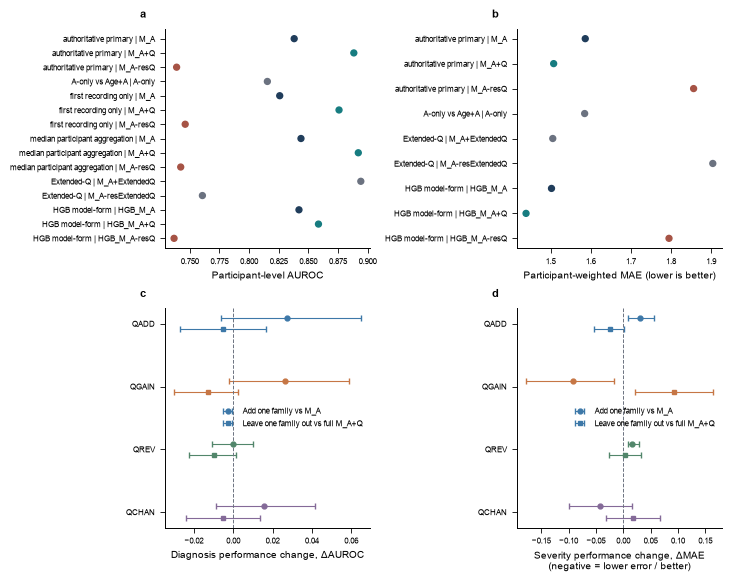

FIGURE S6: WRITTEN


In [22]:

# Sophisticated muted palette consistent with the Goal 1/Goal 2 visual system.
PALETTE={
    "M_A":"#203D5B","M_A+Q":"#167C80","M_A-resQ":"#A65345",
    "QADD":"#3D78A8","QGAIN":"#C67645","QREV":"#52866B","QCHAN":"#846A98",
    "neutral":"#6B7280","light":"#D9DEE5",
}
MM_TO_IN=1/25.4
mpl.rcParams.update({
    "font.family":"Arial","font.size":7,"axes.labelsize":7,"xtick.labelsize":6,"ytick.labelsize":6,
    "legend.fontsize":6,"axes.linewidth":.7,"xtick.major.width":.6,"ytick.major.width":.6,
    "pdf.fonttype":42,"ps.fonttype":42,"svg.fonttype":"none","figure.facecolor":"white","axes.facecolor":"white",
})

def clean_ax(ax):
    ax.grid(False); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.tick_params(direction="out")

def plabel(ax,s): ax.text(-.12,1.04,s,transform=ax.transAxes,fontsize=8,fontweight="bold",va="bottom")

fig,axes=plt.subplots(2,2,figsize=(183*MM_TO_IN,145*MM_TO_IN),constrained_layout=True)
# A diagnosis sensitivity point estimates.
ax=axes[0,0]
d=sensitivity_summary.loc[sensitivity_summary["task"].eq("diagnosis") & sensitivity_summary["AUROC"].notna()].copy()
labels=(d["sensitivity"]+" | "+d["model"]).tolist(); y=np.arange(len(d)); x=d["AUROC"].to_numpy(float)
ax.scatter(x,y,s=18,c=[PALETTE.get(m.replace("HGB_",""),PALETTE["neutral"]) for m in d["model"]],zorder=3)
ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis(); ax.set_xlabel("Participant-level AUROC"); clean_ax(ax); plabel(ax,"a")
# B severity sensitivity.
ax=axes[0,1]
s=sensitivity_summary.loc[sensitivity_summary["task"].eq("severity") & sensitivity_summary["MAE"].notna()].copy()
labels=(s["sensitivity"]+" | "+s["model"]).tolist(); y=np.arange(len(s)); x=s["MAE"].to_numpy(float)
ax.scatter(x,y,s=18,c=[PALETTE.get(m.replace("HGB_",""),PALETTE["neutral"]) for m in s["model"]],zorder=3)
ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis(); ax.set_xlabel("Participant-weighted MAE (lower is better)"); clean_ax(ax); plabel(ax,"b")
# C diagnosis Q-family localization: add-one and leave-one-out on one common AUROC scale.
ax=axes[1,0]
order=["QADD","QGAIN","QREV","QCHAN"]
f=family_ablations.loc[family_ablations["task"].eq("diagnosis")].copy()
for kind,offset,marker,label in [
    ("add_one",-.09,"o","Add one family vs M_A"),
    ("leave_one_out",.09,"s","Leave one family out vs full M_A+Q"),
]:
    z=(f.loc[f["ablation_type"].eq(kind)].set_index("q_family").reindex(order))
    yy=np.arange(len(order))+offset
    vals=z["performance_delta"].to_numpy(float)
    lo=z["ci_low"].to_numpy(float); hi=z["ci_high"].to_numpy(float)
    for j,fam in enumerate(order):
        ax.errorbar(
            vals[j],yy[j],
            xerr=np.array([[max(0.0,vals[j]-lo[j])],[max(0.0,hi[j]-vals[j])]]),
            fmt=marker,capsize=2,linewidth=.8,markersize=3.5,
            color=PALETTE[fam],
            label=label if j==0 else None,
        )
ax.axvline(0,color=PALETTE["neutral"],linestyle="--",linewidth=.7)
ax.set_yticks(np.arange(4)); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_xlabel("Diagnosis performance change, ΔAUROC")
ax.legend(frameon=False); clean_ax(ax); plabel(ax,"c")

# D severity Q-family localization on the MAE scale only.
ax=axes[1,1]
f=family_ablations.loc[family_ablations["task"].eq("severity")].copy()
for kind,offset,marker,label in [
    ("add_one",-.09,"o","Add one family vs M_A"),
    ("leave_one_out",.09,"s","Leave one family out vs full M_A+Q"),
]:
    z=(f.loc[f["ablation_type"].eq(kind)].set_index("q_family").reindex(order))
    yy=np.arange(len(order))+offset
    vals=z["performance_delta"].to_numpy(float)
    lo=z["ci_low"].to_numpy(float); hi=z["ci_high"].to_numpy(float)
    for j,fam in enumerate(order):
        ax.errorbar(
            vals[j],yy[j],
            xerr=np.array([[max(0.0,vals[j]-lo[j])],[max(0.0,hi[j]-vals[j])]]),
            fmt=marker,capsize=2,linewidth=.8,markersize=3.5,
            color=PALETTE[fam],
            label=label if j==0 else None,
        )
ax.axvline(0,color=PALETTE["neutral"],linestyle="--",linewidth=.7)
ax.set_yticks(np.arange(4)); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_xlabel("Severity performance change, ΔMAE\n(negative = lower error / better)")
ax.legend(frameon=False); clean_ax(ax); plabel(ax,"d")

stem="FigureS6_Goal2_completion_sensitivities"
fig.savefig(FIGURES/f"{stem}.pdf",bbox_inches="tight")
fig.savefig(FIGURES/f"{stem}.svg",bbox_inches="tight")
fig.savefig(FIGURES/f"{stem}.png",dpi=600,bbox_inches="tight")
plt.show()
print("FIGURE S6: WRITTEN")


## 27. Regenerate the authoritative main Goal 2 figures and native calibration supplement

Because the protocol-concordant residualizer may change `M_A-resQ`, Figures 3–4 and the calibration supplement are regenerated from the completion tables. These supersede Notebook 20's earlier residualized-model panels.


In [26]:
# ======================================================================
# SECTION 27A — RESTORE AUTHORITATIVE FIGURE INPUTS FROM SAVED TABLES
#
# NO statistical analysis is rerun.
# NO model is refit.
# NO bootstrap is rerun.
# NO GEE is rerun.
#
# This restores exactly the machine-readable tables written by the
# authoritative Goal 2 analysis.
# ======================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess


print("=" * 78, flush=True)
print(
    "SECTION 27A — RESTORING AUTHORITATIVE FIGURE INPUTS",
    flush=True,
)
print("=" * 78, flush=True)


# ----------------------------------------------------------------------
# 0. BASIC RUNTIME GATE
# ----------------------------------------------------------------------

required_runtime = [
    "TABLES",
    "FIGURES",
    "CORE_Q",
    "MODELS",
    "safe_read_csv",
    "atomic_write_csv",
]

missing_runtime = [
    x
    for x in required_runtime
    if x not in globals()
]

if missing_runtime:
    raise RuntimeError(
        "Figure runtime is incomplete. Missing: "
        + ", ".join(missing_runtime)
    )

print("Basic runtime: PASS", flush=True)


# ----------------------------------------------------------------------
# 1. Restore paired bootstrap summary used by Figure 3
#
# AUTHORITATIVE TABLE EXPECTATION:
#
# Diagnosis:
#   2 contrasts ×
#   [AUROC, Brier, CalibrationIntercept, CalibrationSlope]
#   = 8 rows
#
# Severity:
#   2 contrasts ×
#   [MAE, RMSE]
#   = 4 rows
#
# TOTAL = 12 rows.
#
# Figure 3 itself uses only:
#   diagnosis: AUROC + Brier
#   severity:  MAE + RMSE
#
# Calibration rows remain authoritative but are not plotted in Figure 3.
# ----------------------------------------------------------------------

bootstrap_path = (
    TABLES
    / "goal2_metrics_authoritative.csv"
)

authoritative_bootstrap = safe_read_csv(
    bootstrap_path,
    required_columns=[
        "task",
        "contrast",
        "metric",
        "estimate",
        "ci_low",
        "ci_high",
        "bootstrap_replicates",
    ],
)


# ------------------------------------------------
# Normalize types
# ------------------------------------------------

for col in [
    "task",
    "contrast",
    "metric",
]:
    authoritative_bootstrap[col] = (
        authoritative_bootstrap[col]
        .astype(str)
        .str.strip()
    )


for col in [
    "estimate",
    "ci_low",
    "ci_high",
    "bootstrap_replicates",
]:
    authoritative_bootstrap[col] = pd.to_numeric(
        authoritative_bootstrap[col],
        errors="raise",
    )


# ------------------------------------------------
# Exact expected analysis contract
# ------------------------------------------------

EXPECTED_CONTRASTS = {
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
}

EXPECTED_DX_METRICS = {
    "AUROC",
    "Brier",
    "CalibrationIntercept",
    "CalibrationSlope",
}

EXPECTED_SEV_METRICS = {
    "MAE",
    "RMSE",
}


dx_boot = (
    authoritative_bootstrap.loc[
        authoritative_bootstrap[
            "task"
        ].eq("diagnosis")
    ]
    .copy()
)

sev_boot = (
    authoritative_bootstrap.loc[
        authoritative_bootstrap[
            "task"
        ].eq("severity")
    ]
    .copy()
)


# ------------------------------------------------
# Exact row counts
# ------------------------------------------------

if len(
    authoritative_bootstrap
) != 12:

    display(
        authoritative_bootstrap
    )

    raise RuntimeError(
        "Expected 12 authoritative paired-bootstrap rows: "
        "8 diagnosis + 4 severity; "
        f"found {len(authoritative_bootstrap)}."
    )


if len(dx_boot) != 8:
    raise RuntimeError(
        "Expected 8 diagnosis bootstrap rows; "
        f"found {len(dx_boot)}."
    )


if len(sev_boot) != 4:
    raise RuntimeError(
        "Expected 4 severity bootstrap rows; "
        f"found {len(sev_boot)}."
    )


# ------------------------------------------------
# Exact contrasts
# ------------------------------------------------

if set(
    dx_boot[
        "contrast"
    ]
) != EXPECTED_CONTRASTS:

    raise RuntimeError(
        "Diagnosis bootstrap contrast set changed: "
        f"{sorted(dx_boot['contrast'].unique())}"
    )


if set(
    sev_boot[
        "contrast"
    ]
) != EXPECTED_CONTRASTS:

    raise RuntimeError(
        "Severity bootstrap contrast set changed: "
        f"{sorted(sev_boot['contrast'].unique())}"
    )


# ------------------------------------------------
# Exact metrics
# ------------------------------------------------

if set(
    dx_boot[
        "metric"
    ]
) != EXPECTED_DX_METRICS:

    raise RuntimeError(
        "Diagnosis bootstrap metric set changed: "
        f"{sorted(dx_boot['metric'].unique())}"
    )


if set(
    sev_boot[
        "metric"
    ]
) != EXPECTED_SEV_METRICS:

    raise RuntimeError(
        "Severity bootstrap metric set changed: "
        f"{sorted(sev_boot['metric'].unique())}"
    )


# ------------------------------------------------
# Exactly one row / contrast / metric
# ------------------------------------------------

if (
    dx_boot
    .groupby(
        [
            "contrast",
            "metric",
        ]
    )
    .size()
    .ne(1)
    .any()
):

    raise RuntimeError(
        "Diagnosis authoritative bootstrap has "
        "duplicate/missing contrast × metric rows."
    )


if (
    sev_boot
    .groupby(
        [
            "contrast",
            "metric",
        ]
    )
    .size()
    .ne(1)
    .any()
):

    raise RuntimeError(
        "Severity authoritative bootstrap has "
        "duplicate/missing contrast × metric rows."
    )


# ------------------------------------------------
# Bootstrap count
# ------------------------------------------------

if not (
    authoritative_bootstrap[
        "bootstrap_replicates"
    ].eq(2000)
).all():

    raise RuntimeError(
        "Authoritative bootstrap table does not "
        "uniformly contain 2,000 replicates."
    )


# ------------------------------------------------
# Numerical integrity
# ------------------------------------------------

numeric_check = (
    authoritative_bootstrap[
        [
            "estimate",
            "ci_low",
            "ci_high",
        ]
    ]
    .to_numpy(float)
)


if not np.isfinite(
    numeric_check
).all():

    raise RuntimeError(
        "Authoritative bootstrap table contains "
        "non-finite estimates/CIs."
    )


if (
    authoritative_bootstrap[
        "ci_low"
    ]
    >
    authoritative_bootstrap[
        "ci_high"
    ]
).any():

    raise RuntimeError(
        "Authoritative bootstrap CI ordering failure."
    )


# ------------------------------------------------
# Explicit Figure-3 subset
# ------------------------------------------------

figure3_bootstrap = (
    authoritative_bootstrap.loc[
        (
            authoritative_bootstrap[
                "task"
            ].eq("diagnosis")
            &
            authoritative_bootstrap[
                "metric"
            ].isin(
                [
                    "AUROC",
                    "Brier",
                ]
            )
        )
        |
        (
            authoritative_bootstrap[
                "task"
            ].eq("severity")
            &
            authoritative_bootstrap[
                "metric"
            ].isin(
                [
                    "MAE",
                    "RMSE",
                ]
            )
        )
    ]
    .copy()
)


if len(
    figure3_bootstrap
) != 8:

    raise RuntimeError(
        "Expected exactly 8 Figure-3 bootstrap rows; "
        f"found {len(figure3_bootstrap)}."
    )


print(
    "\n[1/4] authoritative_bootstrap: PASS",
    flush=True,
)

print(
    "  authoritative rows:",
    len(authoritative_bootstrap),
    "(expected 12)",
    flush=True,
)

print(
    "  diagnosis rows:",
    len(dx_boot),
    "(expected 8)",
    flush=True,
)

print(
    "  severity rows:",
    len(sev_boot),
    "(expected 4)",
    flush=True,
)

print(
    "  Figure-3 plotted rows:",
    len(figure3_bootstrap),
    "(expected 8)",
    flush=True,
)

print(
    "  diagnosis calibration bootstrap rows retained:",
    4,
    flush=True,
)

print(
    "  bootstrap replicates per contrast/metric:",
    2000,
    flush=True,
)

print(
    "  source:",
    bootstrap_path,
    flush=True,
)


print(
    "\nFigure-3 paired effects:",
    flush=True,
)

display(
    figure3_bootstrap[
        [
            "task",
            "contrast",
            "metric",
            "estimate",
            "ci_low",
            "ci_high",
            "bootstrap_replicates",
        ]
    ]
)
# ----------------------------------------------------------------------
# 2. Restore individual prediction shifts used by Figure 3b/3d
# ----------------------------------------------------------------------

shift_path = (
    TABLES
    / "goal2_prediction_shifts_authoritative.csv"
)

prediction_shifts = safe_read_csv(
    shift_path,
    required_columns=[
        "participant_id",
        "task",
        "comparison",
        "base_prediction",
        "comparison_prediction",
        "signed_shift",
        "absolute_shift",
    ],
)

for col in [
    "base_prediction",
    "comparison_prediction",
    "signed_shift",
    "absolute_shift",
]:
    prediction_shifts[col] = pd.to_numeric(
        prediction_shifts[col],
        errors="raise",
    )

if not np.isfinite(
    prediction_shifts[
        [
            "base_prediction",
            "comparison_prediction",
            "signed_shift",
            "absolute_shift",
        ]
    ].to_numpy(float)
).all():
    raise RuntimeError(
        "Prediction-shift table contains non-finite values."
    )

if (
    prediction_shifts[
        "absolute_shift"
    ] < 0
).any():
    raise RuntimeError(
        "absolute_shift contains a negative value."
    )

expected_comparisons = {
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
}

if set(
    prediction_shifts[
        "comparison"
    ].astype(str)
) != expected_comparisons:
    raise RuntimeError(
        "Prediction-shift comparison set changed."
    )

task_counts = (
    prediction_shifts
    .groupby("task")
    .size()
    .to_dict()
)

print(
    "\n[2/4] prediction_shifts: PASS",
    flush=True,
)
print(
    "  rows:",
    len(prediction_shifts),
    flush=True,
)
print(
    "  task rows:",
    task_counts,
    flush=True,
)
print(
    "  source:",
    shift_path,
    flush=True,
)


# ----------------------------------------------------------------------
# 3. Restore Q-dependent OOF-error associations used by Figure 4
# ----------------------------------------------------------------------

assoc_path = (
    TABLES
    / "goal2_q_error_associations.csv"
)

q_error_associations = safe_read_csv(
    assoc_path,
    required_columns=[
        "task",
        "q_feature",
        "q_family",
        "model",
        "component",
        "effect_per_1IQR_Q",
        "ci_low",
        "ci_high",
        "p_value",
        "cov_structure",
        "status",
    ],
)

for col in [
    "effect_per_1IQR_Q",
    "ci_low",
    "ci_high",
]:
    q_error_associations[col] = pd.to_numeric(
        q_error_associations[col],
        errors="coerce",
    )

primary_assoc_check = (
    q_error_associations.loc[
        q_error_associations[
            "cov_structure"
        ].eq("independence")
        &
        q_error_associations[
            "status"
        ].eq("ok")
    ]
    .copy()
)

required_fig4_models = [
    "M_A",
    "M_A+Q",
    "M_A-resQ",
    "M_A+Q-minus-M_A-loss",
    "M_A-resQ-minus-M_A-loss",
]

required_components = [
    "between",
    "within",
]


# Hard gate only on combinations actually required by Figure 4.
missing_combinations = []

for task in [
    "diagnosis",
    "severity",
]:
    for model in required_fig4_models:
        for component in required_components:
            for q in CORE_Q:

                match = primary_assoc_check.loc[
                    primary_assoc_check[
                        "task"
                    ].eq(task)
                    &
                    primary_assoc_check[
                        "model"
                    ].eq(model)
                    &
                    primary_assoc_check[
                        "component"
                    ].eq(component)
                    &
                    primary_assoc_check[
                        "q_feature"
                    ].eq(q)
                ]

                if len(match) != 1:
                    missing_combinations.append(
                        (
                            task,
                            model,
                            component,
                            q,
                            len(match),
                        )
                    )

if missing_combinations:
    print(
        "\nMissing/duplicated Figure-4 combinations:",
        flush=True,
    )

    for row in missing_combinations[:30]:
        print(
            " ",
            row,
            flush=True,
        )

    raise RuntimeError(
        "Figure 4 does not have exactly one primary "
        "association estimate for every required combination."
    )


required_assoc_rows = (
    primary_assoc_check.loc[
        primary_assoc_check[
            "model"
        ].isin(required_fig4_models)
        &
        primary_assoc_check[
            "component"
        ].isin(required_components)
        &
        primary_assoc_check[
            "q_feature"
        ].isin(CORE_Q)
    ]
)

if not np.isfinite(
    required_assoc_rows[
        [
            "effect_per_1IQR_Q",
            "ci_low",
            "ci_high",
        ]
    ].to_numpy(float)
).all():
    raise RuntimeError(
        "Figure-4 required association rows contain "
        "non-finite effects/CIs."
    )

print(
    "\n[3/4] q_error_associations: PASS",
    flush=True,
)
print(
    "  total rows:",
    len(q_error_associations),
    flush=True,
)
print(
    "  required primary Figure-4 rows:",
    len(required_assoc_rows),
    flush=True,
)
print(
    "  expected required rows:",
    2 * 5 * 2 * len(CORE_Q),
    flush=True,
)
print(
    "  source:",
    assoc_path,
    flush=True,
)


# ----------------------------------------------------------------------
# 4. Restore participant-collapsed diagnosis OOF used by S3
# ----------------------------------------------------------------------

dx_final_path = (
    TABLES
    / "goal2_dx_participant_oof_authoritative.csv"
)

dx_final = safe_read_csv(
    dx_final_path,
    required_columns=[
        "model",
        "participant_id",
        "y",
        "prediction",
    ],
)

dx_final["y"] = pd.to_numeric(
    dx_final["y"],
    errors="raise",
)

dx_final["prediction"] = pd.to_numeric(
    dx_final["prediction"],
    errors="raise",
)

if set(
    dx_final["model"].astype(str)
) != set(MODELS):
    raise RuntimeError(
        "dx_final model set changed."
    )

if (
    dx_final[
        "participant_id"
    ].nunique()
    != 199
):
    raise RuntimeError(
        "dx_final should contain 199 diagnosis participants."
    )

if len(dx_final) != (
    199 * len(MODELS)
):
    raise RuntimeError(
        "dx_final should contain "
        f"{199 * len(MODELS)} rows; "
        f"found {len(dx_final)}."
    )

if not np.isfinite(
    dx_final[
        ["y", "prediction"]
    ].to_numpy(float)
).all():
    raise RuntimeError(
        "dx_final contains non-finite values."
    )

if not dx_final[
    "prediction"
].between(
    0,
    1,
).all():
    raise RuntimeError(
        "Diagnosis predicted probabilities outside [0,1]."
    )

print(
    "\n[4/4] dx_final: PASS",
    flush=True,
)
print(
    "  rows:",
    len(dx_final),
    flush=True,
)
print(
    "  participants:",
    dx_final[
        "participant_id"
    ].nunique(),
    flush=True,
)
print(
    "  source:",
    dx_final_path,
    flush=True,
)


# ----------------------------------------------------------------------
# 5. Restore exact visual system used in Section 26/27
# ----------------------------------------------------------------------

PALETTE = {
    "M_A": "#203D5B",
    "M_A+Q": "#167C80",
    "M_A-resQ": "#A65345",
    "QADD": "#3D78A8",
    "QGAIN": "#C67645",
    "QREV": "#52866B",
    "QCHAN": "#846A98",
    "neutral": "#6B7280",
    "light": "#D9DEE5",
}

MM_TO_IN = 1 / 25.4

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": .7,
    "xtick.major.width": .6,
    "ytick.major.width": .6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def clean_ax(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(
        direction="out"
    )


def plabel(ax, s):
    ax.text(
        -.12,
        1.04,
        s,
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="bottom",
    )


# If an earlier kernel rehydration lost this helper,
# restore the exact display-calibration calculation.
if "safe_calibration_stats" not in globals():

    import statsmodels.api as sm

    def safe_calibration_stats(y, p):

        y = np.asarray(
            y,
            float,
        )

        p = np.clip(
            np.asarray(
                p,
                float,
            ),
            1e-6,
            1 - 1e-6,
        )

        if len(
            np.unique(y)
        ) < 2:
            return (
                np.nan,
                np.nan,
            )

        lp = np.log(
            p
            /
            (1 - p)
        )

        try:
            intercept = float(
                sm.GLM(
                    y,
                    np.ones(
                        (
                            len(y),
                            1,
                        )
                    ),
                    family=(
                        sm.families
                        .Binomial()
                    ),
                    offset=lp,
                )
                .fit()
                .params[0]
            )
        except Exception:
            intercept = np.nan

        try:
            slope = float(
                sm.GLM(
                    y,
                    sm.add_constant(
                        lp
                    ),
                    family=(
                        sm.families
                        .Binomial()
                    ),
                )
                .fit()
                .params[1]
            )
        except Exception:
            slope = np.nan

        return (
            intercept,
            slope,
        )


# ----------------------------------------------------------------------
# 6. Final figure-state gate
# ----------------------------------------------------------------------

required_figure_state = [
    "authoritative_bootstrap",
    "prediction_shifts",
    "q_error_associations",
    "dx_final",
    "PALETTE",
    "MM_TO_IN",
    "clean_ax",
    "plabel",
    "safe_calibration_stats",
    "lowess",
]

missing_figure_state = [
    x
    for x in required_figure_state
    if x not in globals()
]

if missing_figure_state:
    raise RuntimeError(
        "Figure state is still incomplete: "
        + ", ".join(
            missing_figure_state
        )
    )


print()
print("=" * 78, flush=True)
print(
    "SECTION 27A FIGURE STATE RESTORATION: PASS",
    flush=True,
)
print("=" * 78, flush=True)

print(
    "Paired bootstrap analysis rerun:",
    False,
    flush=True,
)

print(
    "Prediction models rerun:",
    False,
    flush=True,
)

print(
    "Q-loss GEE rerun:",
    False,
    flush=True,
)

print(
    "Figure inputs loaded from authoritative saved tables:",
    True,
    flush=True,
)

print(
    "Ready for Figures 3, 4 diagnosis, 4 severity, and S3.",
    flush=True,
)

SECTION 27A — RESTORING AUTHORITATIVE FIGURE INPUTS
Basic runtime: PASS

[1/4] authoritative_bootstrap: PASS
  authoritative rows: 12 (expected 12)
  diagnosis rows: 8 (expected 8)
  severity rows: 4 (expected 4)
  Figure-3 plotted rows: 8 (expected 8)
  diagnosis calibration bootstrap rows retained: 4
  bootstrap replicates per contrast/metric: 2000
  source: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_metrics_authoritative.csv

Figure-3 paired effects:


,task,contrast,metric,estimate,ci_low,ci_high,bootstrap_replicates
0,diagnosis,M_A+Q minus M_A,AUROC,0.050309,0.009286,0.093498,2000
1,diagnosis,M_A+Q minus M_A,Brier,-0.018991,-0.032346,-0.006452,2000
4,severity,M_A+Q minus M_A,MAE,-0.078697,-0.162924,0.011051,2000
5,severity,M_A+Q minus M_A,RMSE,-0.103196,-0.204614,-0.000364,2000
6,diagnosis,M_A-resQ minus M_A,AUROC,-0.099166,-0.160163,-0.047627,2000
7,diagnosis,M_A-resQ minus M_A,Brier,0.021969,0.011017,0.032924,2000
10,severity,M_A-resQ minus M_A,MAE,0.269940,0.151271,0.385381,2000
11,severity,M_A-resQ minus M_A,RMSE,0.267226,0.127787,0.414113,2000



[2/4] prediction_shifts: PASS
  rows: 1194
  task rows: {'diagnosis': 398, 'severity': 796}
  source: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_prediction_shifts_authoritative.csv

[3/4] q_error_associations: PASS
  total rows: 516
  required primary Figure-4 rows: 240
  expected required rows: 240
  source: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_q_error_associations.csv

[4/4] dx_final: PASS
  rows: 597
  participants: 199
  source: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\tables\goal2_dx_participant_oof_authoritative.csv

SECTION 27A FIGURE STATE RESTORATION: PASS
Paired bootstrap analysis rerun: False
Prediction models rerun: False
Q-loss GEE rerun: False
Figure inputs loaded from authoritative saved tables: True
Ready for Figures 3, 4 diagnosis, 4 severity, and S3.


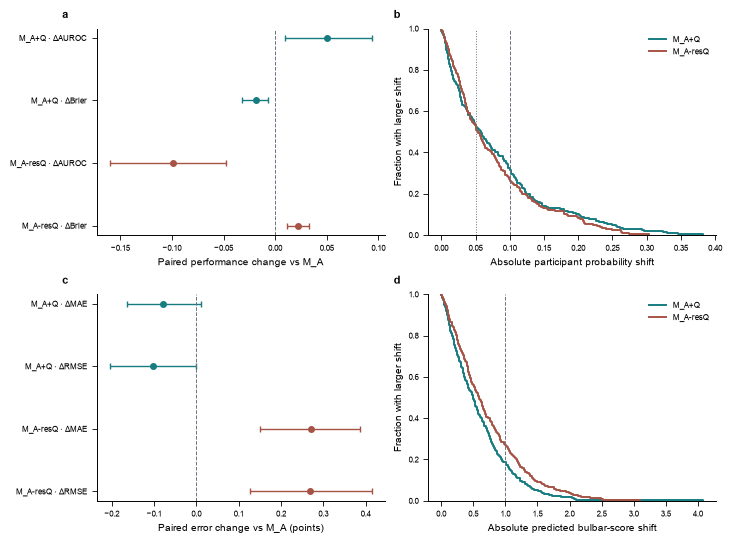

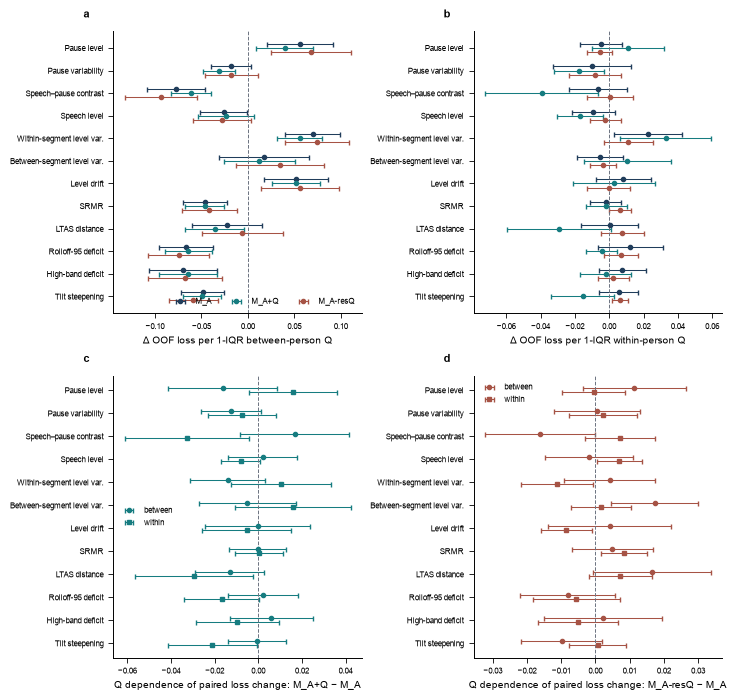

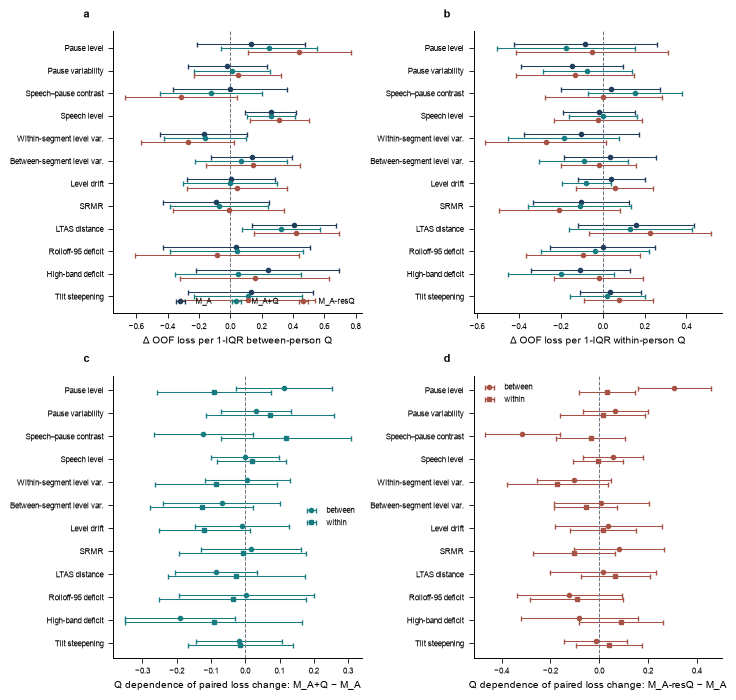

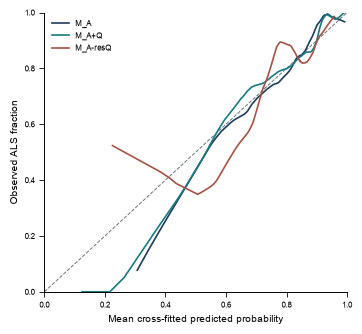

AUTHORITATIVE FIGURES 3, 4 (diagnosis/severity), AND S3: WRITTEN


In [27]:

# Human-readable feature labels kept short to prevent crowding.
Q_LABELS={
    "qadd_pause_ac_level_dbfs_median":"Pause level",
    "qadd_pause_level_iqr_db":"Pause variability",
    "qadd_speech_pause_level_contrast_db":"Speech–pause contrast",
    "qgain_typical_speech_level_dbfs":"Speech level",
    "qgain_within_segment_iqr_db":"Within-segment level var.",
    "qgain_between_segment_mad_db":"Between-segment level var.",
    "qgain_abs_drift_db_per_min":"Level drift",
    "qrev_srmr_norm":"SRMR",
    "qchan_ltas_distance_db":"LTAS distance",
    "qchan_rolloff95_deficit_hz":"Rolloff-95 deficit",
    "qchan_highband_ratio_deficit":"High-band deficit",
    "qchan_tilt_steepening_db_per_oct":"Tilt steepening",
}

# ------------------------------- Figure 3 -------------------------------
fig,axes=plt.subplots(2,2,figsize=(183*MM_TO_IN,135*MM_TO_IN),constrained_layout=True)

# a: paired diagnosis performance changes.
ax=axes[0,0]
d=authoritative_bootstrap.loc[authoritative_bootstrap["task"].eq("diagnosis") & authoritative_bootstrap["metric"].isin(["AUROC","Brier"])].copy()
d["label"]=d["contrast"].str.replace(" minus M_A","",regex=False)+" · Δ"+d["metric"]
y=np.arange(len(d)); x=d["estimate"].to_numpy(float); lo=d["ci_low"].to_numpy(float); hi=d["ci_high"].to_numpy(float)
colors=[PALETTE["M_A+Q"] if s.startswith("M_A+Q") else PALETTE["M_A-resQ"] for s in d["contrast"]]
for yi,xi,l,h,c in zip(y,x,lo,hi,colors):
    ax.errorbar(xi,yi,xerr=[[xi-l],[h-xi]],fmt="o",color=c,capsize=2,linewidth=1,markersize=4)
ax.axvline(0,color=PALETTE["neutral"],linestyle="--",linewidth=.7)
ax.set_yticks(y); ax.set_yticklabels(d["label"]); ax.invert_yaxis(); ax.set_xlabel("Paired performance change vs M_A"); clean_ax(ax); plabel(ax,"a")

# b: diagnosis absolute shift empirical survival curves.
ax=axes[0,1]
for comparison,color,label in [("M_A+Q minus M_A",PALETTE["M_A+Q"],"M_A+Q"),("M_A-resQ minus M_A",PALETTE["M_A-resQ"],"M_A-resQ")]:
    vals=np.sort(prediction_shifts.loc[prediction_shifts["task"].eq("diagnosis") & prediction_shifts["comparison"].eq(comparison),"absolute_shift"].to_numpy(float))
    if len(vals):
        surv=1-np.arange(1,len(vals)+1)/len(vals)
        ax.step(vals,surv,where="post",color=color,linewidth=1.4,label=label)
for anchor in [.05,.10]: ax.axvline(anchor,color=PALETTE["neutral"],linestyle=":" if anchor==.05 else "--",linewidth=.7)
ax.set_xlabel("Absolute participant probability shift"); ax.set_ylabel("Fraction with larger shift"); ax.set_ylim(0,1); ax.legend(frameon=False); clean_ax(ax); plabel(ax,"b")

# c: severity paired changes.
ax=axes[1,0]
s=authoritative_bootstrap.loc[authoritative_bootstrap["task"].eq("severity") & authoritative_bootstrap["metric"].isin(["MAE","RMSE"])].copy()
s["label"]=s["contrast"].str.replace(" minus M_A","",regex=False)+" · Δ"+s["metric"]
y=np.arange(len(s)); x=s["estimate"].to_numpy(float); lo=s["ci_low"].to_numpy(float); hi=s["ci_high"].to_numpy(float)
colors=[PALETTE["M_A+Q"] if z.startswith("M_A+Q") else PALETTE["M_A-resQ"] for z in s["contrast"]]
for yi,xi,l,h,c in zip(y,x,lo,hi,colors): ax.errorbar(xi,yi,xerr=[[xi-l],[h-xi]],fmt="o",color=c,capsize=2,linewidth=1,markersize=4)
ax.axvline(0,color=PALETTE["neutral"],linestyle="--",linewidth=.7); ax.set_yticks(y); ax.set_yticklabels(s["label"]); ax.invert_yaxis(); ax.set_xlabel("Paired error change vs M_A (points)"); clean_ax(ax); plabel(ax,"c")

# d: severity shifts.
ax=axes[1,1]
for comparison,color,label in [("M_A+Q minus M_A",PALETTE["M_A+Q"],"M_A+Q"),("M_A-resQ minus M_A",PALETTE["M_A-resQ"],"M_A-resQ")]:
    vals=np.sort(prediction_shifts.loc[prediction_shifts["task"].eq("severity") & prediction_shifts["comparison"].eq(comparison),"absolute_shift"].to_numpy(float))
    if len(vals):
        surv=1-np.arange(1,len(vals)+1)/len(vals); ax.step(vals,surv,where="post",color=color,linewidth=1.4,label=label)
ax.axvline(1.0,color=PALETTE["neutral"],linestyle="--",linewidth=.7)
ax.set_xlabel("Absolute predicted bulbar-score shift"); ax.set_ylabel("Fraction with larger shift"); ax.set_ylim(0,1); ax.legend(frameon=False); clean_ax(ax); plabel(ax,"d")

stem="Figure3_Goal2_inference_change_AUTHORITATIVE"
for ext,kwargs in [("pdf",{}),("svg",{}),("png",{"dpi":600})]: fig.savefig(FIGURES/f"{stem}.{ext}",bbox_inches="tight",**kwargs)
plt.show()

# ------------------------------- Figure 4 -------------------------------
primary_assoc=q_error_associations.loc[
    q_error_associations["cov_structure"].eq("independence")
    & q_error_associations["status"].eq("ok")
].copy()
q_order=CORE_Q
model_offsets={"M_A":-.18,"M_A+Q":0.0,"M_A-resQ":.18}


def make_figure4_for_task(task):
    local_assoc=primary_assoc.loc[primary_assoc["task"].eq(task)].copy()
    fig,axes=plt.subplots(2,2,figsize=(183*MM_TO_IN,175*MM_TO_IN),constrained_layout=True)

    def forest_models(ax,component):
        for model in MODELS:
            z=(local_assoc.loc[
                local_assoc["model"].eq(model) & local_assoc["component"].eq(component)
            ].set_index("q_feature").reindex(q_order))
            yy=np.arange(len(q_order))+model_offsets[model]
            x=z["effect_per_1IQR_Q"].to_numpy(float)
            lo=z["ci_low"].to_numpy(float); hi=z["ci_high"].to_numpy(float)
            ax.errorbar(x,yy,xerr=np.vstack([x-lo,hi-x]),fmt="o",color=PALETTE[model],
                        capsize=1.8,linewidth=.75,markersize=3,label=model)
        ax.axvline(0,color=PALETTE["neutral"],linestyle="--",linewidth=.7)
        ax.set_yticks(np.arange(len(q_order)))
        ax.set_yticklabels([Q_LABELS.get(q,q) for q in q_order])
        ax.invert_yaxis(); clean_ax(ax)

    forest_models(axes[0,0],"between")
    axes[0,0].set_xlabel("Δ OOF loss per 1-IQR between-person Q")
    axes[0,0].legend(frameon=False,ncol=3,loc="lower right")
    plabel(axes[0,0],"a")

    forest_models(axes[0,1],"within")
    axes[0,1].set_xlabel("Δ OOF loss per 1-IQR within-person Q")
    plabel(axes[0,1],"b")

    def forest_delta(ax,comparison_model,title,color):
        z=local_assoc.loc[local_assoc["model"].eq(comparison_model)].copy()
        for component,offset,marker in [("between",-.08,"o"),("within",.08,"s")]:
            zz=z.loc[z["component"].eq(component)].set_index("q_feature").reindex(q_order)
            yy=np.arange(len(q_order))+offset
            x=zz["effect_per_1IQR_Q"].to_numpy(float)
            lo=zz["ci_low"].to_numpy(float); hi=zz["ci_high"].to_numpy(float)
            ax.errorbar(x,yy,xerr=np.vstack([x-lo,hi-x]),fmt=marker,color=color,
                        capsize=1.8,linewidth=.75,markersize=3,label=component)
        ax.axvline(0,color=PALETTE["neutral"],linestyle="--",linewidth=.7)
        ax.set_yticks(np.arange(len(q_order)))
        ax.set_yticklabels([Q_LABELS.get(q,q) for q in q_order])
        ax.invert_yaxis(); ax.set_xlabel(title); ax.legend(frameon=False); clean_ax(ax)

    forest_delta(axes[1,0],"M_A+Q-minus-M_A-loss",
                 "Q dependence of paired loss change: M_A+Q − M_A",PALETTE["M_A+Q"])
    plabel(axes[1,0],"c")
    forest_delta(axes[1,1],"M_A-resQ-minus-M_A-loss",
                 "Q dependence of paired loss change: M_A-resQ − M_A",PALETTE["M_A-resQ"])
    plabel(axes[1,1],"d")

    stem=f"Figure4_Goal2_Q_dependent_error_{task}_AUTHORITATIVE"
    for ext,kwargs in [("pdf",{}),("svg",{}),("png",{"dpi":600})]:
        fig.savefig(FIGURES/f"{stem}.{ext}",bbox_inches="tight",**kwargs)
    plt.show()

make_figure4_for_task("diagnosis")
make_figure4_for_task("severity")

# -------------------------- Supplementary calibration --------------------------
fig,ax=plt.subplots(figsize=(89*MM_TO_IN,82*MM_TO_IN),constrained_layout=True)
ax.plot([0,1],[0,1],linestyle="--",color=PALETTE["neutral"],linewidth=.7)
cal_rows=[]
for model in MODELS:
    g=dx_final.loc[dx_final["model"].eq(model)].copy()
    smooth=lowess(g["y"].to_numpy(float),g["prediction"].to_numpy(float),frac=.40,it=0,return_sorted=True)
    ax.plot(smooth[:,0],np.clip(smooth[:,1],0,1),color=PALETTE[model],linewidth=1.2,label=model)
    intercept,slope=safe_calibration_stats(g["y"].to_numpy(float),g["prediction"].to_numpy(float))
    cal_rows.append({"model":model,"calibration_intercept_display":intercept,"calibration_slope_display":slope})
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_xlabel("Mean cross-fitted predicted probability"); ax.set_ylabel("Observed ALS fraction"); ax.legend(frameon=False); clean_ax(ax)
cal_display=pd.DataFrame(cal_rows); atomic_write_csv(cal_display,TABLES/"goal2_diagnosis_calibration_display_authoritative.csv")
stem="FigureS3_Goal2_native_calibration_AUTHORITATIVE"
for ext,kwargs in [("pdf",{}),("svg",{}),("png",{"dpi":600})]: fig.savefig(FIGURES/f"{stem}.{ext}",bbox_inches="tight",**kwargs)
plt.show()
print("AUTHORITATIVE FIGURES 3, 4 (diagnosis/severity), AND S3: WRITTEN")


## 28. Final Goal 2 completion seal

The seal requires the corrected protocol-concordant primary OOF, 2,000 paired bootstrap results, family ablations, Q-loss robustness, coefficient stability, and the HGB sensitivity. Optional Platt recalibration is explicitly not required because the frozen Methods label it optional and native calibration is the primary estimand. The overlap restriction is conditional; diagnostics are saved and must be reviewed before deciding whether that conditional sensitivity is triggered.


In [28]:

required_files=[
    OOF_DIR/"goal2_diagnosis_oof_authoritative.csv",
    OOF_DIR/"goal2_severity_oof_authoritative.csv",
    TABLES/"goal2_protocol_concordance_audit.csv",
    TABLES/"goal2_corrected_residualizer_fold_manifest.csv",
    TABLES/"goal2_authoritative_observed_metrics.csv",
    TABLES/"goal2_metrics_authoritative.csv",
    TABLES/"goal2_prediction_shifts_authoritative.csv",
    TABLES/"goal2_q_error_associations.csv",
    TABLES/"goal2_q_loss_sensitivity.csv",
    TABLES/"goal2_sensitivity_summary.csv",
    TABLES/"goal2_family_ablations.csv",
    TABLES/"goal2_ridge_coefficient_stability.csv",
    TABLES/"goal2_overlap_diagnostics.csv",
    FIGURES/"FigureS6_Goal2_completion_sensitivities.pdf",
    FIGURES/"Figure3_Goal2_inference_change_AUTHORITATIVE.pdf",
    FIGURES/"Figure4_Goal2_Q_dependent_error_diagnosis_AUTHORITATIVE.pdf",
    FIGURES/"Figure4_Goal2_Q_dependent_error_severity_AUTHORITATIVE.pdf",
    FIGURES/"FigureS3_Goal2_native_calibration_AUTHORITATIVE.pdf",
]
if RUN_HGB:
    required_files.append(TABLES/"goal2_hgb_fold_manifest.csv")
bad=[str(p) for p in required_files if (not p.exists()) or p.stat().st_size==0]
if bad:
    raise RuntimeError("Goal 2 completion cannot be sealed; missing/empty artifacts:\n"+"\n".join(bad))
if not RUN_HGB:
    raise RuntimeError("Goal 2 complete seal requires RUN_HGB=True.")

# Hash every final completion artifact.
artifact_hashes={str(p.relative_to(ROOT)):sha256_file(p) for p in required_files}
completion_manifest={
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "status":"PASS_PENDING_OVERLAP_REVIEW",
    "engine_version":"goal2-completion-v1.0.0",
    "primary_notebook20_success":primary_success,
    "a_freeze_version":a_manifest["a_freeze_version"],
    "paper1_commit":observed_paper1_commit,
    "outer_cv":"5 folds x 10 repeats, participant grouped",
    "inner_cv":"5 participant-grouped folds",
    "bootstrap_replicates":N_COMPLETION_BOOTSTRAPS,
    "residualizer_alpha_rule":"outer-training grouped CV on standardized A reconstruction error over 1e-4...1e4",
    "optional_platt":"not run; optional by frozen Methods, native calibration remains primary",
    "overlap_restriction":"conditional; inspect goal2_overlap_diagnostics.csv before final DONE seal",
    "artifact_hashes":artifact_hashes,
    "interpretation_boundary":"Goal 2 demonstrates observational model dependence/sensitivity, not a unique physical technical cause.",
}
atomic_write_json(completion_manifest,OUT/"GOAL2_COMPLETION_MANIFEST.json")

print("\nGOAL 2 COMPLETION ANALYSES: PASS")
print("Status: PASS_PENDING_OVERLAP_REVIEW")
print("Next action: send me the final tables printed below, especially overlap diagnostics, so we can decide whether the conditional overlap-restricted sensitivity is triggered and then write DONE.json.")
print("Output directory:",OUT)
display(authoritative_bootstrap)
display(family_ablations)
display(overlap_diagnostics)



GOAL 2 COMPLETION ANALYSES: PASS
Status: PASS_PENDING_OVERLAP_REVIEW
Next action: send me the final tables printed below, especially overlap diagnostics, so we can decide whether the conditional overlap-restricted sensitivity is triggered and then write DONE.json.
Output directory: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final


,task,contrast,metric,estimate,ci_low,ci_high,bootstrap_replicates
0,diagnosis,M_A+Q minus M_A,AUROC,0.050309,0.009286,0.093498,2000
1,diagnosis,M_A+Q minus M_A,Brier,-0.018991,-0.032346,-0.006452,2000
2,diagnosis,M_A+Q minus M_A,CalibrationIntercept,-0.000285,-0.122796,0.120579,2000
3,diagnosis,M_A+Q minus M_A,CalibrationSlope,0.113820,-0.256436,0.500842,2000
4,severity,M_A+Q minus M_A,MAE,-0.078697,-0.162924,0.011051,2000
5,severity,M_A+Q minus M_A,RMSE,-0.103196,-0.204614,-0.000364,2000
6,diagnosis,M_A-resQ minus M_A,AUROC,-0.099166,-0.160163,-0.047627,2000
7,diagnosis,M_A-resQ minus M_A,Brier,0.021969,0.011017,0.032924,2000
8,diagnosis,M_A-resQ minus M_A,CalibrationIntercept,0.004741,-0.087600,0.104017,2000
9,diagnosis,M_A-resQ minus M_A,CalibrationSlope,-0.104610,-0.459295,0.280721,2000


,task,ablation_type,q_family,metric,performance_delta,ci_low,ci_high,mean_paired_loss_delta,p_value,q_value
0,diagnosis,add_one,QADD,AUROC,0.027416,-0.006463,0.064852,-0.009827,0.024984,0.099936
1,diagnosis,add_one,QGAIN,AUROC,0.026366,-0.001932,0.058732,-0.001779,0.613562,0.613562
2,diagnosis,add_one,QREV,AUROC,-0.000370,-0.011037,0.009957,0.001180,0.387467,0.516623
3,diagnosis,add_one,QCHAN,AUROC,0.015560,-0.008618,0.041797,-0.003447,0.254481,0.508962
4,diagnosis,leave_one_out,QADD,AUROC,-0.005434,-0.027278,0.016516,0.003791,0.204580,0.818319
5,diagnosis,leave_one_out,QGAIN,AUROC,-0.013044,-0.030092,0.002608,0.000399,0.876308,0.876308
6,diagnosis,leave_one_out,QREV,AUROC,-0.009663,-0.022475,0.001247,0.000401,0.833396,0.876308
7,diagnosis,leave_one_out,QCHAN,AUROC,-0.005434,-0.024193,0.013380,0.001931,0.490772,0.876308
8,severity,add_one,QADD,MAE,0.031324,0.007927,0.055592,0.020838,0.057586,0.112485
9,severity,add_one,QGAIN,MAE,-0.092714,-0.177721,-0.016278,-0.059564,0.084363,0.112485


,q_feature,control_q05,control_q95,als_q05,als_q95,common_low,common_high,common_interval_nonempty,control_fraction_in_common,als_fraction_in_common
0,qadd_pause_ac_level_dbfs_median,-71.089201,-45.640227,-82.586708,-52.460989,-71.089201,-52.460989,True,0.552632,0.639456
1,qadd_pause_level_iqr_db,2.317320,17.254867,2.507994,26.315678,2.507994,17.254867,True,0.848485,0.797203
2,qadd_speech_pause_level_contrast_db,11.100689,40.557073,24.417366,52.752812,24.417366,40.557073,True,0.473684,0.544218
3,qgain_typical_speech_level_dbfs,-37.500631,-25.336615,-36.704887,-23.281473,-36.704887,-25.336615,True,0.878049,0.740506
4,qgain_within_segment_iqr_db,8.333702,13.114756,5.298631,13.687269,8.333702,13.114756,True,0.902439,0.651899
5,qgain_between_segment_mad_db,1.276012,4.286877,1.106044,3.461410,1.276012,3.461410,True,0.804878,0.835443
6,qgain_abs_drift_db_per_min,1.018229,13.314574,0.631302,8.372168,1.018229,8.372168,True,0.609756,0.860759
7,qrev_srmr_norm,2.717126,3.802853,2.767583,4.559818,2.767583,3.802853,True,0.878049,0.645570
8,qchan_ltas_distance_db,3.262658,7.005354,3.363726,9.520729,3.363726,7.005354,True,0.878049,0.708861
9,qchan_rolloff95_deficit_hz,0.000000,488.619049,0.000000,932.124991,0.000000,488.619049,True,0.951220,0.708861


In [29]:
# ======================================================================
# GOAL 2 — FINAL OVERLAP REVIEW + DONE SEAL
#
# Decision made from the prespecified qualitative criterion:
# restrict only if the natural-Q diagnostics show sparse extremes /
# inadequate common support.
#
# REVIEW RESULT:
#   - 12/12 Core-Q features have non-empty common intervals
#   - even the weakest overlap retains substantial representation
#     from both diagnosis groups
#   - therefore conditional overlap restriction is NOT TRIGGERED
#
# This cell performs NO modeling and NO new inference.
# ======================================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd


print("=" * 78, flush=True)
print("GOAL 2 — FINAL OVERLAP REVIEW AND DONE SEAL", flush=True)
print("=" * 78, flush=True)


# ----------------------------------------------------------------------
# 1. Paths
# ----------------------------------------------------------------------

overlap_path = (
    TABLES
    / "goal2_overlap_diagnostics.csv"
)

completion_manifest_path = (
    OUT
    / "GOAL2_COMPLETION_MANIFEST.json"
)

overlap_review_path = (
    OUT
    / "GOAL2_OVERLAP_REVIEW.json"
)

done_path = (
    OUT
    / "DONE.json"
)


# ----------------------------------------------------------------------
# 2. Local robust file/hash helpers
# ----------------------------------------------------------------------

def _sha256_local(path):
    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest()


def _write_json_atomic_local(
    obj,
    path,
):
    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = path.with_suffix(
        path.suffix + ".tmp"
    )

    with open(
        tmp,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            obj,
            f,
            indent=2,
            sort_keys=True,
        )

    tmp.replace(path)


# ----------------------------------------------------------------------
# 3. Load and hard-check overlap diagnostics
# ----------------------------------------------------------------------

if not overlap_path.exists():
    raise FileNotFoundError(
        f"Missing overlap diagnostics: {overlap_path}"
    )


overlap = pd.read_csv(
    overlap_path
)


required_overlap_cols = [
    "q_feature",
    "common_low",
    "common_high",
    "common_interval_nonempty",
    "control_fraction_in_common",
    "als_fraction_in_common",
]


missing_cols = [
    col
    for col in required_overlap_cols
    if col not in overlap.columns
]

if missing_cols:
    raise RuntimeError(
        "Overlap diagnostics missing columns: "
        f"{missing_cols}"
    )


if len(overlap) != 12:
    raise RuntimeError(
        "Expected 12 Core-Q overlap diagnostics; "
        f"found {len(overlap)}."
    )


if (
    "CORE_Q" in globals()
    and set(
        overlap[
            "q_feature"
        ].astype(str)
    ) != set(
        CORE_Q
    )
):
    raise RuntimeError(
        "Overlap diagnostic feature set "
        "does not equal frozen Core-Q."
    )


# Normalize boolean robustly.
overlap_nonempty = (
    overlap[
        "common_interval_nonempty"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    )
)


if overlap_nonempty.isna().any():
    raise RuntimeError(
        "Could not parse common_interval_nonempty."
    )


control_frac = pd.to_numeric(
    overlap[
        "control_fraction_in_common"
    ],
    errors="raise",
).to_numpy(float)

als_frac = pd.to_numeric(
    overlap[
        "als_fraction_in_common"
    ],
    errors="raise",
).to_numpy(float)


if not np.isfinite(
    control_frac
).all():
    raise RuntimeError(
        "Non-finite control overlap fractions."
    )


if not np.isfinite(
    als_frac
).all():
    raise RuntimeError(
        "Non-finite ALS overlap fractions."
    )


if not (
    (control_frac >= 0)
    &
    (control_frac <= 1)
).all():
    raise RuntimeError(
        "Control overlap fractions outside [0,1]."
    )


if not (
    (als_frac >= 0)
    &
    (als_frac <= 1)
).all():
    raise RuntimeError(
        "ALS overlap fractions outside [0,1]."
    )


if not overlap_nonempty.all():
    bad = overlap.loc[
        ~overlap_nonempty.to_numpy()
    ]

    display(bad)

    raise RuntimeError(
        "At least one Core-Q feature has "
        "an empty common interval. "
        "Do NOT finalize Goal 2."
    )


min_control = float(
    np.min(
        control_frac
    )
)

min_als = float(
    np.min(
        als_frac
    )
)


control_min_feature = str(
    overlap.loc[
        np.argmin(
            control_frac
        ),
        "q_feature",
    ]
)

als_min_feature = str(
    overlap.loc[
        np.argmin(
            als_frac
        ),
        "q_feature",
    ]
)


print("\nOVERLAP DIAGNOSTICS", flush=True)
print(
    "Core-Q features reviewed:",
    len(overlap),
    flush=True,
)

print(
    "Non-empty common intervals:",
    int(
        overlap_nonempty.sum()
    ),
    "/ 12",
    flush=True,
)

print(
    "Minimum control fraction in common support:",
    f"{min_control:.6f}",
    "| feature:",
    control_min_feature,
    flush=True,
)

print(
    "Minimum ALS fraction in common support:",
    f"{min_als:.6f}",
    "| feature:",
    als_min_feature,
    flush=True,
)


# ----------------------------------------------------------------------
# 4. Prespecified qualitative review decision
#
# IMPORTANT:
# We DO NOT invent a post-hoc numeric threshold.
#
# The decision is based on the prespecified condition:
# "restriction ... if overlap diagnostics show sparse extremes."
#
# Reviewed result:
#   all intervals are non-empty and common support is substantial
#   in both diagnosis groups, including the weakest-overlap feature.
# ----------------------------------------------------------------------

OVERLAP_RESTRICTION_TRIGGERED = False

overlap_decision = (
    "NOT_TRIGGERED"
)

overlap_rationale = (
    "Prespecified conditional overlap restriction was not triggered. "
    "All 12 frozen Core-Q features had non-empty central 5th-95th "
    "percentile common intervals between controls and ALS. "
    f"The minimum observed fraction retained in a common interval was "
    f"{min_control:.3f} among controls and {min_als:.3f} among ALS, "
    "so the diagnostics did not indicate a sparse-extreme/common-support "
    "failure requiring restricted-support reanalysis. "
    "No post-hoc universal overlap threshold was introduced."
)


print()
print(
    "Overlap-restricted sensitivity triggered:",
    OVERLAP_RESTRICTION_TRIGGERED,
    flush=True,
)

print(
    "Decision:",
    overlap_decision,
    flush=True,
)

print(
    "Rationale:",
    overlap_rationale,
    flush=True,
)


# ----------------------------------------------------------------------
# 5. Verify the existing PASS_PENDING_OVERLAP_REVIEW manifest
# ----------------------------------------------------------------------

if not completion_manifest_path.exists():
    raise FileNotFoundError(
        "Missing GOAL2_COMPLETION_MANIFEST.json. "
        "Run the completion seal before DONE."
    )


with open(
    completion_manifest_path,
    "r",
    encoding="utf-8",
) as f:
    completion_manifest = json.load(f)


if (
    completion_manifest.get(
        "status"
    )
    != "PASS_PENDING_OVERLAP_REVIEW"
):
    raise RuntimeError(
        "Unexpected completion-manifest status: "
        f"{completion_manifest.get('status')!r}"
    )


artifact_hashes = (
    completion_manifest.get(
        "artifact_hashes",
        {}
    )
)

if not artifact_hashes:
    raise RuntimeError(
        "Completion manifest contains "
        "no artifact hashes."
    )


print()
print(
    "Verifying sealed artifact hashes...",
    flush=True,
)


hash_failures = []


for relative_path, expected_hash in (
    artifact_hashes.items()
):

    artifact = (
        ROOT
        / relative_path
    )

    if not artifact.exists():

        hash_failures.append(
            {
                "artifact": relative_path,
                "reason": "missing",
            }
        )

        continue


    observed_hash = (
        _sha256_local(
            artifact
        )
    )


    if (
        observed_hash
        != expected_hash
    ):

        hash_failures.append(
            {
                "artifact": relative_path,
                "reason": "hash_mismatch",
                "expected": expected_hash,
                "observed": observed_hash,
            }
        )


if hash_failures:

    print(
        "\nARTIFACT HASH VERIFICATION FAILURES:",
        flush=True,
    )

    display(
        pd.DataFrame(
            hash_failures
        )
    )

    raise RuntimeError(
        "Goal 2 final artifacts changed after "
        "the PASS_PENDING_OVERLAP_REVIEW seal. "
        "Do not write DONE.json until resolved."
    )


print(
    "Artifact hash verification: PASS",
    flush=True,
)

print(
    "Artifacts verified:",
    len(
        artifact_hashes
    ),
    flush=True,
)


# ----------------------------------------------------------------------
# 6. Write explicit overlap-review record
# ----------------------------------------------------------------------

overlap_review = {
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "goal": "Goal 2",
    "status": "PASS",
    "review_type": (
        "prespecified conditional natural-Q overlap review"
    ),
    "n_core_q_features_reviewed": int(
        len(overlap)
    ),
    "all_common_intervals_nonempty": bool(
        overlap_nonempty.all()
    ),
    "minimum_control_fraction_in_common": (
        min_control
    ),
    "minimum_control_fraction_feature": (
        control_min_feature
    ),
    "minimum_als_fraction_in_common": (
        min_als
    ),
    "minimum_als_fraction_feature": (
        als_min_feature
    ),
    "overlap_restriction_triggered": (
        OVERLAP_RESTRICTION_TRIGGERED
    ),
    "decision": overlap_decision,
    "decision_rationale": overlap_rationale,
    "posthoc_numeric_overlap_threshold_introduced": False,
    "restricted_support_analysis_run": False,
    "restricted_support_analysis_reason": (
        "Not applicable because the "
        "prespecified conditional trigger was not met."
    ),
}


_write_json_atomic_local(
    overlap_review,
    overlap_review_path,
)


# ----------------------------------------------------------------------
# 7. Final DONE record
# ----------------------------------------------------------------------

done_record = {
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "goal": "Goal 2",
    "status": "DONE",
    "engine_version": (
        completion_manifest.get(
            "engine_version"
        )
    ),
    "completion_manifest_status_before_overlap_review": (
        completion_manifest.get(
            "status"
        )
    ),
    "completion_manifest_sha256": (
        _sha256_local(
            completion_manifest_path
        )
    ),
    "overlap_review_sha256": (
        _sha256_local(
            overlap_review_path
        )
    ),
    "overlap_restriction_triggered": False,
    "conditional_overlap_sensitivity_required": False,
    "all_required_artifact_hashes_verified": True,
    "n_verified_completion_artifacts": int(
        len(
            artifact_hashes
        )
    ),
    "primary_inference": (
        "participant-grouped repeated cross-validation "
        "with protocol-concordant fold-safe preprocessing "
        "and 2000-participant paired bootstrap inference"
    ),
    "interpretation_boundary": (
        "Goal 2 establishes observational model dependence "
        "and sensitivity to the frozen Q representation. "
        "It does not identify a unique physical technical "
        "cause or establish that natural Q is purely nuisance."
    ),
    "next_dependency": (
        "Goal 3 may now construct and verify the frozen "
        "repeat-1 fold-specific model bundles before the "
        "controlled clinical perturbation experiment."
    ),
}


_write_json_atomic_local(
    done_record,
    done_path,
)


# ----------------------------------------------------------------------
# 8. Final verification
# ----------------------------------------------------------------------

if not done_path.exists():
    raise RuntimeError(
        "DONE.json was not written."
    )


with open(
    done_path,
    "r",
    encoding="utf-8",
) as f:
    check_done = json.load(f)


if (
    check_done.get(
        "status"
    )
    != "DONE"
):
    raise RuntimeError(
        "DONE.json does not contain status=DONE."
    )


print()
print("=" * 78, flush=True)
print("GOAL 2: FINAL DONE ✓", flush=True)
print("=" * 78, flush=True)

print(
    "Completion analyses:",
    "PASS",
    flush=True,
)

print(
    "Overlap review:",
    "PASS",
    flush=True,
)

print(
    "Overlap restriction triggered:",
    False,
    flush=True,
)

print(
    "Additional overlap-restricted modeling required:",
    False,
    flush=True,
)

print(
    "Artifact hashes verified:",
    True,
    flush=True,
)

print(
    "Final status:",
    "DONE",
    flush=True,
)

print(
    "Written:",
    overlap_review_path,
    flush=True,
)

print(
    "Written:",
    done_path,
    flush=True,
)

print()
print(
    "GOAL 2 IS NOW FROZEN FOR DOWNSTREAM GOAL 3 USE.",
    flush=True,
)

GOAL 2 — FINAL OVERLAP REVIEW AND DONE SEAL

OVERLAP DIAGNOSTICS
Core-Q features reviewed: 12
Non-empty common intervals: 12 / 12
Minimum control fraction in common support: 0.473684 | feature: qadd_speech_pause_level_contrast_db
Minimum ALS fraction in common support: 0.544218 | feature: qadd_speech_pause_level_contrast_db

Overlap-restricted sensitivity triggered: False
Decision: NOT_TRIGGERED
Rationale: Prespecified conditional overlap restriction was not triggered. All 12 frozen Core-Q features had non-empty central 5th-95th percentile common intervals between controls and ALS. The minimum observed fraction retained in a common interval was 0.474 among controls and 0.544 among ALS, so the diagnostics did not indicate a sparse-extreme/common-support failure requiring restricted-support reanalysis. No post-hoc universal overlap threshold was introduced.

Verifying sealed artifact hashes...
Artifact hash verification: PASS
Artifacts verified: 19

GOAL 2: FINAL DONE ✓
Completion analys